In [ ]:
from google.colab import files
uploaded = files.upload()

import io
FILE = io.BytesIO(list(uploaded.values())[0])

Saving AWS Gold Tables (1).xlsx to AWS Gold Tables (1).xlsx


In [ ]:
FILE = "AWS Gold Tables (1).xlsx"

In [ ]:
FILE = "AWS Gold Tables (1).xlsx"

sheets = pd.read_excel(FILE, sheet_name=None)

In [ ]:
# ============================================================
# AWS Gold Tables — Business-Level EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})

# Correct file path
FILE = "AWS Gold Tables (1).xlsx"

# Load all sheets
sheets = pd.read_excel(FILE, sheet_name=None)

products  = sheets["product_catalogue"].copy()
orders    = sheets["orders"].copy()
items     = sheets["order_items"].copy()
customers = sheets["customers"].copy()
invoices  = sheets["invoices"].copy()

# Date parsing
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
items["order_date"] = pd.to_datetime(items["order_date"], errors="coerce")
invoices["invoice_date"] = pd.to_datetime(invoices["invoice_date"], errors="coerce")
customers["customer_created_date"] = pd.to_datetime(customers["customer_created_date"], errors="coerce")

# ============================================================
# OVERVIEW
# ============================================================
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

for name, df in [("product_catalogue", products), ("orders", orders),
                 ("order_items", items), ("customers", customers),
                 ("invoices", invoices)]:
    print(f"{name}: {df.shape}")

# ============================================================
# PRODUCT
# ============================================================
price = products.loc[products["price"] > 0, "price"]

plt.figure(figsize=(6,4))
plt.hist(price, bins=40)
plt.title("Price Distribution")
plt.savefig("01_product.png")
plt.close()

# ============================================================
# ORDERS
# ============================================================
orders["ym"] = orders["order_date"].dt.to_period("M")
monthly = orders.groupby("ym").agg(
    order_count=("order_id", "count"),
    gmv=("grand_total", "sum")
).reset_index()

plt.figure(figsize=(6,4))
plt.plot(monthly["gmv"])
plt.title("Monthly GMV")
plt.savefig("02_orders.png")
plt.close()

# ============================================================
# ORDER ITEMS
# ============================================================
items["revenue"] = items["line_total_after_discount"].fillna(items["row_total"])

top_products = items.groupby("item_name")["revenue"].sum().nlargest(10)

plt.figure(figsize=(6,4))
top_products.plot(kind="barh")
plt.title("Top Products")
plt.savefig("03_items.png")
plt.close()

# ============================================================
# CUSTOMERS
# ============================================================
customers["year"] = customers["customer_created_date"].dt.year

plt.figure(figsize=(6,4))
customers["year"].value_counts().sort_index().plot()
plt.title("Customer Growth")
plt.savefig("04_customers.png")
plt.close()

# ============================================================
# INVOICES
# ============================================================
plt.figure(figsize=(6,4))
plt.hist(invoices["grand_total"], bins=40)
plt.title("Invoice Distribution")
plt.savefig("05_invoices.png")
plt.close()

print("\n EDA COMPLETE — All charts saved in /content/")

DATASET OVERVIEW
product_catalogue: (5996, 47)
orders: (14176, 46)
order_items: (35701, 42)
customers: (27721, 32)
invoices: (13395, 43)

 EDA COMPLETE — All charts saved in /content/


1. BASIC INFO
Shape: (14176, 46)
 Total records = orders, columns = features

Columns:
 ['order_id', 'increment_id', 'order_date', 'created_at_ts', 'updated_at_ts', 'state', 'status', 'store_id', 'is_virtual', 'customer_id', 'customer_group_id', 'customer_is_guest', 'customer_created_in', 'customer_store_id', 'customer_website_id', 'customer_gender', 'customer_email_domain', 'customer_address_count', 'customer_billing_country', 'customer_billing_region', 'customer_billing_city', 'customer_shipping_country', 'customer_shipping_region', 'customer_shipping_city', 'customer_created_date', 'customer_is_subscribed', 'order_currency_code', 'base_currency_code', 'store_currency_code', 'subtotal', 'subtotal_incl_tax', 'tax_amount', 'discount_amount', 'shipping_amount', 'shipping_incl_tax', 'shipping_tax_amount', 'grand_total', 'total_paid', 'total_due', 'net_revenue', 'total_qty_ordered', 'total_item_count', 'payment_method', '_extract_date', '_run_id', '_gold_loaded_at']

Data Types:

order_id

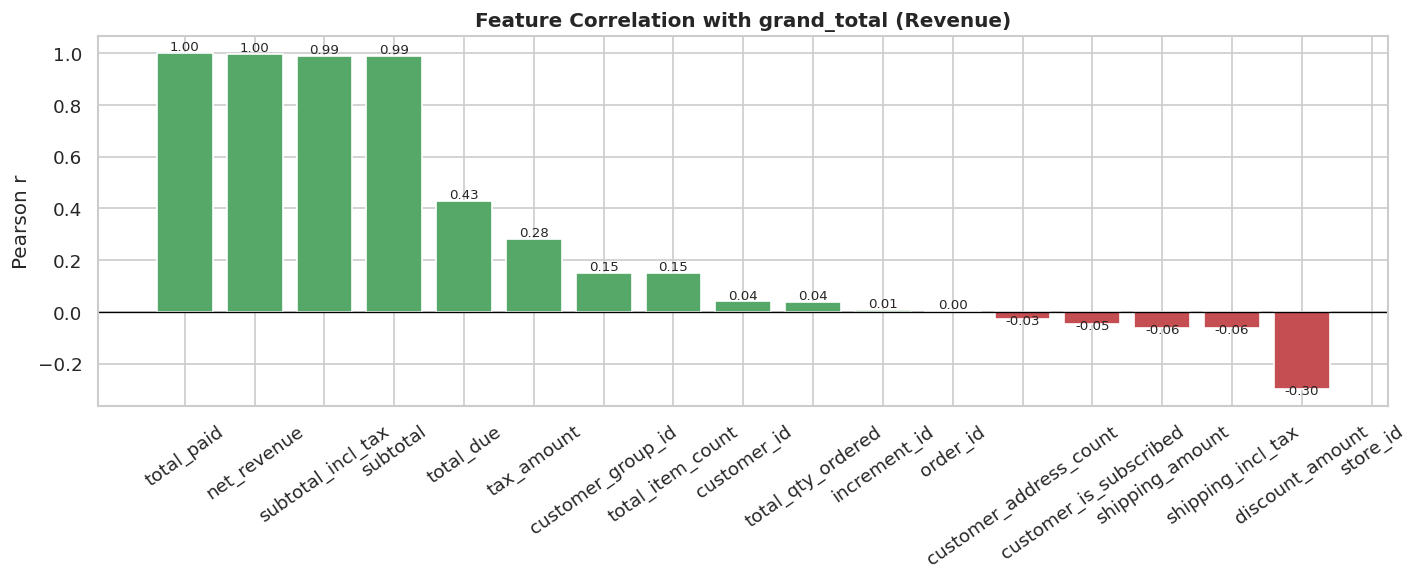

 Green = positive impact on revenue | Red = negative impact on revenue

6. TIME SERIES ANALYSIS

Monthly Trend (with growth %):
      ym  orders  revenue  revenue_growth_%
2023-04     120 15337.89               NaN
2023-05     388 46827.39            205.31
2023-06     421 49685.19              6.10
2023-07     538 59471.93             19.70
2023-08     593 57275.83             -3.69
2023-09     534 58805.69              2.67
2023-10     421 52201.68            -11.23
2023-11     403 45334.14            -13.16
2023-12     695 76544.90             68.85
2024-01     676 78766.60              2.90
2024-02     600 63482.91            -19.40
2024-03     480 56059.68            -11.69
2024-04     403 48129.74            -14.15
2024-05     477 56336.17             17.05
2024-06     540 58023.55              3.00
2024-07     661 74105.09             27.72
2024-08     682 67629.82             -8.74
2024-09     539 62296.44             -7.89
2024-10     432 60970.37             -2.13
2024-11    

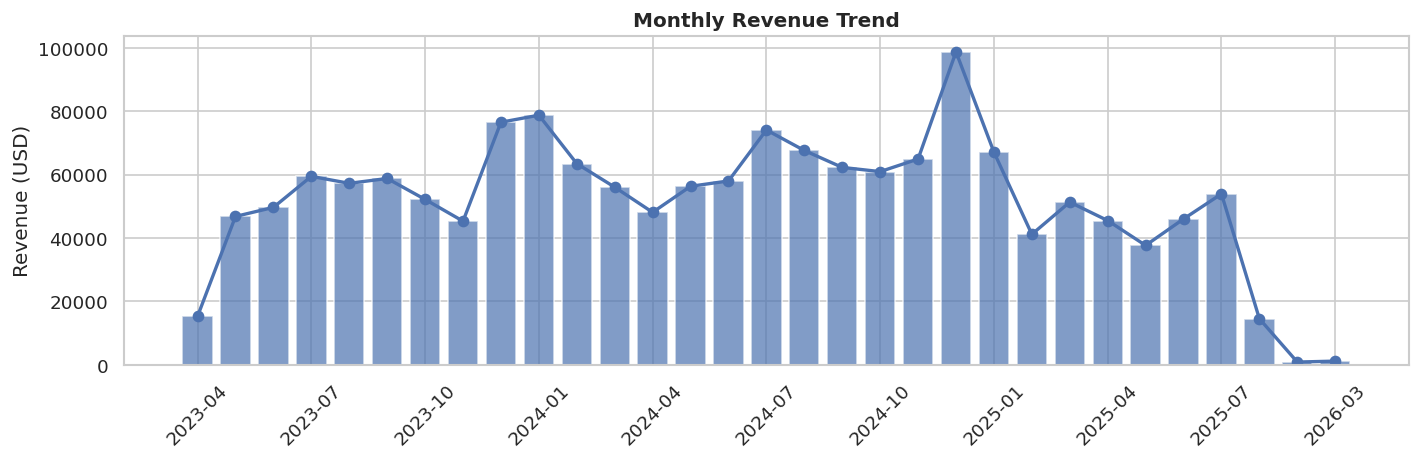

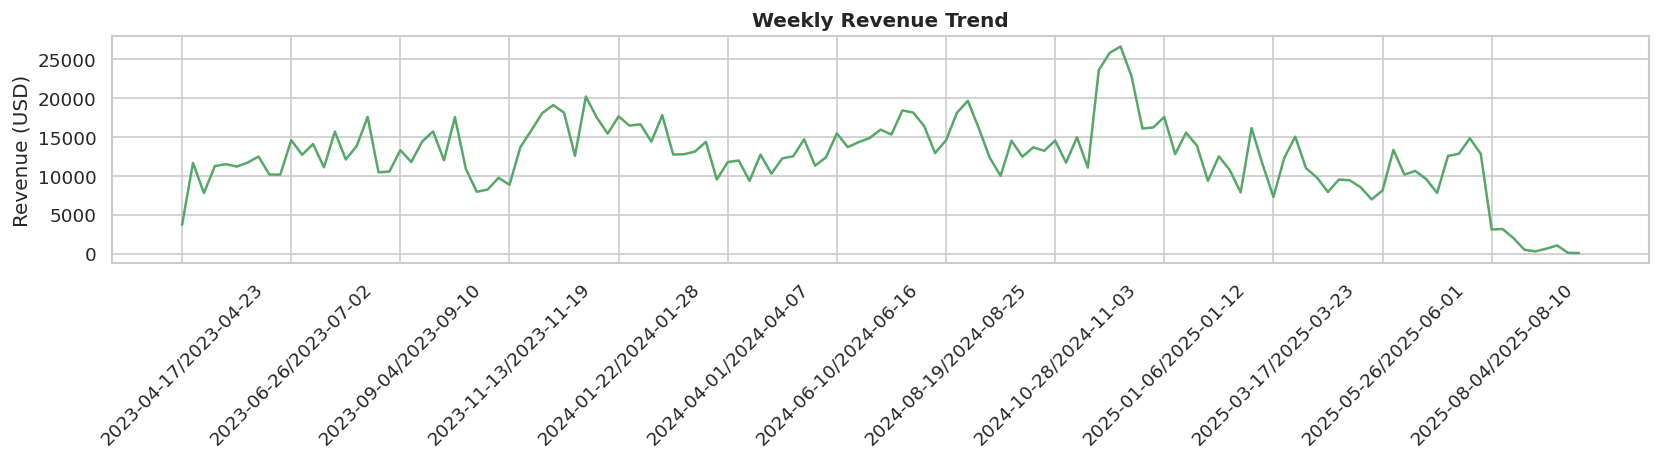

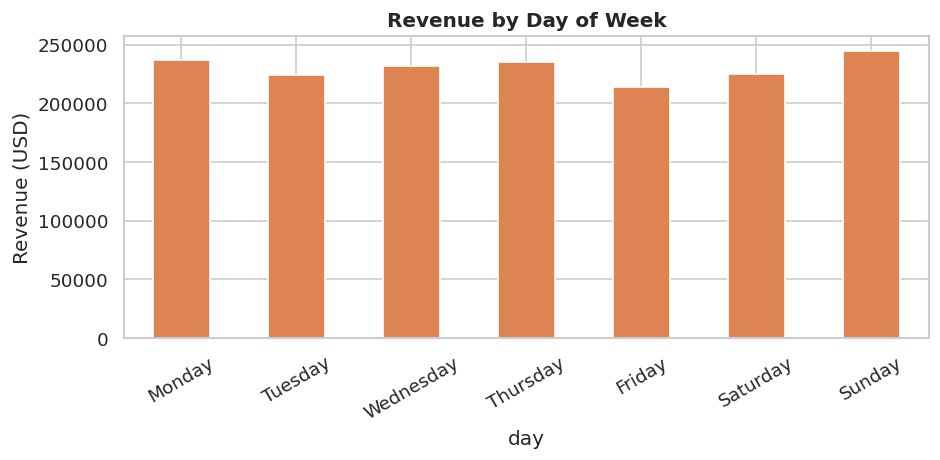


7. BUSINESS METRICS
  Total Revenue (GMV)  : $1,610,461.08
  Average Order Value  : $      113.60
  Median Order Value   : $       80.00
  AOV vs Median Gap    : $       33.60  ← big gap = skewed by large orders

  Top 20% orders contribute: 47.15% of revenue
  Bottom 80% orders        : 52.85% of revenue

  Order Value Brackets (what price range drives the business):
    $0–$50    : 2,973 orders (21.0%)  Revenue=$ 98,425.62 (6.1%)
    $50–$100   : 5,671 orders (40.0%)  Revenue=$398,184.13 (24.7%)
    $100–$200   : 3,522 orders (24.8%)  Revenue=$509,248.03 (31.6%)
    $200–$500   : 1,884 orders (13.3%)  Revenue=$512,169.85 (31.8%)
    $500–$1000  :   111 orders (0.8%)  Revenue=$ 68,661.01 (4.3%)
    $1000–$99999 :    15 orders (0.1%)  Revenue=$ 23,772.44 (1.5%)

 INTERPRETATION:

- Pareto rule → small % of orders generate majority revenue
- Focus retention on high AOV customers
- If most revenue comes from $50-200 bracket → that is your core segment


8. DISCOUNT ANALYSIS
  Orders wit

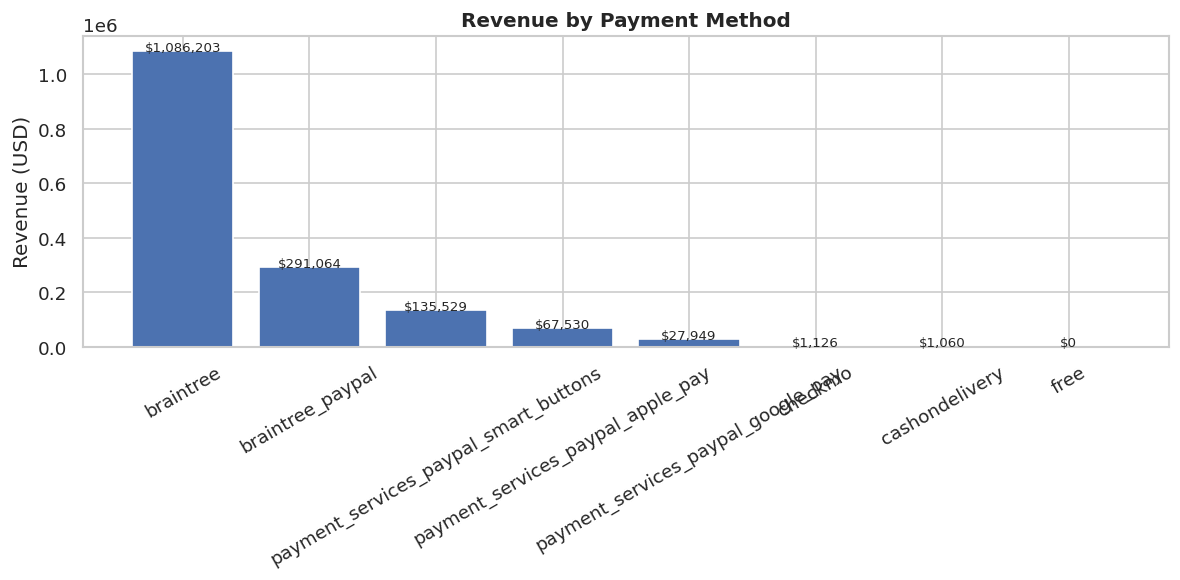


 INTERPRETATION:

- Dominant payment method → optimize checkout for that method first
- High cancel rate on a method → possible fraud or UX failure
- AOV by payment → premium customers may prefer certain methods (credit > COD)
- Low-used methods with high AOV → underserved segment worth promoting


12. ADVANCED BUSINESS INSIGHTS
  High-Value Orders (top 5%)  : 702
  Their revenue contribution  : $296,613.29 (18.4% of GMV)
  Avg high-value order        : $422.53

  Weekend Revenue : $469,832.57 (29.2%)
  Weekday Revenue : $1,140,628.51 (70.8%)
  → Weekdays drive more business

  Order Value Segments:
value_bucket  count    revenue  cancel_rate  %_rev
         Low   4792  196942.12         5.05   12.2
      Medium   4658  385949.34         4.49   24.0
        High   4726 1027569.62         6.58   63.8

  Free shipping orders : 10,143 (71.6%)
  Paid shipping orders : 4,033 (28.4%)
  AOV — Free shipping  : $129.01
  AOV — Paid shipping  : $74.87
  Total shipping revenue collected: $44,445

In [ ]:
# ============================================================
# ORDERS TABLE — COMPLETE EDA (ENHANCED WITH EXPLANATION)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

FILE = "AWS Gold Tables (1).xlsx"
orders = pd.read_excel(FILE, sheet_name="orders")

# ============================================================
# 1. BASIC STRUCTURE
# ============================================================
# Shows total number of records (rows) and features (columns)
# Helps you understand the scale of data you are working with
print("="*70)
print("1. BASIC INFO")
print("="*70)
print("Shape:", orders.shape)
print(" Total records = orders, columns = features")
print("\nColumns:\n", orders.columns.tolist())
print("\nData Types:\n")
print(orders.dtypes)
num_cols = orders.select_dtypes(include=np.number).columns.tolist()
cat_cols = orders.select_dtypes(include="object").columns.tolist()
print("\nNumerical Columns:", len(num_cols))
print(num_cols)
print(" These drive revenue, quantity, pricing, etc.")
print("\nCategorical Columns:", len(cat_cols))
print(cat_cols)
print(" These represent business segments like payment, state, etc.")

# ============================================================
# 2. NULL VALUE ANALYSIS
# ============================================================
# Finds which columns have missing data and how much
# Critical before any analysis — missing data can mislead results
print("\n" + "="*70)
print("2. NULL VALUE ANALYSIS")
print("="*70)
nulls = orders.isnull().sum()
null_pct = (nulls / len(orders)) * 100
null_df = pd.DataFrame({
    "Null_Count": nulls,
    "Null_%": null_pct.round(2)
}).sort_values(by="Null_%", ascending=False)
null_df = null_df[null_df["Null_Count"] > 0]
print(null_df)
print("\n INTERPRETATION:")
print("""
- discount_amount NULL/0 → means NO discount (business logic, not missing)
- customer_id / customer_group_id null → Guest orders (no account registered)
- customer_gender null → Not collected at checkout — major CRM data gap
- payment/shipping NULL → may depend on order state → MNAR
- total_paid null → Order not yet paid (pending state)
- Always check relation with 'state' before handling nulls
""")

# Business insight: what % of nulls are guest-driven vs data quality issues
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
guest_null_contrib = orders[orders["customer_is_guest"] == True]["customer_id"].isnull().sum()
print(f"  Guest-driven customer_id nulls : {guest_null_contrib:,}")
print(f"  → Most customer nulls are EXPECTED (guest checkouts, not a data quality issue)")

# ============================================================
# 3. CATEGORICAL ANALYSIS
# ============================================================
# Shows distribution of each text/label column
# Reveals dominant business segments, data imbalances, and quality issues
print("\n" + "="*70)
print("3. CATEGORICAL ANALYSIS")
print("="*70)
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(orders[col].value_counts(dropna=False).head(10))
print("\n INTERPRETATION:")
print("""
- Helps identify dominant business segments
- Example:
   state         → order lifecycle health (complete vs canceled)
   payment_method → user preference and checkout optimization
   country       → market distribution and geo expansion signals
   status        → operational pipeline health
""")

# ============================================================
# 4. NUMERICAL ANALYSIS
# ============================================================
# Generates count, mean, std, min/max and distribution shape for all numeric fields
# Skewness > 1 means data is heavily right-skewed (few large orders dominating)
print("\n" + "="*70)
print("4. NUMERICAL SUMMARY")
print("="*70)
summary = orders[num_cols].describe().T
summary["skewness"] = orders[num_cols].skew()
summary["variance"] = orders[num_cols].var()
print(summary.round(3))
print("\n INTERPRETATION:")
print("""
- High skewness on grand_total → few high-value orders dominate revenue
- High variance → inconsistent order values across customers
- Compare mean vs median: if mean >> median, outliers are pulling average up
- Focus: grand_total → core revenue metric for all business decisions
""")

# ============================================================
# 5. CORRELATION WITH REVENUE (no heatmap — feature-wise values)
# ============================================================
# Shows how strongly each numeric feature relates to grand_total (revenue)
# Positive = helps revenue, Negative = reduces revenue
print("\n" + "="*70)
print("5. CORRELATION WITH REVENUE")
print("="*70)
corr = orders[num_cols].corr()["grand_total"].drop("grand_total").sort_values(ascending=False)
print(corr.round(4))
print("\n INTERPRETATION:")
print("""
- subtotal / net_revenue → near +1.0 → same concept as grand_total (expected)
- shipping_amount → moderate positive → higher orders more likely to qualify free ship
- tax_amount → positive → larger orders pay more tax
- discount_amount → negative → discounts reduce final order value
- qty_ordered → moderate → more items = higher basket, but not always
- Use this for feature selection in ML models (drop near-duplicate features)
""")

# Bar chart of correlations — much cleaner than heatmap
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#55A868" if v > 0 else "#C44E52" for v in corr.values]
ax.bar(corr.index, corr.values, color=colors, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with grand_total (Revenue)", fontweight="bold")
ax.set_ylabel("Pearson r")
ax.tick_params(axis="x", rotation=35)
for i, v in enumerate(corr.values):
    ax.text(i, v + (0.01 if v >= 0 else -0.02), f"{v:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()
print(" Green = positive impact on revenue | Red = negative impact on revenue")

# ============================================================
# 6. TIME SERIES ANALYSIS (MONTHLY + WEEKLY + DAY)
# ============================================================
# Breaks down orders and revenue by time period
# Reveals seasonality, growth trends, and peak business periods
print("\n" + "="*70)
print("6. TIME SERIES ANALYSIS")
print("="*70)
orders["month"] = orders["order_date"].dt.to_period("M")
orders["week"]  = orders["order_date"].dt.to_period("W")
orders["day"]   = orders["order_date"].dt.day_name()
orders["hour"]  = orders["order_date"].dt.hour

monthly = orders.groupby("month").agg(
    orders=("order_id", "count"),
    revenue=("grand_total", "sum")
).reset_index()
monthly["revenue_growth_%"] = monthly["revenue"].pct_change().mul(100).round(2)
monthly["ym"] = monthly["month"].astype(str)

weekly = orders.groupby("week").agg(
    orders=("order_id", "count"),
    revenue=("grand_total", "sum")
).reset_index()
weekly["yw"] = weekly["week"].astype(str)

dow = orders.groupby("day")["grand_total"].agg(["count", "sum"]).reindex([
    "Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"
])
dow.columns = ["order_count","revenue"]

hourly = orders.groupby("hour")["grand_total"].agg(["count","sum"])
hourly.columns = ["order_count","revenue"]

print("\nMonthly Trend (with growth %):\n", monthly[["ym","orders","revenue","revenue_growth_%"]].to_string(index=False))
print("\nDay of Week Trend:\n", dow.to_string())
print("\nHourly Trend:\n", hourly.to_string())
print("\n INTERPRETATION:")
print("""
- Monthly growth % → which months drove business acceleration
- Day of week → weekend vs weekday buyer behavior
- Hour → peak buying time (critical for ad campaigns and email scheduling)
- Flat weekly trend → no seasonality | Spikes → promotions or events
""")

step = max(1, len(monthly)//10)

# Monthly revenue
plt.figure(figsize=(12, 4))
plt.bar(monthly["ym"], monthly["revenue"], color="#4C72B0", alpha=0.7, label="Revenue")
plt.plot(monthly["ym"], monthly["revenue"], color="#4C72B0", marker="o", linewidth=2)
plt.xticks(range(0, len(monthly), step), monthly["ym"].iloc[::step], rotation=45)
plt.title("Monthly Revenue Trend", fontweight="bold")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()

# Weekly revenue
plt.figure(figsize=(14, 4))
plt.plot(weekly["yw"], weekly["revenue"], color="#55A868", linewidth=1.5)
plt.xticks(range(0, len(weekly), max(1, len(weekly)//12)),
           weekly["yw"].iloc[::max(1, len(weekly)//12)], rotation=45)
plt.title("Weekly Revenue Trend", fontweight="bold")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()

# Day of week
plt.figure(figsize=(8, 4))
dow["revenue"].plot(kind="bar", color="#DD8452", edgecolor="white")
plt.title("Revenue by Day of Week", fontweight="bold")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ============================================================
# 7. CORE BUSINESS METRICS
# ============================================================
# Key financial KPIs every business tracks
# These numbers tell you the health and scale of the business
print("\n" + "="*70)
print("7. BUSINESS METRICS")
print("="*70)
rev = orders["grand_total"]
total_rev = rev.sum()
aov = rev.mean()
median_ov = rev.median()

print(f"  Total Revenue (GMV)  : ${total_rev:>12,.2f}")
print(f"  Average Order Value  : ${aov:>12,.2f}")
print(f"  Median Order Value   : ${median_ov:>12,.2f}")
print(f"  AOV vs Median Gap    : ${aov - median_ov:>12,.2f}  ← big gap = skewed by large orders")

top_20 = orders.nlargest(int(0.2 * len(orders)), "grand_total")
print(f"\n  Top 20% orders contribute: {top_20['grand_total'].sum()/total_rev*100:.2f}% of revenue")
print(f"  Bottom 80% orders        : {100 - top_20['grand_total'].sum()/total_rev*100:.2f}% of revenue")

print("\n  Order Value Brackets (what price range drives the business):")
brackets = [(0,50),(50,100),(100,200),(200,500),(500,1000),(1000,99999)]
for lo, hi in brackets:
    seg = orders[(orders["grand_total"] >= lo) & (orders["grand_total"] < hi)]
    seg_rev = seg["grand_total"].sum()
    print(f"    ${lo}–${hi:<6}: {len(seg):>5,} orders ({len(seg)/len(orders)*100:.1f}%)  "
          f"Revenue=${seg_rev:>10,.2f} ({seg_rev/total_rev*100:.1f}%)")

print("\n INTERPRETATION:")
print("""
- Pareto rule → small % of orders generate majority revenue
- Focus retention on high AOV customers
- If most revenue comes from $50-200 bracket → that is your core segment
""")

# ============================================================
# 8. DISCOUNT ANALYSIS
# ============================================================
# Shows how discounts are being used and whether they help or hurt order value
# Key to understanding pricing strategy effectiveness
print("\n" + "="*70)
print("8. DISCOUNT ANALYSIS")
print("="*70)
orders["has_discount"] = orders["discount_amount"].abs() > 0
disc_orders = orders[orders["has_discount"]]
no_disc     = orders[~orders["has_discount"]]

disc_rate = orders["has_discount"].mean() * 100
total_disc_given = orders["discount_amount"].abs().sum()

print(f"  Orders with discount    : {len(disc_orders):,} ({disc_rate:.1f}%)")
print(f"  Orders without discount : {len(no_disc):,} ({100-disc_rate:.1f}%)")
print(f"  Total discount given    : ${total_disc_given:,.2f}")
print(f"  Avg discount per order  : ${disc_orders['discount_amount'].abs().mean():.2f}")
print(f"\n  AOV WITH discount       : ${disc_orders['grand_total'].mean():.2f}")
print(f"  AOV WITHOUT discount    : ${no_disc['grand_total'].mean():.2f}")
print(f"  AOV Lift (no discount)  : ${no_disc['grand_total'].mean() - disc_orders['grand_total'].mean():.2f}")

print("\n INTERPRETATION:")
print("""
- If AOV ↑ with discount → discount drives bigger basket (good strategy)
- If AOV ↓ with discount → customers buy cheap items only when discounted (margin risk)
- Discount lift shows opportunity cost of giving away discounts
- High discount usage % → business is discount-dependent (risky for profitability)
""")

# ============================================================
# 9. CANCELLATION ANALYSIS
# ============================================================
# Measures how often orders are abandoned after placement
# Directly shows revenue leakage from operations
print("\n" + "="*70)
print("9. CANCELLATION & REVENUE LOSS ANALYSIS")
print("="*70)
cancel = orders[orders["state"] == "canceled"]
cancel_rate = len(cancel) / len(orders) * 100
cancel_loss = cancel["grand_total"].sum()

print(f"  Total canceled orders  : {len(cancel):,}")
print(f"  Cancel rate            : {cancel_rate:.2f}%")
print(f"  Revenue lost           : ${cancel_loss:,.2f}")
print(f"  Avg canceled order val : ${cancel['grand_total'].mean():.2f}")
print(f"  % of GMV lost          : {cancel_loss/total_rev*100:.2f}%")

print(f"\n  Cancelation by Payment Method:")
print(cancel["payment_method"].value_counts().to_string())

pending = orders[orders["total_due"] > 0] if "total_due" in orders.columns else pd.DataFrame()
if len(pending):
    print(f"\n  Unpaid/Pending orders  : {len(pending):,}")
    print(f"  Amount still due       : ${pending['total_due'].sum():,.2f}")

print("\n INTERPRETATION:")
print("""
- High cancel rate → operational issues (stock, payment failure, delivery)
- Cancel by payment method → certain methods have higher failure/fraud risk
- Revenue lost from cancels → direct business impact worth fixing first
- If pending amount is high → collections / payment reminder issue
""")

# ============================================================
# 10. CUSTOMER ANALYSIS
# ============================================================
# Breaks down who is buying — guests vs registered, repeat vs one-time
# Foundation for loyalty and retention strategy
print("\n" + "="*70)
print("10. CUSTOMER INSIGHTS")
print("="*70)
guest_rate = orders["customer_is_guest"].mean() * 100
print(f"  Guest Orders    : {guest_rate:.1f}%")
print(f"  Registered      : {100-guest_rate:.1f}%")
print(f"\n  AOV — Guest     : ${orders[orders['customer_is_guest']==True]['grand_total'].mean():.2f}")
print(f"  AOV — Registered: ${orders[orders['customer_is_guest']==False]['grand_total'].mean():.2f}")

reg_orders = orders[orders["customer_is_guest"] == False].dropna(subset=["customer_id"])
repeat = reg_orders["customer_id"].value_counts()
print(f"\n  Registered customers      : {repeat.shape[0]:,}")
print(f"  One-time buyers           : {(repeat==1).sum():,} ({(repeat==1).sum()/len(repeat)*100:.1f}%)")
print(f"  Repeat buyers (2+ orders) : {(repeat>1).sum():,} ({(repeat>1).sum()/len(repeat)*100:.1f}%)")
print(f"  VIP buyers (10+ orders)   : {(repeat>=10).sum():,}")

rev_per_cust = reg_orders.groupby("customer_id")["grand_total"].sum()
print(f"\n  Avg Customer LTV    : ${rev_per_cust.mean():.2f}")
print(f"  Median Customer LTV : ${rev_per_cust.median():.2f}")
print(f"\n  Top 10 Customers by Revenue:")
print(rev_per_cust.nlargest(10).apply(lambda x: f"${x:,.2f}").to_string())

print("\n👉 INTERPRETATION:")
print("""
- High guest % → low account creation → harder to retarget & retain
- High one-time buyer % → retention problem (no loyalty)
- VIP customers → focus retention campaigns here (highest ROI)
- LTV gap (mean vs median) → a few customers driving disproportionate revenue
""")

# ============================================================
# 11. PAYMENT ANALYSIS
# ============================================================
# Tells you which payment methods customers prefer and which generate more revenue
# Helps optimize checkout flow and reduce payment failure rates
print("\n" + "="*70)
print("11. PAYMENT INSIGHTS")
print("="*70)
pm_analysis = orders.groupby("payment_method").agg(
    order_count=("order_id","count"),
    total_rev=("grand_total","sum"),
    aov=("grand_total","mean"),
    cancel_rate=("state", lambda x: (x=="canceled").mean()*100),
    disc_rate=("has_discount","mean")
).reset_index()
pm_analysis["%_orders"] = (pm_analysis["order_count"]/len(orders)*100).round(1)
pm_analysis = pm_analysis.sort_values("total_rev", ascending=False)
print(pm_analysis.round(2).to_string(index=False))

plt.figure(figsize=(10, 5))
pm_top = pm_analysis.head(8)
bars = plt.bar(pm_top["payment_method"], pm_top["total_rev"], color="#4C72B0", edgecolor="white")
plt.title("Revenue by Payment Method", fontweight="bold")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=30)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'${bar.get_height():,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("\n INTERPRETATION:")
print("""
- Dominant payment method → optimize checkout for that method first
- High cancel rate on a method → possible fraud or UX failure
- AOV by payment → premium customers may prefer certain methods (credit > COD)
- Low-used methods with high AOV → underserved segment worth promoting
""")

# ============================================================
# 12. ADVANCED BUSINESS INSIGHTS (NEW)
# ============================================================
# Deeper segmentation to find hidden patterns in the data
# Used for targeted marketing, operations, and strategic decisions
print("\n" + "="*70)
print("12. ADVANCED BUSINESS INSIGHTS")
print("="*70)

# High value orders
hv_threshold = orders["grand_total"].quantile(0.95)
hv = orders[orders["grand_total"] > hv_threshold]
print(f"  High-Value Orders (top 5%)  : {len(hv):,}")
print(f"  Their revenue contribution  : ${hv['grand_total'].sum():,.2f} ({hv['grand_total'].sum()/total_rev*100:.1f}% of GMV)")
print(f"  Avg high-value order        : ${hv['grand_total'].mean():.2f}")

# Weekend vs weekday
orders["is_weekend"] = orders["day"].isin(["Saturday","Sunday"])
wknd_rev = orders[orders["is_weekend"]]["grand_total"].sum()
wkdy_rev = orders[~orders["is_weekend"]]["grand_total"].sum()
print(f"\n  Weekend Revenue : ${wknd_rev:,.2f} ({wknd_rev/total_rev*100:.1f}%)")
print(f"  Weekday Revenue : ${wkdy_rev:,.2f} ({wkdy_rev/total_rev*100:.1f}%)")
print(f"  → {'Weekdays drive more business' if wkdy_rev > wknd_rev else 'Weekends drive more business'}")

# Order value segments
orders["value_bucket"] = pd.qcut(orders["grand_total"], 3, labels=["Low","Medium","High"])
bucket_summary = orders.groupby("value_bucket").agg(
    count=("order_id","count"),
    revenue=("grand_total","sum"),
    cancel_rate=("state", lambda x: (x=="canceled").mean()*100)
).reset_index()
bucket_summary["%_rev"] = (bucket_summary["revenue"]/total_rev*100).round(1)
print(f"\n  Order Value Segments:")
print(bucket_summary.round(2).to_string(index=False))

# Shipping intelligence
if "shipping_amount" in orders.columns:
    free_ship = orders[orders["shipping_amount"] == 0]
    paid_ship  = orders[orders["shipping_amount"] > 0]
    print(f"\n  Free shipping orders : {len(free_ship):,} ({len(free_ship)/len(orders)*100:.1f}%)")
    print(f"  Paid shipping orders : {len(paid_ship):,} ({len(paid_ship)/len(orders)*100:.1f}%)")
    print(f"  AOV — Free shipping  : ${free_ship['grand_total'].mean():.2f}")
    print(f"  AOV — Paid shipping  : ${paid_ship['grand_total'].mean():.2f}")
    print(f"  Total shipping revenue collected: ${paid_ship['shipping_amount'].sum():,.2f}")

# Virtual vs physical
if "is_virtual" in orders.columns:
    virt = orders.groupby("is_virtual").agg(
        count=("order_id","count"), revenue=("grand_total","sum"), aov=("grand_total","mean")
    ).reset_index()
    virt["label"] = virt["is_virtual"].map({True:"Digital",False:"Physical"})
    print(f"\n  Digital vs Physical Orders:")
    print(virt[["label","count","revenue","aov"]].round(2).to_string(index=False))

print("\n INTERPRETATION:")
print("""
- High-value orders (top 5%) → protect these with priority support & fulfilment
- Weekend vs weekday → schedule campaigns for peak revenue days
- Low bucket high cancel rate → cheap orders get canceled more (buyer remorse?)
- Free ship AOV > Paid ship AOV → free shipping threshold is working (customers spend more)
- Digital vs physical split → tells you product mix and logistics cost structure
""")

# ============================================================
# 13. FEATURE ENGINEERING IDEAS
# ============================================================
# Features you should create before building ML models or dashboards
print("\n" + "="*70)
print("13. FEATURE ENGINEERING IDEAS")
print("="*70)
print("""
  Features to create:
  ─────────────────────────────────────────────────────────────
  Time Features:
    → hour, day_name, is_weekend, month, quarter, year

  Customer Features:
    → is_guest (bool)
    → repeat_customer_flag (orders > 1)
    → customer_lifetime_value (sum of grand_total by customer_id)
    → days_since_last_order

  Order Features:
    → has_discount (bool)
    → discount_pct (discount / grand_total)
    → value_bucket (Low / Medium / High by quantile)
    → high_value_flag (grand_total > 95th pct)
    → has_free_shipping (bool)
    → is_virtual (bool)

  Business Applications:
  ─────────────────────────────────────────────────────────────
  ✔ Demand Forecasting      → use time + product features
  ✔ Customer Segmentation   → use LTV + repeat + value_bucket
  ✔ Churn Prediction        → use days_since_last_order + frequency
  ✔ Discount Optimization   → use AOV impact of discount features
  ✔ Pricing Models          → use value_bucket + category + payment
  ✔ Recommendation Systems  → use repeat customers' product history
""")

# ============================================================
# END
# ============================================================
print("\n✅ FINAL ORDERS EDA COMPLETE")

1. BASIC INFO
Shape: (35701, 42)
👉 Each row = one product in an order (NOT one order)

Columns:
 ['item_id', 'order_id', 'order_date', 'product_id', 'sku', 'item_name', 'product_type', 'parent_item_id', 'order_increment_id', 'order_state', 'order_status', 'customer_id', 'customer_is_guest', 'payment_method', 'order_currency', 'catalog_product_name', 'catalog_product_type', 'product_main_category', 'product_category', 'product_sub_category', 'product_page_url', 'product_image_url', 'product_attributes_json', 'qty_ordered', 'qty_invoiced', 'qty_shipped', 'qty_canceled', 'qty_refunded', 'price', 'price_incl_tax', 'row_total', 'row_total_incl_tax', 'discount_amount', 'tax_amount', 'order_currency_code', 'base_currency_code', 'line_total_after_discount', 'created_at_ts', 'updated_at_ts', '_extract_date', '_run_id', '_gold_loaded_at']

Data Types:

item_id                               int64
order_id                              int64
order_date                   datetime64[ns]
product_id   

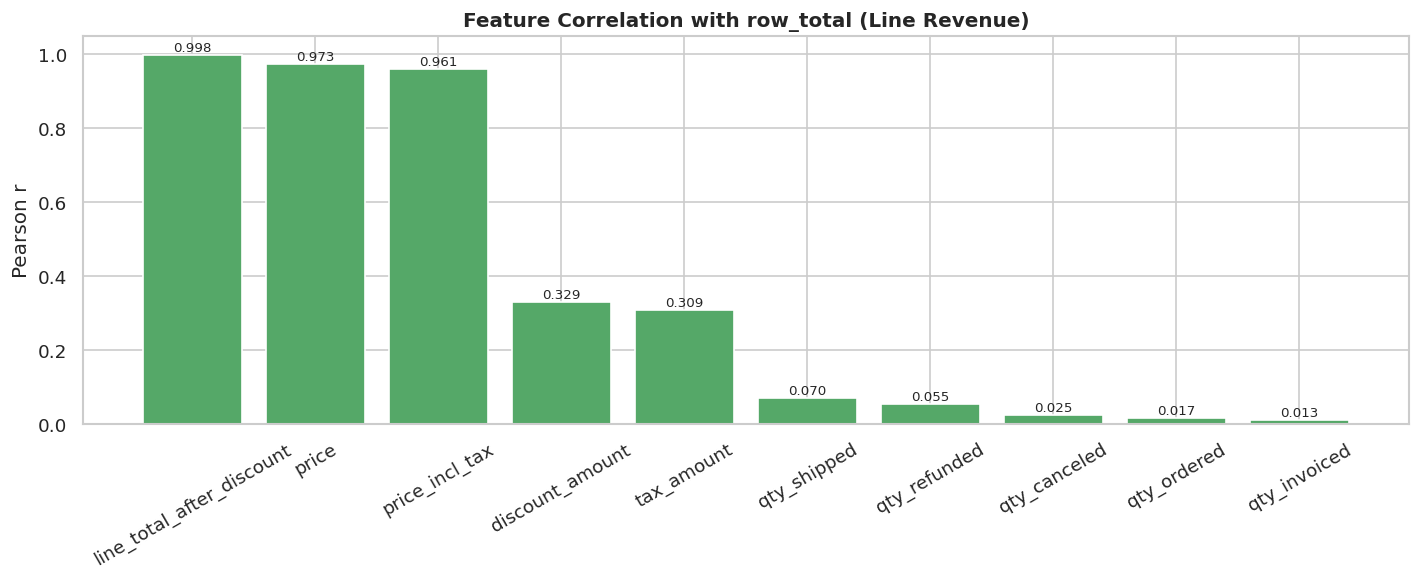


👉 INTERPRETATION:

- price → near +1 with row_total → price is the primary revenue driver
- qty_ordered → moderate positive → more units = more revenue (but not always)
- discount_amount → negative → higher discount = lower net line revenue
- qty_canceled → negative → cancelations directly reduce realized revenue
- qty_refunded → negative → refunds erode post-sale revenue
- Use these correlations to understand what levers to pull for revenue growth


6. PRODUCT PERFORMANCE

Top 15 Products by Revenue:
                                  item_name  total_rev  units  avg_price  cancel_%  refund_%  rev_%
                           Renegade GTX Mid  117593.74   1144 106.135964       4.5       8.1   7.57
                                e-Gift Card   42451.50    352 120.600852      14.5       1.7   2.73
        Banff Centre Mountain Film Festival   36977.84   2466  15.908586       2.4       1.7   2.38
                             Camino Evo GTX   22037.09    164 138.317901       0.0       8.6

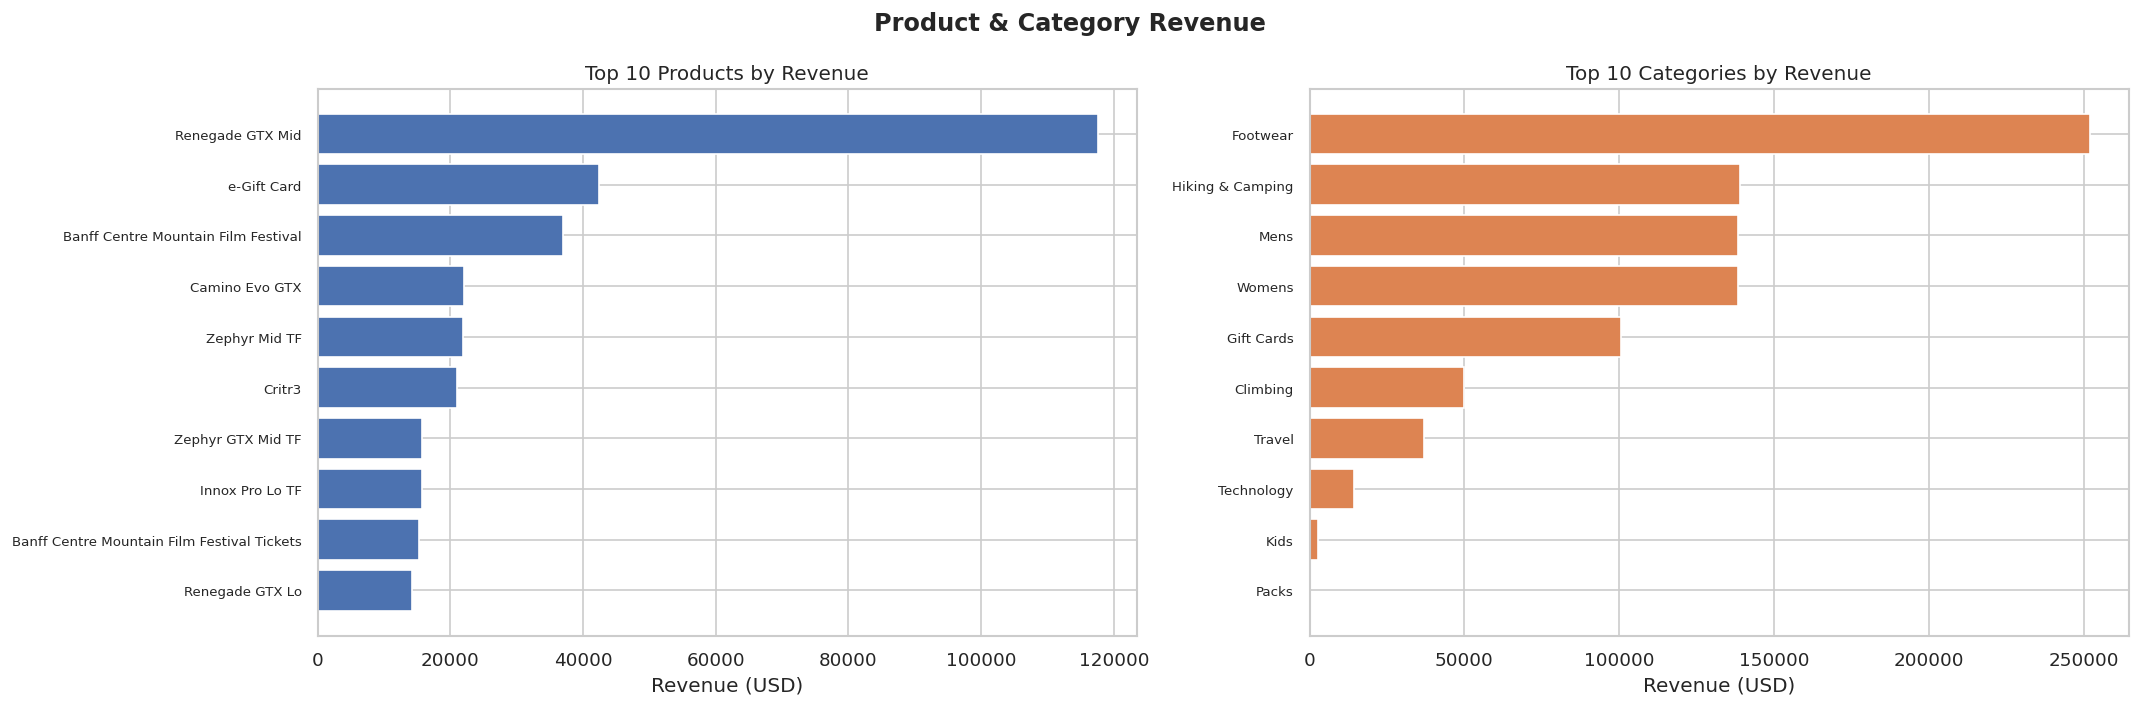


7. QUANTITY ANALYSIS
  Total units ordered  : 49,759
  Total units invoiced : 44,918
  Total units shipped  : 22,511
  Total units canceled : 2,674
  Total units refunded : 2,419

  Avg qty per line     : 1.39
  Median qty per line  : 1
  Max qty on one line  : 600

  Lines with qty > 1   : 3,089 (8.7%)
  High qty (top 5%)    : 791

  Fulfilment rate      : 45.2%
  Unit cancel rate     : 5.4%
  Unit refund rate     : 4.9%

👉 INTERPRETATION:

- Fulfilment rate < 100% → gap between orders placed and units actually shipped
- High qty lines → could be B2B bulk orders (segment separately)
- Low median qty but high avg qty → few bulk orders skewing the average
- High cancel/refund unit rates → supply chain or product quality alert


8. REFUND & CANCELLATION
  Cancel rate (lines)     : 5.43%
  Refund rate (lines)     : 6.58%
  Revenue in canceled     : $116,302.81 (7.5% of GMV)
  Revenue in refunded     : $136,326.96

  Cancel rate by category (top 10):
product_main_category  lines  canceled

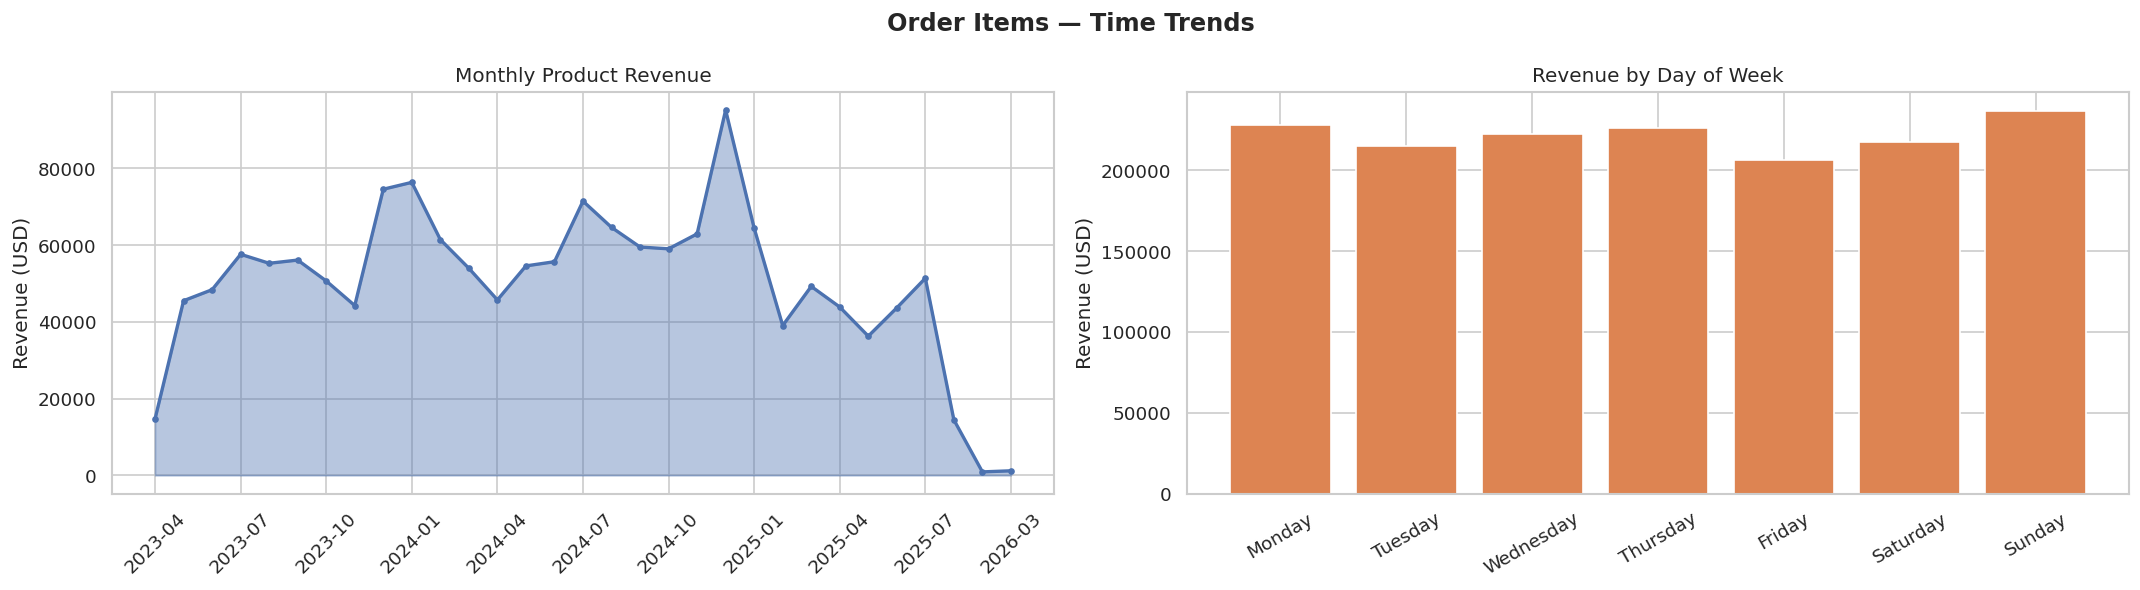


👉 INTERPRETATION:

- Monthly growth % → which months saw product demand accelerate
- Negative growth months → investigate (stock-out, seasonality, promo end)
- Day of week pattern → schedule restocks and campaigns for peak days


11. ADVANCED BUSINESS INSIGHTS
  PARETO — Top 20% lines contribute : 73.2% of revenue
  Bottom 80% lines                  : 26.8% of revenue

  Top 3 categories revenue share  : 34.1%
  → Business is diversified across categories

  High Value Lines (top 5%)       : 1,750
  Their revenue contribution      : $488,916.58 (31.5%)
  Avg high-value line revenue     : $279.38

  Category Revenue Share (%):
product_main_category  total_rev  rev_%
             Footwear  251862.33  16.22
     Hiking & Camping  138952.56   8.95
                 Mens  138455.78   8.92
               Womens  138156.17   8.90
           Gift Cards  100663.69   6.48
             Climbing   50000.83   3.22
               Travel   36823.80   2.37
           Technology   14452.12   0.93
     

In [ ]:
# ============================================================
# ORDER_ITEMS TABLE — COMPLETE EDA (BUSINESS + FEATURE READY)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

FILE = "AWS Gold Tables (1).xlsx"
items = pd.read_excel(FILE, sheet_name="order_items")

# ============================================================
# 1. BASIC STRUCTURE
# Shows total line items, columns, and data types
# Each row = ONE product in ONE order (not one order)
# ============================================================
print("="*70)
print("1. BASIC INFO")
print("="*70)
print("Shape:", items.shape)
print("👉 Each row = one product in an order (NOT one order)")
print("\nColumns:\n", items.columns.tolist())
print("\nData Types:\n")
print(items.dtypes)
num_cols = items.select_dtypes(include=np.number).columns.tolist()
cat_cols = items.select_dtypes(include="object").columns.tolist()
print("\nNumerical Columns:", num_cols)
print("\nCategorical Columns:", cat_cols)

# ============================================================
# 2. NULL ANALYSIS
# Identifies which fields are missing and business reason behind each
# Missing here often means "not applicable" not a data error
# ============================================================
print("\n" + "="*70)
print("2. NULL ANALYSIS")
print("="*70)
nulls = items.isnull().sum()
null_pct = (nulls / len(items)) * 100
null_df = pd.DataFrame({
    "Null_Count": nulls,
    "Null_%": null_pct.round(2)
}).sort_values(by="Null_%", ascending=False)
null_df = null_df[null_df["Null_Count"] > 0]
print(null_df)
print("\n👉 INTERPRETATION:")
print("""
- qty_refunded NULL → no refund happened (expected business logic, fill with 0)
- discount_amount NULL → no discount was applied on that line
- parent_item_id NULL → item IS a simple product (not a child of configurable)
- price = 0 lines → configurable parent rows — revenue is captured in child rows
- product_main_category NULL → product was deleted from catalogue after order
- Always check relation with order_status before handling nulls
""")

# Business impact: how many zero-price configurable parent rows exist
zero_price = (items["price"] == 0).sum()
print(f"  Zero-price lines (configurable parents): {zero_price:,} ({zero_price/len(items)*100:.1f}%)")
print(f"  → These rows have NO revenue — always filter price > 0 for revenue analysis")

# ============================================================
# 3. CATEGORICAL ANALYSIS
# Distribution of text/label columns — reveals order health & product mix
# ============================================================
print("\n" + "="*70)
print("3. CATEGORICAL ANALYSIS")
print("="*70)
important_cols = ["order_status", "product_type", "product_main_category",
                  "payment_method", "product_sub_category"]
for col in important_cols:
    if col in items.columns:
        print(f"\n--- {col} ---")
        vc = items[col].value_counts(dropna=False).head(10)
        pct = (vc / len(items) * 100).round(2)
        print(pd.DataFrame({"Count": vc, "%": pct}).to_string())

print("\n👉 INTERPRETATION:")
print("""
- order_status → shows fulfillment pipeline health (complete vs canceled)
- product_type → configurable lines inflate row count but carry $0 revenue
- product_main_category → which categories dominate order lines
- payment_method → most used checkout method at line level
- Always filter product_type = 'simple' for clean revenue numbers
""")

# ============================================================
# 4. NUMERICAL ANALYSIS
# Statistical summary of all numeric fields — reveals pricing & qty patterns
# Skewness tells if data is driven by a few extreme values
# ============================================================
print("\n" + "="*70)
print("4. NUMERICAL SUMMARY")
print("="*70)
summary = items[num_cols].describe().T
summary["skewness"] = items[num_cols].skew()
summary["variance"] = items[num_cols].var()
print(summary.round(3))
print("\n👉 INTERPRETATION:")
print("""
- qty_ordered mean vs max → check for bulk B2B orders vs retail
- price high skewness → few premium products pulling average up
- row_total variance → huge spread in order line values
- discount_amount mean → average discount depth per line
- qty_refunded mean → how often items are refunded on average
""")

# ============================================================
# 5. REVENUE COLUMN CREATION
# Creates a clean revenue field — uses discounted total where available
# This is the SINGLE most important column for all business analysis
# ============================================================
items["revenue"] = items["line_total_after_discount"].fillna(items["row_total"])
total_item_rev = items["revenue"].sum()
revenue_lines = items[items["price"] > 0]
print(f"\n👉 Revenue column created")
print(f"   Total revenue (all lines)   : ${total_item_rev:,.2f}")
print(f"   Revenue from non-zero lines : ${revenue_lines['revenue'].sum():,.2f}")
print(f"   Revenue lines count         : {len(revenue_lines):,} ({len(revenue_lines)/len(items)*100:.1f}% of all lines)")

# ============================================================
# 6. CORRELATION WITH REVENUE
# Shows which numeric features drive line-level revenue
# Helps prioritize what matters for pricing and ML models
# ============================================================
print("\n" + "="*70)
print("5. CORRELATION WITH REVENUE")
print("="*70)
corr_cols = [c for c in ["price","price_incl_tax","row_total","qty_ordered",
             "qty_invoiced","qty_shipped","qty_canceled","qty_refunded",
             "discount_amount","tax_amount","line_total_after_discount"] if c in items.columns]
corr = items[corr_cols].corr()["row_total"].drop("row_total").sort_values(ascending=False)
print(corr.round(4))

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#55A868" if v > 0 else "#C44E52" for v in corr.values]
ax.bar(corr.index, corr.values, color=colors, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with row_total (Line Revenue)", fontweight="bold")
ax.set_ylabel("Pearson r")
ax.tick_params(axis="x", rotation=30)
for i, v in enumerate(corr.values):
    ax.text(i, v + (0.01 if v >= 0 else -0.02), f"{v:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print("\n👉 INTERPRETATION:")
print("""
- price → near +1 with row_total → price is the primary revenue driver
- qty_ordered → moderate positive → more units = more revenue (but not always)
- discount_amount → negative → higher discount = lower net line revenue
- qty_canceled → negative → cancelations directly reduce realized revenue
- qty_refunded → negative → refunds erode post-sale revenue
- Use these correlations to understand what levers to pull for revenue growth
""")

# ============================================================
# 7. PRODUCT PERFORMANCE — CORE BUSINESS
# Identifies which products and categories actually drive the business
# ============================================================
print("\n" + "="*70)
print("6. PRODUCT PERFORMANCE")
print("="*70)

prod_summary = items.groupby("item_name").agg(
    total_rev=("revenue","sum"),
    lines=("item_id","count"),
    units=("qty_ordered","sum"),
    avg_price=("price","mean"),
    cancel_lines=("order_status", lambda x: (x=="canceled").sum()),
    refund_lines=("qty_refunded", lambda x: (x > 0).sum())
).reset_index()
prod_summary["cancel_%"] = (prod_summary["cancel_lines"]/prod_summary["lines"]*100).round(1)
prod_summary["refund_%"] = (prod_summary["refund_lines"]/prod_summary["lines"]*100).round(1)
prod_summary["rev_%"]    = (prod_summary["total_rev"]/total_item_rev*100).round(2)
prod_summary = prod_summary.sort_values("total_rev", ascending=False)

print("\nTop 15 Products by Revenue:")
print(prod_summary.head(15)[["item_name","total_rev","units","avg_price","cancel_%","refund_%","rev_%"]].to_string(index=False))

print("\nTop 15 Products by Units Sold:")
top_units = prod_summary.sort_values("units", ascending=False)
print(top_units.head(15)[["item_name","units","total_rev","avg_price"]].to_string(index=False))

print("\nTop 10 Most Canceled Products (min 10 lines):")
top_cancel = prod_summary[prod_summary["lines"] >= 10].sort_values("cancel_%", ascending=False)
print(top_cancel.head(10)[["item_name","lines","cancel_lines","cancel_%"]].to_string(index=False))

cat_rev = items.groupby("product_main_category").agg(
    total_rev=("revenue","sum"),
    lines=("item_id","count"),
    units=("qty_ordered","sum"),
    cancel_rate=("order_status", lambda x: (x=="canceled").mean()*100)
).reset_index()
cat_rev["rev_%"] = (cat_rev["total_rev"]/total_item_rev*100).round(2)
cat_rev = cat_rev.sort_values("total_rev", ascending=False)

print("\nTop 15 Categories by Revenue:")
print(cat_rev.head(15).to_string(index=False))

print("\n👉 INTERPRETATION:")
print("""
- Top 10 products by revenue → protect stock, prioritize fulfilment
- Top products by units ≠ top by revenue → high volume but low margin products
- High cancel % on a product → supply, pricing or quality issue
- Category revenue % → tells you which business vertical matters most
""")

# Product revenue chart
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Product & Category Revenue", fontweight="bold")

top10_prod = prod_summary.head(10)
axes[0].barh(top10_prod["item_name"][::-1], top10_prod["total_rev"][::-1], color="#4C72B0")
axes[0].set_title("Top 10 Products by Revenue")
axes[0].set_xlabel("Revenue (USD)")
axes[0].tick_params(axis="y", labelsize=8)

top10_cat = cat_rev.dropna(subset=["product_main_category"]).head(10)
axes[1].barh(top10_cat["product_main_category"][::-1], top10_cat["total_rev"][::-1], color="#DD8452")
axes[1].set_title("Top 10 Categories by Revenue")
axes[1].set_xlabel("Revenue (USD)")
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# 8. QUANTITY ANALYSIS
# Measures buying volume patterns — separates retail vs bulk buyers
# ============================================================
print("\n" + "="*70)
print("7. QUANTITY ANALYSIS")
print("="*70)
print(f"  Total units ordered  : {items['qty_ordered'].sum():,}")
print(f"  Total units invoiced : {items['qty_invoiced'].sum():,}")
print(f"  Total units shipped  : {items['qty_shipped'].sum():,}")
print(f"  Total units canceled : {items['qty_canceled'].sum():,}")
print(f"  Total units refunded : {items['qty_refunded'].fillna(0).sum():,}")
print(f"\n  Avg qty per line     : {items['qty_ordered'].mean():.2f}")
print(f"  Median qty per line  : {items['qty_ordered'].median():.0f}")
print(f"  Max qty on one line  : {items['qty_ordered'].max():,}")

multi_qty = items[items["qty_ordered"] > 1]
high_qty  = items[items["qty_ordered"] > items["qty_ordered"].quantile(0.95)]
print(f"\n  Lines with qty > 1   : {len(multi_qty):,} ({len(multi_qty)/len(items)*100:.1f}%)")
print(f"  High qty (top 5%)    : {len(high_qty):,}")

fulfil_rate = items["qty_shipped"].sum() / items["qty_ordered"].sum() * 100
cancel_unit = items["qty_canceled"].sum() / items["qty_ordered"].sum() * 100
refund_unit = items["qty_refunded"].fillna(0).sum() / items["qty_ordered"].sum() * 100
print(f"\n  Fulfilment rate      : {fulfil_rate:.1f}%")
print(f"  Unit cancel rate     : {cancel_unit:.1f}%")
print(f"  Unit refund rate     : {refund_unit:.1f}%")

print("\n👉 INTERPRETATION:")
print("""
- Fulfilment rate < 100% → gap between orders placed and units actually shipped
- High qty lines → could be B2B bulk orders (segment separately)
- Low median qty but high avg qty → few bulk orders skewing the average
- High cancel/refund unit rates → supply chain or product quality alert
""")

# ============================================================
# 9. REFUND & CANCELLATION ANALYSIS
# Measures post-order revenue loss — most critical ops metric
# ============================================================
print("\n" + "="*70)
print("8. REFUND & CANCELLATION")
print("="*70)
cancel_rate = (items["order_status"] == "canceled").mean() * 100
refund_rate = (items["qty_refunded"].fillna(0) > 0).mean() * 100
cancel_lines = items[items["order_status"] == "canceled"]
refund_lines = items[items["qty_refunded"].fillna(0) > 0]

cancel_rev_loss = cancel_lines["revenue"].sum()
refund_rev_loss = refund_lines["revenue"].sum()

print(f"  Cancel rate (lines)     : {cancel_rate:.2f}%")
print(f"  Refund rate (lines)     : {refund_rate:.2f}%")
print(f"  Revenue in canceled     : ${cancel_rev_loss:,.2f} ({cancel_rev_loss/total_item_rev*100:.1f}% of GMV)")
print(f"  Revenue in refunded     : ${refund_rev_loss:,.2f}")

print("\n  Cancel rate by category (top 10):")
cat_cancel = items.groupby("product_main_category").agg(
    lines=("item_id","count"),
    canceled=("order_status", lambda x: (x=="canceled").sum())
).reset_index()
cat_cancel["cancel_%"] = (cat_cancel["canceled"]/cat_cancel["lines"]*100).round(2)
cat_cancel = cat_cancel[cat_cancel["lines"] >= 30].sort_values("cancel_%", ascending=False)
print(cat_cancel.head(10).to_string(index=False))

print("\n  Cancel rate by payment method:")
pm_cancel = items.groupby("payment_method").agg(
    lines=("item_id","count"),
    canceled=("order_status", lambda x: (x=="canceled").sum())
).reset_index()
pm_cancel["cancel_%"] = (pm_cancel["canceled"]/pm_cancel["lines"]*100).round(2)
print(pm_cancel.sort_values("cancel_%", ascending=False).to_string(index=False))

print("\n👉 INTERPRETATION:")
print("""
- High cancel rate in a category → supply/stock issue or pricing mismatch
- High refund rate → product quality or expectation mismatch
- Cancel by payment method → some methods have higher fraud or failure rates
- Revenue in canceled lines = direct business opportunity if fixed
""")

# ============================================================
# 10. DISCOUNT IMPACT AT LINE LEVEL
# Measures how discounts affect individual product revenue
# ============================================================
print("\n" + "="*70)
print("9. DISCOUNT ANALYSIS")
print("="*70)
items["has_discount"] = items["discount_amount"].abs() > 0
disc_lines   = items[items["has_discount"]]
no_disc_lines = items[~items["has_discount"]]

print(f"  Lines with discount    : {len(disc_lines):,} ({items['has_discount'].mean()*100:.1f}%)")
print(f"  Lines without discount : {len(no_disc_lines):,}")
print(f"  Total discount given   : ${items['discount_amount'].abs().sum():,.2f}")
print(f"  Avg discount per line  : ${disc_lines['discount_amount'].abs().mean():.2f}")
print(f"\n  Avg revenue WITH discount    : ${disc_lines['revenue'].mean():.2f}")
print(f"  Avg revenue WITHOUT discount : ${no_disc_lines['revenue'].mean():.2f}")
print(f"  Revenue lift (no discount)   : ${no_disc_lines['revenue'].mean() - disc_lines['revenue'].mean():.2f}")

print("\n  Discount usage by category (top 10):")
cat_disc = items.groupby("product_main_category").agg(
    lines=("item_id","count"),
    disc_lines=("has_discount","sum"),
    total_disc=("discount_amount","sum")
).reset_index()
cat_disc["disc_%"] = (cat_disc["disc_lines"]/cat_disc["lines"]*100).round(1)
cat_disc = cat_disc[cat_disc["lines"] >= 30].sort_values("disc_%", ascending=False)
print(cat_disc.head(10).to_string(index=False))

print("\n👉 INTERPRETATION:")
print("""
- If avg revenue WITH discount > without → discount drives bigger basket (good)
- If revenue WITHOUT discount is higher → discounts are just eroding margin
- Categories with high discount% → are they discounting to clear slow stock?
- High discount + high cancel → discount attracting wrong buyers
""")

# ============================================================
# 11. TIME ANALYSIS
# Shows how product-level revenue trends over time
# ============================================================
print("\n" + "="*70)
print("10. TIME ANALYSIS")
print("="*70)
items["order_date"] = pd.to_datetime(items["order_date"], errors="coerce")
items["month"] = items["order_date"].dt.to_period("M")
items["week"]  = items["order_date"].dt.to_period("W")
items["day"]   = items["order_date"].dt.day_name()

monthly = items.groupby("month").agg(
    revenue=("revenue","sum"),
    lines=("item_id","count"),
    units=("qty_ordered","sum")
).reset_index()
monthly["revenue_growth_%"] = monthly["revenue"].pct_change().mul(100).round(2)
monthly["ym"] = monthly["month"].astype(str)

weekly = items.groupby("week")["revenue"].sum().reset_index()
weekly["yw"] = weekly["week"].astype(str)

dow = items.groupby("day")["revenue"].sum().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])

print(monthly[["ym","lines","units","revenue","revenue_growth_%"]].to_string(index=False))

step = max(1, len(monthly) // 10)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("Order Items — Time Trends", fontweight="bold")

axes[0].fill_between(monthly["ym"], monthly["revenue"], color="#4C72B0", alpha=0.4)
axes[0].plot(monthly["ym"], monthly["revenue"], color="#4C72B0", linewidth=2, marker="o", markersize=3)
axes[0].set_title("Monthly Product Revenue")
axes[0].set_ylabel("Revenue (USD)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_xticks(range(0, len(monthly), step))
axes[0].set_xticklabels(monthly["ym"].iloc[::step], rotation=45)

axes[1].bar(dow.index, dow.values, color="#DD8452", edgecolor="white")
axes[1].set_title("Revenue by Day of Week")
axes[1].set_ylabel("Revenue (USD)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("\n👉 INTERPRETATION:")
print("""
- Monthly growth % → which months saw product demand accelerate
- Negative growth months → investigate (stock-out, seasonality, promo end)
- Day of week pattern → schedule restocks and campaigns for peak days
""")

# ============================================================
# 12. ADVANCED BUSINESS INSIGHTS
# Deep cuts into product economics and concentration risk
# ============================================================
print("\n" + "="*70)
print("11. ADVANCED BUSINESS INSIGHTS")
print("="*70)

# Pareto analysis
top20_count = int(0.2 * len(items))
top20 = items.nlargest(top20_count, "revenue")
pareto_pct = top20["revenue"].sum() / total_item_rev * 100
print(f"  PARETO — Top 20% lines contribute : {pareto_pct:.1f}% of revenue")
print(f"  Bottom 80% lines                  : {100-pareto_pct:.1f}% of revenue")

# Category concentration risk
top3_cat_rev = cat_rev.head(3)["total_rev"].sum()
print(f"\n  Top 3 categories revenue share  : {top3_cat_rev/total_item_rev*100:.1f}%")
print(f"  → Business is {'concentrated' if top3_cat_rev/total_item_rev > 0.6 else 'diversified'} across categories")

# High value lines
hv_threshold = items["revenue"].quantile(0.95)
hv = items[items["revenue"] > hv_threshold]
print(f"\n  High Value Lines (top 5%)       : {len(hv):,}")
print(f"  Their revenue contribution      : ${hv['revenue'].sum():,.2f} ({hv['revenue'].sum()/total_item_rev*100:.1f}%)")
print(f"  Avg high-value line revenue     : ${hv['revenue'].mean():.2f}")

# Category share table
cat_share = cat_rev[["product_main_category","total_rev","rev_%"]].dropna()
print("\n  Category Revenue Share (%):")
print(cat_share.head(12).to_string(index=False))

# Simple vs Configurable revenue
print("\n  Revenue by product_type:")
type_rev = items.groupby("product_type")["revenue"].agg(["sum","count","mean"]).round(2)
print(type_rev.to_string())

print("\n👉 INTERPRETATION:")
print("""
- Strong Pareto (>80/20 rule) → dangerous SKU concentration, diversify
- Top 3 category concentration > 60% → revenue risk if one category fails
- High value lines (top 5%) → highest priority for stock and fulfilment SLA
- Configurable revenue = $0 → confirms revenue analysis must use simple lines only
""")

# ============================================================
# 13. FEATURE ENGINEERING IDEAS
# Features to create before ML modeling or BI dashboards
# ============================================================
print("\n" + "="*70)
print("12. FEATURE ENGINEERING IDEAS")
print("="*70)
print("""
  ITEM-LEVEL FEATURES TO CREATE:
  ─────────────────────────────────────────────────────────────
  Revenue Features:
    → revenue (already created = line_total_after_discount OR row_total)
    → discount_flag (bool: discount_amount > 0)
    → discount_pct (discount_amount / row_total)
    → high_value_item (revenue > 95th percentile)

  Quantity Features:
    → refund_flag (qty_refunded > 0)
    → cancel_flag (order_status == 'canceled')
    → bulk_order_flag (qty_ordered > 5)
    → fulfil_gap (qty_ordered - qty_shipped)

  Product Features:
    → product_popularity_score (rank by units sold)
    → product_revenue_rank (rank by revenue)
    → category_revenue_share (category rev / total rev)
    → is_simple_product (product_type == 'simple')

  Time Features:
    → order_month, order_week, order_day_of_week
    → is_weekend

  USE CASES:
  ─────────────────────────────────────────────────────────────
  ✔ Recommendation System  → use product popularity + category
  ✔ Demand Forecasting     → use time + qty + category features
  ✔ Inventory Optimization → use fulfil_gap + cancel/refund flags
  ✔ Pricing Optimization   → use discount_pct + revenue impact
  ✔ Churn / Return Model   → use refund_flag + cancel_flag
""")

print("\n✅ ORDER_ITEMS EDA COMPLETE")

1. BASIC INFO
Shape: (27721, 32)
👉 Each row = one unique customer

Columns:
 ['customer_id', 'customer_group_id', 'store_id', 'website_id', 'gender', 'email_domain', 'created_in', 'is_subscribed', 'disable_auto_group_change', 'email_token', 'firstname_token', 'lastname_token', 'default_billing_address_id', 'default_billing_country_id', 'default_billing_region', 'default_billing_city', 'default_billing_postcode_token', 'default_billing_telephone_token', 'default_shipping_address_id', 'default_shipping_country_id', 'default_shipping_region', 'default_shipping_city', 'default_shipping_postcode_token', 'default_shipping_telephone_token', 'addresses_masked_json', 'created_at_ts', 'updated_at_ts', 'customer_created_date', 'customer_updated_date', '_extract_date', '_run_id', '_gold_loaded_at']

Data Types:

customer_id                                  int64
customer_group_id                            int64
store_id                                     int64
website_id                         

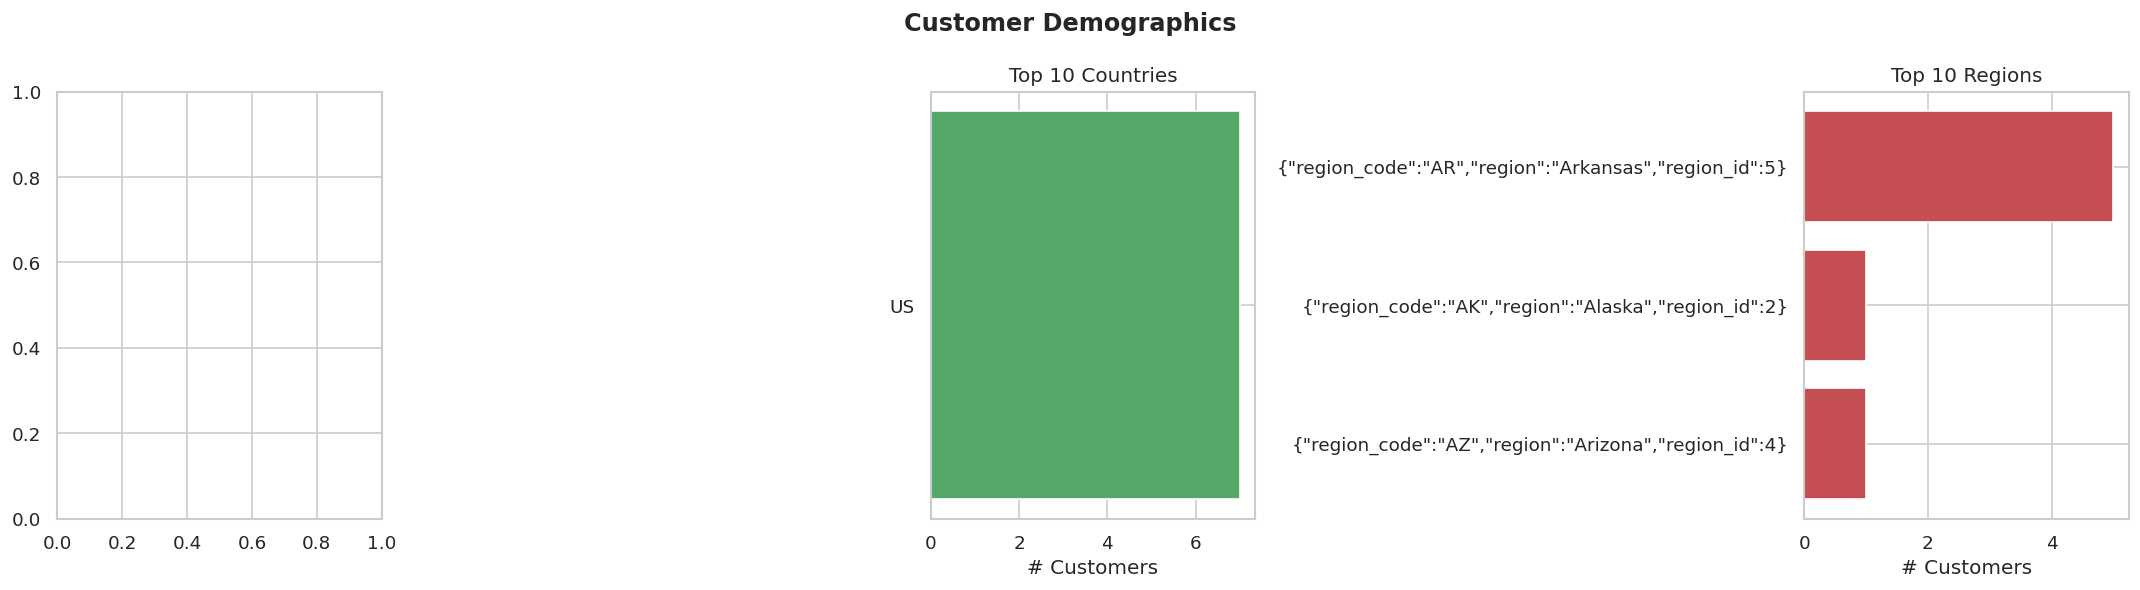


4. CUSTOMER ACQUISITION

Customers by Year:
year
2014     378
2015    2356
2016    2659
2017    9301
2018    1657
2019    1443
2020    2074
2021    1330
2022    1069
2023    2834
2024    1073
2025     530
2026    1017
Name: count, dtype: int64

  Best acquisition year    : 2017 (9,301 new customers)
  YoY growth (last 2 yrs)  :
    2025 → 2026: +91.9%
    2024 → 2025: -50.6%

👉 INTERPRETATION:

- Consistent year-over-year growth → healthy business scaling
- Spike in a year → successful campaign or market expansion
- Drop in acquisitions → ad spend reduced, competition, or market saturation
- Monthly trend helps identify which months acquire most customers (seasonality)



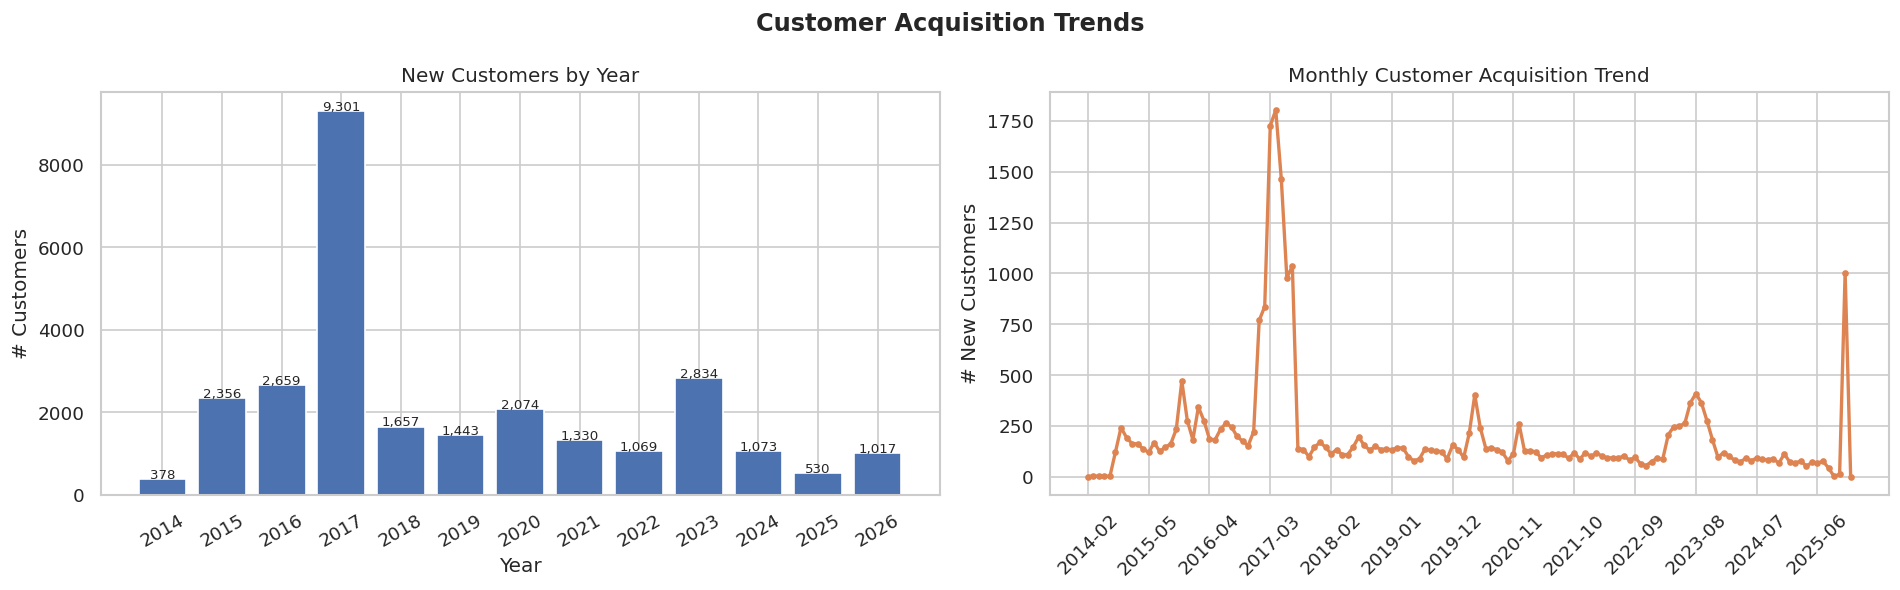


5. EMAIL SUBSCRIPTION
  Subscribed     : 5,120
  Not subscribed : 22,601
  Subscription rate : 18.5%
  Unsubscribed opportunity : 81.5% of customers not reachable via email

  Subscription rate by country (top 5):
default_billing_country_id
US    0.0

  Subscription rate by gender:
Series([], )

👉 INTERPRETATION:

- Low subscription rate → email campaigns reach only a fraction of customers
- High unsubscribed % → either opt-out issue or weak email value proposition
- Country/gender sub rate gap → tailor email acquisition strategy per segment
- Subscribed customers are your most valuable marketing asset — protect them


6. CUSTOMER SEGMENTATION BY GROUP
                   Count      %
customer_group_id              
1                  27721  100.0

👉 INTERPRETATION:

- Group 0 = Guest / Not logged in (no loyalty program)
- Group 1 = General registered customer
- Higher groups = VIP / Wholesale / Loyalty tiers (check your platform config)
- High group 0 % → most buyers are not in any lo

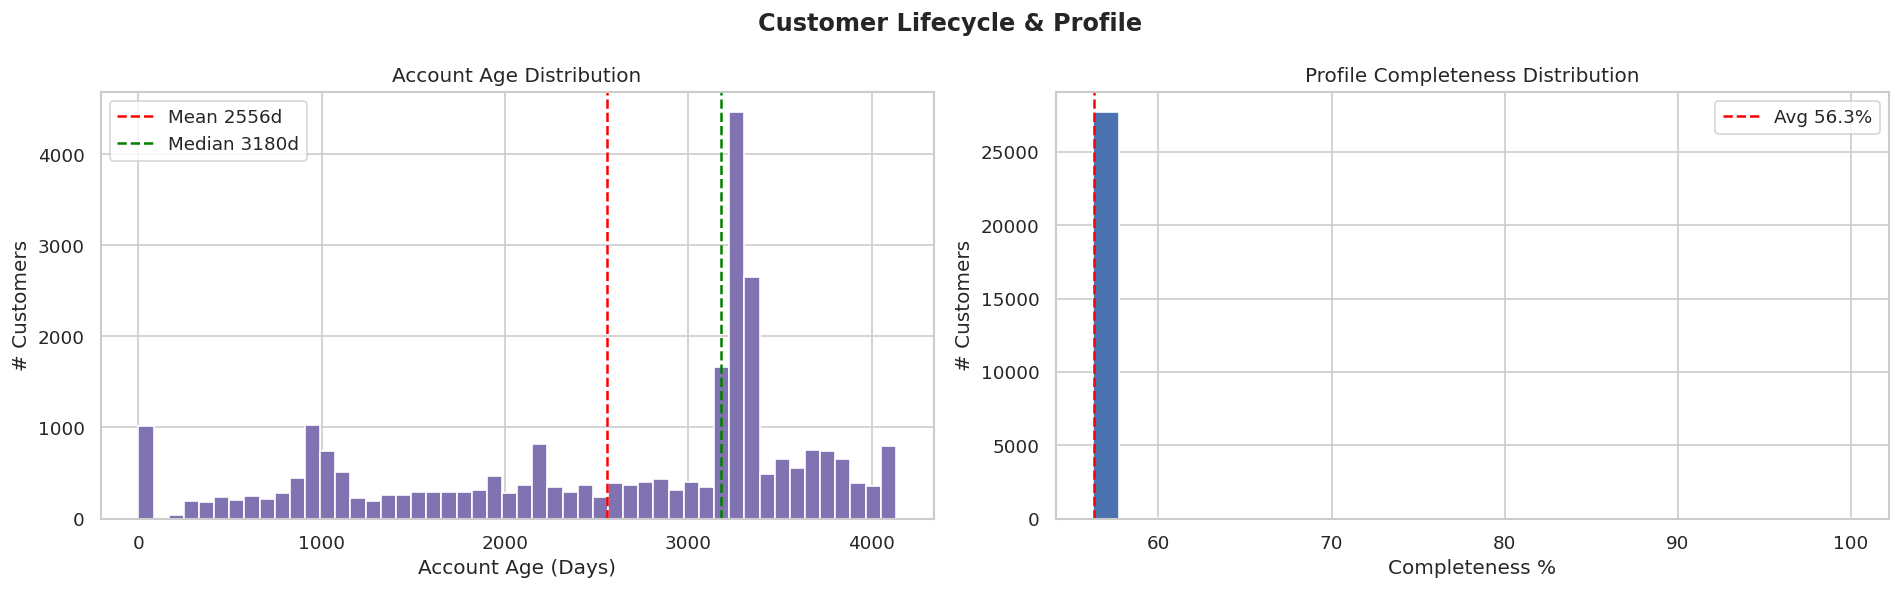


10. CORRELATION ANALYSIS
                   gender  customer_group_id  is_subscribed  account_age_days
gender                NaN                NaN            NaN               NaN
customer_group_id     NaN                NaN            NaN               NaN
is_subscribed         NaN                NaN         1.0000            0.2561
account_age_days      NaN                NaN         0.2561            1.0000

👉 INTERPRETATION:

  - account_age_days vs is_subscribed → do older customers subscribe more?
  - customer_group_id vs account_age → do older customers get upgraded to higher groups?
  - These weak correlations are EXPECTED in demographic data
    


In [ ]:
# ============================================================
# CUSTOMERS TABLE — ADVANCED EDA (BUSINESS + ML + STRATEGY)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

FILE = "AWS Gold Tables (1).xlsx"
customers = pd.read_excel(FILE, sheet_name="customers")

# ============================================================
# 1. BASIC STRUCTURE
# Shows how many customers are in the database and what fields exist
# Foundation for all segmentation, retention, and marketing analysis
# ============================================================
print("="*70)
print("1. BASIC INFO")
print("="*70)
print("Shape:", customers.shape)
print("👉 Each row = one unique customer")
print("\nColumns:\n", customers.columns.tolist())
print("\nData Types:\n")
print(customers.dtypes)
num_cols = customers.select_dtypes(include=np.number).columns.tolist()
cat_cols = customers.select_dtypes(include="object").columns.tolist()
print("\nNumerical Columns:", num_cols)
print("\nCategorical Columns:", cat_cols)
print("\n👉 INTERPRETATION:")
print("""
- Numerical → IDs, flags, group keys
- Categorical → geography, demographics
- customer_id is your unique key — check for duplicates before joining with orders
""")

dup_check = customers["customer_id"].duplicated().sum() if "customer_id" in customers.columns else 0
print(f"  Duplicate customer_ids : {dup_check} ({'PROBLEM — fix before joining' if dup_check > 0 else 'Clean — safe to join'})")

# ============================================================
# 2. NULL ANALYSIS
# Missing fields in customer table = gaps in CRM data
# Directly impacts ability to personalize and segment customers
# ============================================================
print("\n" + "="*70)
print("2. NULL ANALYSIS")
print("="*70)
nulls = customers.isnull().sum()
null_pct = (nulls / len(customers)) * 100
null_df = pd.DataFrame({
    "Null_Count": nulls,
    "Null_%": null_pct.round(2)
}).sort_values(by="Null_%", ascending=False)
null_df = null_df[null_df["Null_Count"] > 0]
print(null_df)

total_fields = customers.shape[0] * customers.shape[1]
total_nulls  = customers.isnull().sum().sum()
print(f"\n  Overall data completeness : {100 - total_nulls/total_fields*100:.1f}%")

print("\n👉 INTERPRETATION:")
print("""
- gender NULL → customer did not provide at signup → limits personalization
- default_billing_region NULL → incomplete address → impacts geo targeting
- customer_created_date NULL → data import issue (investigate source)
- High null % in any field → that field cannot be used for segmentation reliably
- Profile completeness is a KPI: low completeness = poor CRM health
""")

# Profile completeness per customer
profile_completeness = customers.notnull().mean(axis=1) * 100
print(f"\n  Avg profile completeness     : {profile_completeness.mean():.1f}%")
print(f"  Customers with >90% complete : {(profile_completeness >= 90).sum():,}")
print(f"  Customers with <50% complete : {(profile_completeness < 50).sum():,}")
print(f"  → Low completeness customers are hard to target or personalize for")

# ============================================================
# 3. DEMOGRAPHIC ANALYSIS
# Age, gender, and location of your customers
# Core input for marketing personalization and product strategy
# ============================================================
print("\n" + "="*70)
print("3. DEMOGRAPHIC INSIGHTS")
print("="*70)

gender_map = {1.0: "Male", 2.0: "Female"}
customers["gender_label"] = customers["gender"].map(gender_map)
gender_dist = customers["gender_label"].value_counts(dropna=False)
print("\nGender Distribution:")
print(gender_dist)
known_gender = customers["gender_label"].notna().sum()
print(f"\n  Known gender records      : {known_gender:,} ({known_gender/len(customers)*100:.1f}%)")
print(f"  Unknown / not provided    : {customers['gender_label'].isna().sum():,} ({customers['gender_label'].isna().sum()/len(customers)*100:.1f}%)")
if known_gender > 0:
    male_pct   = (gender_dist.get("Male",0) / known_gender * 100)
    female_pct = (gender_dist.get("Female",0) / known_gender * 100)
    print(f"  Male % (of known)         : {male_pct:.1f}%")
    print(f"  Female % (of known)       : {female_pct:.1f}%")

print("\nTop 10 Countries:")
country_dist = customers["default_billing_country_id"].value_counts().head(10)
country_pct  = (country_dist / len(customers) * 100).round(2)
print(pd.DataFrame({"Customers": country_dist, "%": country_pct}).to_string())

print("\nTop 10 Regions/States:")
region_dist = customers["default_billing_region"].value_counts().head(10)
region_pct  = (region_dist / len(customers) * 100).round(2)
print(pd.DataFrame({"Customers": region_dist, "%": region_pct}).to_string())

top1_country = country_dist.index[0] if len(country_dist) else "N/A"
top1_pct     = country_pct.iloc[0] if len(country_pct) else 0
print(f"\n  Primary market : {top1_country} ({top1_pct:.1f}% of customer base)")

print("\n👉 INTERPRETATION:")
print("""
- High concentration in 1 country → single market risk, opportunity to expand
- Gender split tells you whether product is skewed toward one demographic
- Top regions → where to focus logistics, warehousing, and local campaigns
- Unknown gender (high %) → add gender collection at registration for better CRM
""")

# Demographic charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Customer Demographics", fontweight="bold")

gender_known = customers["gender_label"].dropna()
if len(gender_known):
    gc = gender_known.value_counts()
    axes[0].pie(gc.values, labels=gc.index, autopct="%1.1f%%",
                colors=["#4C72B0","#DD8452"], startangle=90)
    axes[0].set_title("Gender Split (known only)")

axes[1].barh(country_dist.index[::-1], country_dist.values[::-1], color="#55A868")
axes[1].set_title("Top 10 Countries")
axes[1].set_xlabel("# Customers")

axes[2].barh(region_dist.index[::-1], region_dist.values[::-1], color="#C44E52")
axes[2].set_title("Top 10 Regions")
axes[2].set_xlabel("# Customers")

plt.tight_layout()
plt.show()

# ============================================================
# 4. CUSTOMER ACQUISITION ANALYSIS
# Shows how many customers joined per year/month
# Reveals business growth rate and campaign effectiveness
# ============================================================
print("\n" + "="*70)
print("4. CUSTOMER ACQUISITION")
print("="*70)
customers["customer_created_date"] = pd.to_datetime(customers["customer_created_date"], errors="coerce")
customers["year"]  = customers["customer_created_date"].dt.year
customers["month"] = customers["customer_created_date"].dt.to_period("M")

acq_year = customers["year"].value_counts().sort_index().dropna()
acq_month = customers.groupby("month").size().reset_index(name="count")
acq_month["ym"] = acq_month["month"].astype(str)

print("\nCustomers by Year:")
print(acq_year)
best_year = acq_year.idxmax()
print(f"\n  Best acquisition year    : {best_year} ({acq_year.max():,} new customers)")
print(f"  YoY growth (last 2 yrs)  :")
years = sorted(acq_year.index)
for i in range(1, min(3, len(years))):
    prev, curr = years[-i-1], years[-i]
    if acq_year.get(prev, 0) > 0:
        growth = (acq_year.get(curr,0) - acq_year.get(prev,0)) / acq_year.get(prev,0) * 100
        print(f"    {prev} → {curr}: {growth:+.1f}%")

print("\n👉 INTERPRETATION:")
print("""
- Consistent year-over-year growth → healthy business scaling
- Spike in a year → successful campaign or market expansion
- Drop in acquisitions → ad spend reduced, competition, or market saturation
- Monthly trend helps identify which months acquire most customers (seasonality)
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Customer Acquisition Trends", fontweight="bold")

axes[0].bar(acq_year.index.astype(str), acq_year.values, color="#4C72B0", edgecolor="white")
axes[0].set_title("New Customers by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("# Customers")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(acq_year.values):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontsize=8)

step = max(1, len(acq_month) // 12)
axes[1].plot(acq_month["ym"], acq_month["count"], color="#DD8452", linewidth=2, marker="o", markersize=3)
axes[1].set_title("Monthly Customer Acquisition Trend")
axes[1].set_ylabel("# New Customers")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_xticks(range(0, len(acq_month), step))
axes[1].set_xticklabels(acq_month["ym"].iloc[::step], rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 5. EMAIL SUBSCRIPTION ANALYSIS
# Measures marketing reach — subscribed customers = direct marketing audience
# ============================================================
print("\n" + "="*70)
print("5. EMAIL SUBSCRIPTION")
print("="*70)
sub_rate = customers["is_subscribed"].mean() * 100
sub_counts = customers["is_subscribed"].value_counts()
print(f"  Subscribed     : {sub_counts.get(True, sub_counts.get(1, 0)):,}")
print(f"  Not subscribed : {sub_counts.get(False, sub_counts.get(0, 0)):,}")
print(f"  Subscription rate : {sub_rate:.1f}%")
print(f"  Unsubscribed opportunity : {100-sub_rate:.1f}% of customers not reachable via email")

print("\n  Subscription rate by country (top 5):")
if "default_billing_country_id" in customers.columns:
    sub_by_country = customers.groupby("default_billing_country_id")["is_subscribed"].mean().mul(100).round(1)
    print(sub_by_country.sort_values(ascending=False).head(5).to_string())

print("\n  Subscription rate by gender:")
sub_gender = customers.groupby("gender_label")["is_subscribed"].mean().mul(100).round(1)
print(sub_gender.to_string())

print("\n👉 INTERPRETATION:")
print("""
- Low subscription rate → email campaigns reach only a fraction of customers
- High unsubscribed % → either opt-out issue or weak email value proposition
- Country/gender sub rate gap → tailor email acquisition strategy per segment
- Subscribed customers are your most valuable marketing asset — protect them
""")

# ============================================================
# 6. CUSTOMER SEGMENTATION BY GROUP
# Customer groups often map to pricing tiers, loyalty levels, or B2B vs B2C
# ============================================================
print("\n" + "="*70)
print("6. CUSTOMER SEGMENTATION BY GROUP")
print("="*70)
group_dist = customers["customer_group_id"].value_counts()
group_pct  = (group_dist / len(customers) * 100).round(2)
print(pd.DataFrame({"Count": group_dist, "%": group_pct}).to_string())

print("\n👉 INTERPRETATION:")
print("""
- Group 0 = Guest / Not logged in (no loyalty program)
- Group 1 = General registered customer
- Higher groups = VIP / Wholesale / Loyalty tiers (check your platform config)
- High group 0 % → most buyers are not in any loyalty program → retention risk
- Use group to build tier-based pricing and offer strategies
""")

# ============================================================
# 7. GEO BUSINESS ANALYSIS
# Which markets drive your customer base
# ============================================================
print("\n" + "="*70)
print("7. GEO ANALYSIS")
print("="*70)
total_custs = len(customers)
top5_countries = country_dist.head(5)
top5_pct = top5_countries.sum() / total_custs * 100
print(f"  Top 5 countries hold : {top5_pct:.1f}% of all customers")
print(f"  Total unique countries: {customers['default_billing_country_id'].nunique()}")
print(f"  Total unique regions  : {customers['default_billing_region'].nunique()}")

if top5_pct > 80:
    print(f"\n  ⚠️  Business is highly concentrated in top 5 markets — geographic risk")
else:
    print(f"\n  ✅ Business has reasonable geographic spread")

print("\n👉 INTERPRETATION:")
print("""
- Geographic concentration → high dependency on one market (political/economic risk)
- Diverse markets → more stable revenue but harder logistics to manage
- Expanding to underserved regions → look at where you have LOW customers but HIGH orders
""")

# ============================================================
# 8. ADVANCED BUSINESS INSIGHTS
# Deeper cuts: new vs old, account age, profile completeness scoring
# ============================================================
print("\n" + "="*70)
print("8. ADVANCED INSIGHTS")
print("="*70)

# New vs returning by 180-day window
recent_cutoff = customers["customer_created_date"].max() - pd.Timedelta(days=180)
customers["is_new"] = customers["customer_created_date"] > recent_cutoff
new_count = customers["is_new"].sum()
old_count = (~customers["is_new"]).sum()
print(f"  New customers (last 6 months) : {new_count:,} ({new_count/total_custs*100:.1f}%)")
print(f"  Older customers               : {old_count:,} ({old_count/total_custs*100:.1f}%)")

# New sub rate vs old
new_sub_rate = customers[customers["is_new"]]["is_subscribed"].mean() * 100
old_sub_rate = customers[~customers["is_new"]]["is_subscribed"].mean() * 100
print(f"\n  Subscription rate — new customers : {new_sub_rate:.1f}%")
print(f"  Subscription rate — old customers : {old_sub_rate:.1f}%")
print(f"  → {'New customers subscribe more — onboarding working' if new_sub_rate > old_sub_rate else 'Old customers subscribe more — consider re-engagement for new ones'}")

# Acquisition pace
if len(acq_month) > 1:
    recent_3 = acq_month.tail(3)["count"].mean()
    prev_3   = acq_month.iloc[-6:-3]["count"].mean() if len(acq_month) >= 6 else None
    print(f"\n  Avg monthly acquisition (last 3m) : {recent_3:.0f} customers/month")
    if prev_3:
        pace_chg = (recent_3 - prev_3) / prev_3 * 100
        print(f"  Avg monthly acquisition (prev 3m) : {prev_3:.0f} customers/month")
        print(f"  Acquisition pace change           : {pace_chg:+.1f}%")
        print(f"  → {'Accelerating 📈' if pace_chg > 0 else 'Decelerating 📉'}")

print("\n👉 INTERPRETATION:")
print("""
- Growing new customer % → business is in acquisition/growth phase
- Shrinking new % → business shifting to retention phase (normal at maturity)
- New vs old subscription gap → shows if onboarding drives email capture
- Acquisition pace tells you if marketing spend is becoming more or less effective
""")

# ============================================================
# 9. CUSTOMER LIFECYCLE ANALYSIS
# How long customers have been with the business
# Older = more loyal, newer = onboarding risk
# ============================================================
print("\n" + "="*70)
print("9. CUSTOMER LIFECYCLE")
print("="*70)
max_date = customers["customer_created_date"].max()
customers["account_age_days"] = (max_date - customers["customer_created_date"]).dt.days
age = customers["account_age_days"].dropna()

print(f"  Min account age  : {age.min():.0f} days")
print(f"  Max account age  : {age.max():.0f} days  ({age.max()/365:.1f} years)")
print(f"  Avg account age  : {age.mean():.0f} days  ({age.mean()/365:.1f} years)")
print(f"  Median account age: {age.median():.0f} days ({age.median()/365:.1f} years)")

buckets = [(0,30,"0-30 days (brand new)"),
           (30,180,"1-6 months"),
           (180,365,"6-12 months"),
           (365,730,"1-2 years"),
           (730,9999,"2+ years (loyal)")]
print(f"\n  Account Age Buckets:")
for lo, hi, label in buckets:
    cnt = ((age >= lo) & (age < hi)).sum()
    print(f"    {label:30s}: {cnt:>6,} ({cnt/len(age)*100:.1f}%)")

print("\n👉 INTERPRETATION:")
print("""
- High % of 0-30 day accounts → business in growth mode, lots of new customers
- High % of 2+ year accounts → loyal base, focus on retention and upsell
- Avg account age dropping over time → faster growth (new customers joining rapidly)
- Avg account age rising → acquisitions slowing down, base aging
""")

# Account age histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Customer Lifecycle & Profile", fontweight="bold")

axes[0].hist(age.clip(upper=age.quantile(0.99)), bins=50, color="#8172B2", edgecolor="white")
axes[0].axvline(age.mean(), color="red", linestyle="--", label=f"Mean {age.mean():.0f}d")
axes[0].axvline(age.median(), color="green", linestyle="--", label=f"Median {age.median():.0f}d")
axes[0].set_title("Account Age Distribution")
axes[0].set_xlabel("Account Age (Days)")
axes[0].set_ylabel("# Customers")
axes[0].legend()

axes[1].hist(profile_completeness, bins=30, color="#4C72B0", edgecolor="white")
axes[1].set_title("Profile Completeness Distribution")
axes[1].set_xlabel("Completeness %")
axes[1].set_ylabel("# Customers")
axes[1].axvline(profile_completeness.mean(), color="red", linestyle="--",
                label=f"Avg {profile_completeness.mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# 10. CORRELATION ANALYSIS
# How numeric customer fields relate to each other
# ============================================================
print("\n" + "="*70)
print("10. CORRELATION ANALYSIS")
print("="*70)
num_cust_cols = [c for c in ["gender","customer_group_id","is_subscribed","account_age_days"] if c in customers.columns]
if len(num_cust_cols) > 1:
    corr = customers[num_cust_cols].corr()
    print(corr.round(4).to_string())
    print("\n👉 INTERPRETATION:")
    print("""
  - account_age_days vs is_subscribed → do older customers subscribe more?
  - customer_group_id vs account_age → do older customers get upgraded to higher groups?
  - These weak correlations are EXPECTED in demographic data
    """)


1. BASIC STRUCTURE
Shape: (5996, 47)
👉 Each row = one unique product/SKU in the catalogue

Columns:
 ['product_id', 'sku', 'product_name', 'type_id', 'product_type', 'attribute_set_id', 'parent_product_id', 'parent_id', 'parent_sku', 'status', 'visibility', 'price', 'special_price', 'weight', 'url_key', 'url_path', 'product_page_url', 'image_url', 'short_description', 'description', 'meta_title', 'meta_keywords', 'category_ids', 'categories', 'main_category', 'category', 'sub_category', 'category_path_names', 'main_category_name', 'main_category_is_active', 'main_category_url_key', 'main_category_url_path', 'main_category_parent_id', 'main_category_level', 'main_category_hierarchy_path', 'main_category_root_id', 'additional_attributes_json', 'configurable_options', 'default_super_attribute', 'variants', 'quantity', 'is_in_stock', 'updated_at_ts', 'updated_date', '_extract_date', '_run_id', '_gold_loaded_at']

Data Types:
 product_id                               int64
sku              

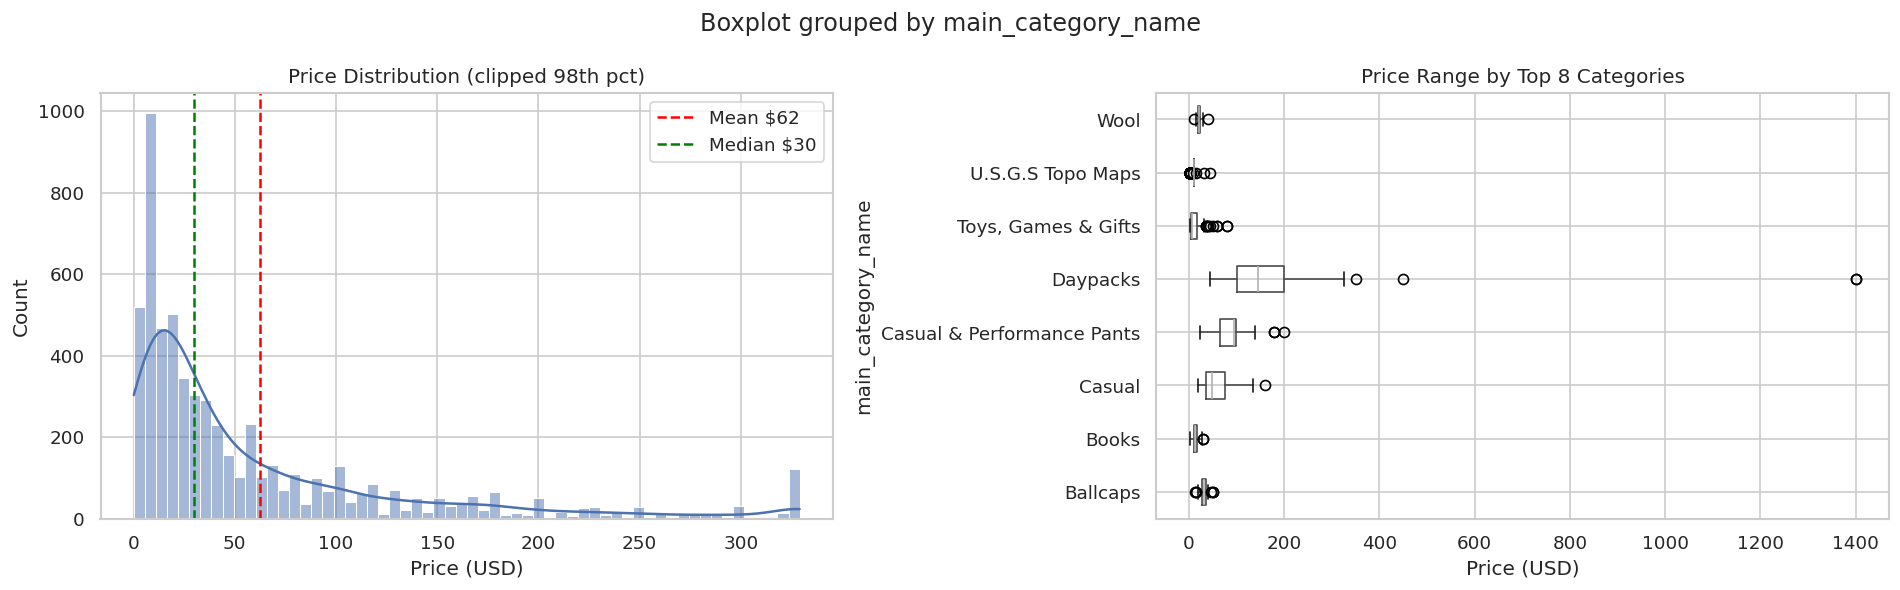


👉 INTERPRETATION:

- Mean >> Median → a few high-price SKUs are inflating the average
- Wide price range → multi-segment strategy (budget + premium)
- Price by category → identifies which categories are premium vs budget
- Narrow category price range → commoditized; wide → variety/tiered offering


6. PRICE BUCKET ANALYSIS
              Products      %
price_bucket                 
<$10              1466  24.45
$10-25            1278  21.31
$25-50            1120  18.68
$50-100           1020  17.01
$100-500          1040  17.34
>$500               17   0.28

  Dominant price bucket : <$10 (24.4% of catalogue)
  Premium (>$100) SKUs  : 1,057 (17.6%)
  Budget (<$25) SKUs    : 2,744 (45.8%)


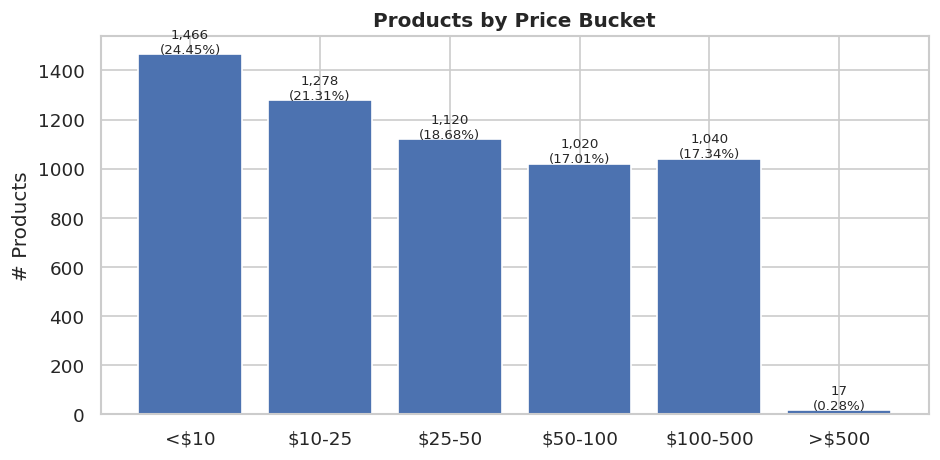


👉 INTERPRETATION:

- Heavy concentration in one bucket → your core price point (optimize here first)
- Few premium SKUs but high revenue → protect stock of these products
- Many budget SKUs → volume strategy; thin margins need high sell-through


7. DISCOUNT ANALYSIS
  Products on discount      : 387
  Discount penetration      : 42.1%
  Avg discount depth        : 35.5%
  Median discount depth     : 40.0%
  Max discount              : 88.2%
  Products with >50% off    : 10
  Products with >80% off    : 2

  Avg discount value per SKU: $29.40
  Max discount value on 1 SKU: $200.00

  Top 10 Categories by Avg Discount %:
                  category  avg_disc_%  discounted_skus
         U.S.G.S Topo Maps   56.372549                6
   Casual & Travel Jackets   41.429377                7
            Bras & Panties   40.319539               10
        Sweaters & Hoodies   39.803229               31
                 Warm Hats   39.123524               18
                  Swimwear   38.452

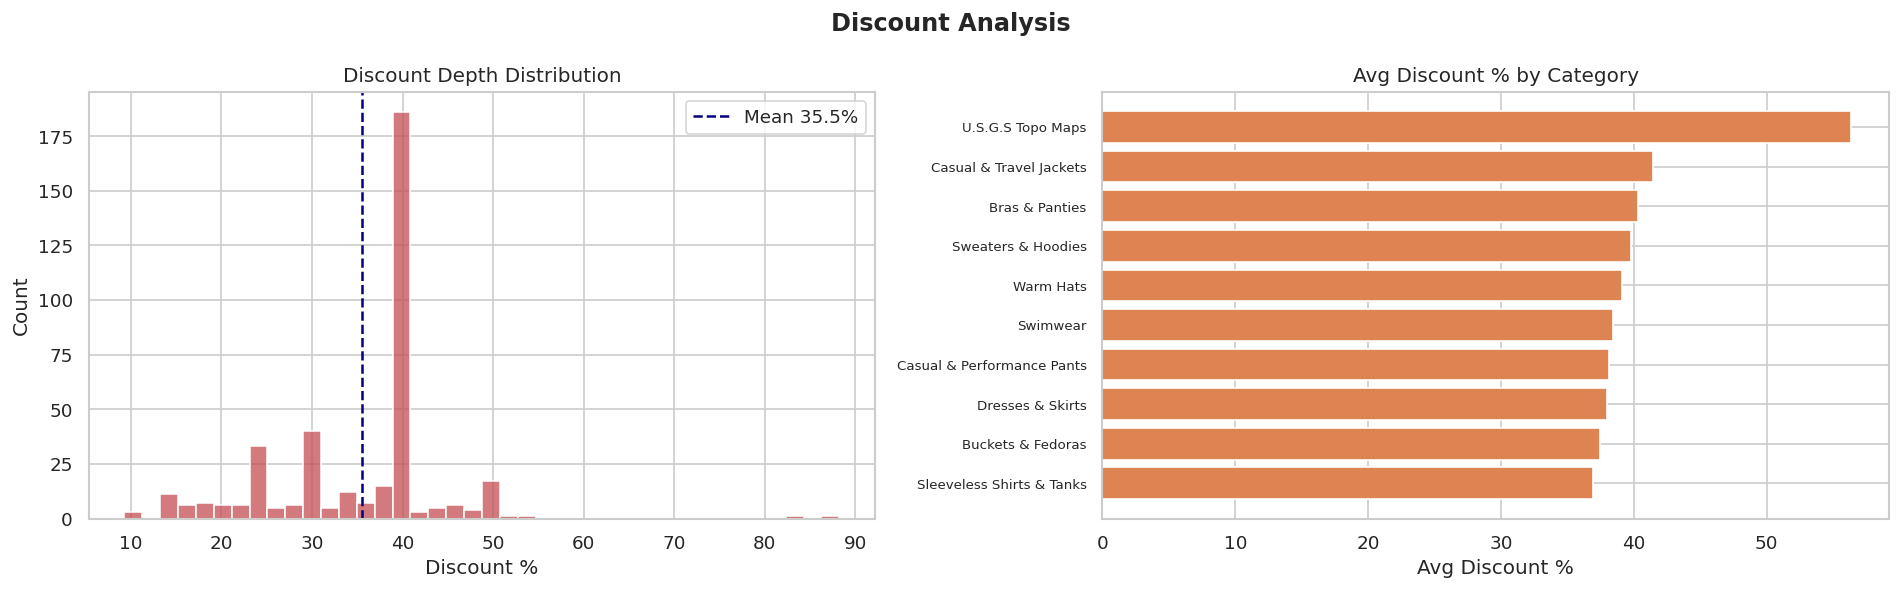


👉 INTERPRETATION:

- High discount penetration (>40%) → price credibility risk (customers wait for sale)
- Deep discounts (>50%) on many SKUs → margin erosion risk
- Category-wise discount → are low-performing categories being discounted to clear?
- Products with >80% discount → investigate if pricing was set correctly


8. STOCK ANALYSIS
is_in_stock
True     5914
False      82
Name: count, dtype: int64

  In-Stock rate  : 98.6%
  Out-of-Stock   : 1.4%  (82 SKUs)

  Quantity stats:
    Zero stock SKUs     : 82 (1.4%)
    Low stock (1-5 qty) : 0 (0.0%) ← reorder risk
    High stock (>100)   : 208 (3.5%)
    Avg qty             : 21.1
    Median qty          : 10

  Categories with worst in-stock rate (bottom 10):
main_category_name
Gift Cards                           0.0
Adapters & Converters                0.0
Vehicle Racks & Accessories          8.3
Cases and Sunglasses Accessories    12.5
Work Shoes                          60.0
Travel Comfort                      66.7
Mountaineeri

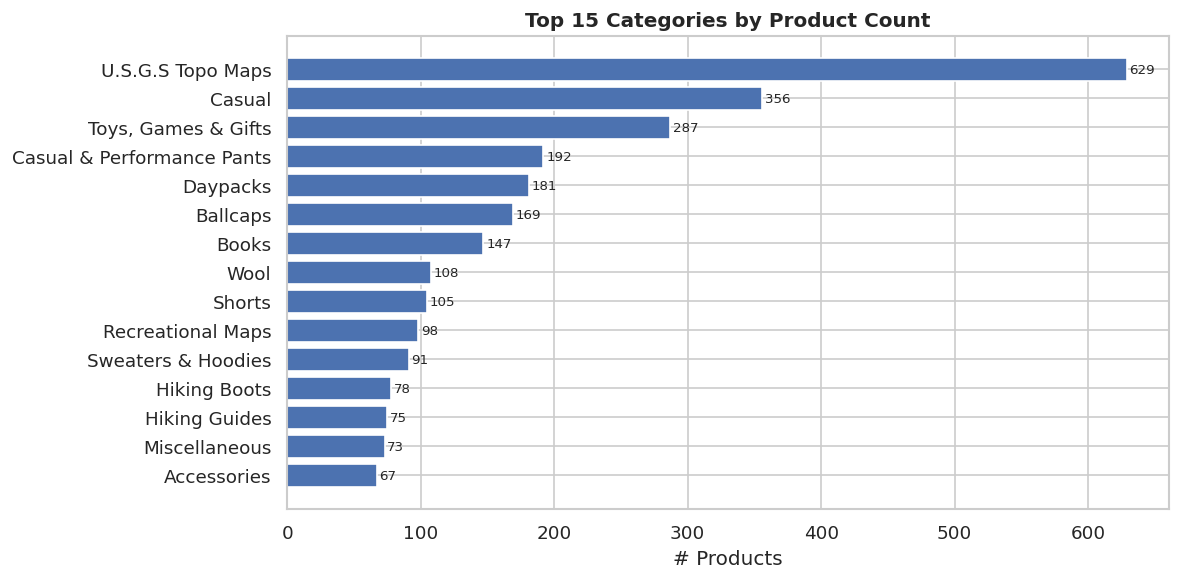


10. VISIBILITY ANALYSIS
                 Count      %
visibility                   
Catalog, Search   5996  100.0

  Not Visible Individually : 0 (0.0%)
  → These products will NEVER appear in customer-facing search or browsing
  → Normal for configurable children, but verify no simple products are hidden by mistake

  ⚠️  Enabled simple in-stock products that are NOT visible: 0

11. HIGH vs LOW PRICE STRATEGY
  Premium (top 10% price)  : 584 SKUs   avg price $268.32
  Budget  (bottom 10%)     : 589  SKUs   avg price $3.68
  Mid-range (middle 80%)   : 4,768 SKUs   avg price $44.24

  Premium in-stock rate  : 99.1%
  Budget in-stock rate   : 100.0%
  Premium discount rate  : 11.1%
  Budget discount rate   : 60.1%

👉 INTERPRETATION:

- Premium OOS rate high → losing high-margin sales — prioritize restocking
- Budget discount rate high → already cheap, discounting further kills margin
- Premium discount rate high → may cheapen brand perception


12. CATEGORY-WISE DISCOUNT ANALYSIS
      

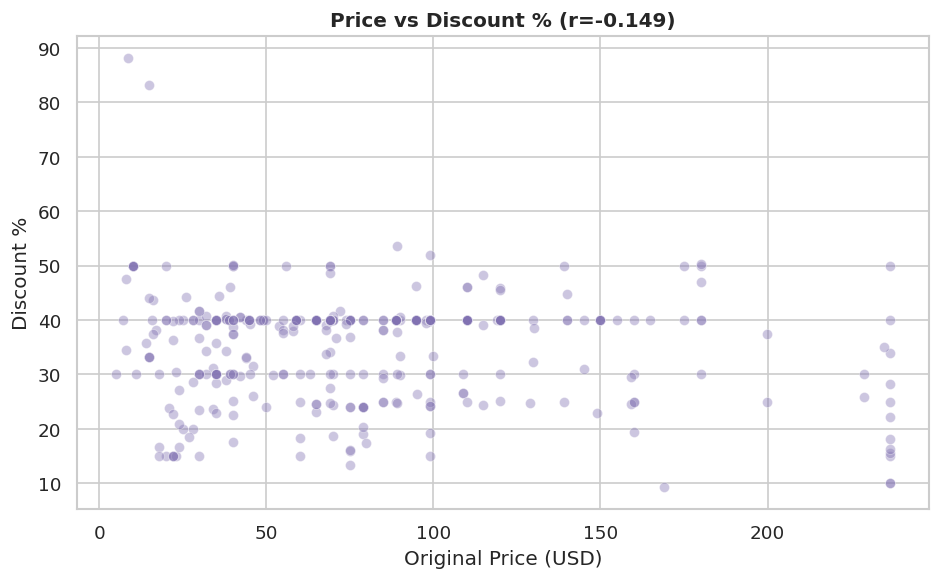


14. DEAD PRODUCT ANALYSIS
  OOS + Not Visible (dead) : 0 (0.0%)
  Dead products with price : 0 → these had commercial value but are now inactive
  Dead product categories:
Series([], )

👉 INTERPRETATION:

- Dead products (OOS + not visible) = catalogue bloat — consider archiving
- Dead products with price → were sellable once — can they be restocked?
- High dead count in a category → that category may be declining
- Dead products still in DB inflate catalogue size and slow search indexing


15. SKU QUALITY ANALYSIS
  Duplicate SKUs           : 0
  Zero price SKUs          : 0
  No category assigned     : 5
  No sub-category assigned : 6
  Not visible SKUs         : 0

  Catalogue Quality Score (estimated) : 99.9/100
  → Good catalogue health

16. CATEGORY PARETO
  Total categories         : 282
  Top 20% (56) categories  : 71.2% of all products
  → Strong Pareto — a few categories dominate the catalogue

  Catalogue Update Freshness:
update_year
2020       7
2021      74
2022      84


In [ ]:
# ============================================================
# PRODUCT CATALOGUE — COMPLETE BUSINESS EDA (ENHANCED)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

FILE = "AWS Gold Tables (1).xlsx"
products = pd.read_excel(FILE, sheet_name="product_catalogue")
products["updated_date"] = pd.to_datetime(products["updated_date"], errors="coerce")

# ============================================================
# 1. BASIC STRUCTURE
# Shows total products, columns, and data types
# Foundation to understand catalogue scale and field availability
# ============================================================
print("="*70)
print("1. BASIC STRUCTURE")
print("="*70)
print("Shape:", products.shape)
print("👉 Each row = one unique product/SKU in the catalogue")
print("\nColumns:\n", products.columns.tolist())
print("\nData Types:\n", products.dtypes)
num_cols = products.select_dtypes(include=np.number).columns.tolist()
cat_cols = products.select_dtypes(include="object").columns.tolist()
print("\nNumerical Columns:", num_cols)
print("\nCategorical Columns:", cat_cols)

# Duplicate SKU check — critical before any product-level join
dup_sku = products["sku"].duplicated().sum()
print(f"\n  Duplicate SKUs : {dup_sku} ({'⚠️ Fix before joining with order_items' if dup_sku > 0 else '✅ Clean'})")
print(f"  Unique SKUs    : {products['sku'].nunique():,}")

# ============================================================
# 2. NULL VALUE ANALYSIS
# Identifies missing data in the catalogue
# Missing price = revenue impact; missing category = can't segment by product
# ============================================================
print("\n" + "="*70)
print("2. NULL VALUE ANALYSIS")
print("="*70)
nulls = products.isnull().sum()
null_pct = (nulls / len(products)) * 100
null_df = pd.DataFrame({
    "Null_Count": nulls,
    "Null_%": null_pct.round(2)
}).sort_values(by="Null_%", ascending=False)
null_df = null_df[null_df["Null_Count"] > 0]
print(null_df)

overall_completeness = (1 - products.isnull().sum().sum() / (products.shape[0]*products.shape[1])) * 100
print(f"\n  Overall Catalogue Completeness : {overall_completeness:.1f}%")

print("\nNULL INTERPRETATION:")
print("""
- special_price NULL → No discount applied (MNAR — business logic, fill with price)
- price NULL → Critical data gap — product cannot be sold without a price
- sub_category NULL → Product classification incomplete → hurts segmentation
- category NULL → Cannot group product into any business vertical
- Products with NULL price should be flagged and reviewed before going live
""")

# Business impact of price nulls
price_null_count = products["price"].isnull().sum()
zero_price_count = (products["price"] == 0).sum()
print(f"  Products with NULL price  : {price_null_count:,}")
print(f"  Products with ZERO price  : {zero_price_count:,}")
print(f"  → Combined unpriceable SKUs: {price_null_count + zero_price_count:,} — cannot generate revenue")

# ============================================================
# 3. PRODUCT MIX (CATEGORICAL ANALYSIS)
# Shows what types of products exist and how they're classified
# ============================================================
print("\n" + "="*70)
print("3. PRODUCT MIX")
print("="*70)
important_cats = ["product_type", "status", "visibility", "main_category_name",
                  "category", "sub_category"]
for col in important_cats:
    if col in products.columns:
        print(f"\n--- {col} ---")
        vc = products[col].value_counts(dropna=False).head(10)
        pct = (vc / len(products) * 100).round(2)
        print(pd.DataFrame({"Count": vc, "%": pct}).to_string())

print("\n👉 INTERPRETATION:")
print("""
- product_type: simple = individual sellable items; configurable = variant parent (no direct sale)
- status: enabled vs disabled — disabled products are hidden from store
- visibility: 'Not Visible Individually' = only shown inside configurables (not in search)
- main_category_name: your highest-level business vertical — drives all category revenue analysis
""")

# ============================================================
# 4. NUMERICAL SUMMARY
# Statistical overview of all numeric fields
# Reveals pricing range, quantity patterns, and data quality issues
# ============================================================
print("\n" + "="*70)
print("4. NUMERICAL ANALYSIS")
print("="*70)
summary = products[num_cols].describe().T
summary["skewness"] = products[num_cols].skew()
summary["variance"]  = products[num_cols].var()
print(summary.round(3))
print("\n👉 INTERPRETATION:")
print("""
- High price skewness → catalogue has a few very expensive premium products
- quantity mean vs median gap → bulk stock in a few SKUs pulling average up
- High variance in price → wide product range (budget to premium)
""")

# ============================================================
# 5. PRICE ANALYSIS
# Core product economics — what does the catalogue actually cost?
# Drives AOV, revenue potential, and positioning strategy
# ============================================================
print("\n" + "="*70)
print("5. PRICE ANALYSIS")
print("="*70)
price = products.loc[products["price"] > 0, "price"]
print(f"  Products with valid price : {len(price):,}")
print(f"  Min price   : ${price.min():.2f}")
print(f"  Max price   : ${price.max():.2f}")
print(f"  Avg price   : ${price.mean():.2f}")
print(f"  Median price: ${price.median():.2f}")
print(f"  Std dev     : ${price.std():.2f}")
print(f"  Mean vs Median gap: ${price.mean()-price.median():.2f} ({'premium skew' if price.mean()>price.median() else 'budget skew'})")

print(f"\n  Percentile breakdown:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"    {p}th pct : ${np.percentile(price, p):.2f}")

# Price by product type
print(f"\n  Price by Product Type:")
for ptype in products["product_type"].dropna().unique():
    sub = products[(products["product_type"]==ptype) & (products["price"]>0)]["price"]
    if len(sub):
        print(f"    {ptype:15s}: count={len(sub):>5,}  mean=${sub.mean():.2f}  median=${sub.median():.2f}  max=${sub.max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Price Analysis", fontweight="bold")

sns.histplot(price.clip(upper=price.quantile(0.98)), bins=60, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(price.mean(), color="red", linestyle="--", label=f"Mean ${price.mean():.0f}")
axes[0].axvline(price.median(), color="green", linestyle="--", label=f"Median ${price.median():.0f}")
axes[0].set_title("Price Distribution (clipped 98th pct)")
axes[0].set_xlabel("Price (USD)")
axes[0].legend()

# Price by category boxplot (top 8 categories)
top8_cats = products["main_category_name"].value_counts().head(8).index
cat_price = products[(products["main_category_name"].isin(top8_cats)) & (products["price"]>0)]
cat_price.boxplot(column="price", by="main_category_name", ax=axes[1], vert=False)
axes[1].set_title("Price Range by Top 8 Categories")
axes[1].set_xlabel("Price (USD)")
plt.sca(axes[1])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("\n👉 INTERPRETATION:")
print("""
- Mean >> Median → a few high-price SKUs are inflating the average
- Wide price range → multi-segment strategy (budget + premium)
- Price by category → identifies which categories are premium vs budget
- Narrow category price range → commoditized; wide → variety/tiered offering
""")

# ============================================================
# 6. PRICE BUCKETING
# Groups products into price ranges for merchandising strategy
# ============================================================
print("\n" + "="*70)
print("6. PRICE BUCKET ANALYSIS")
print("="*70)
products["price_bucket"] = pd.cut(
    products["price"],
    bins=[0, 10, 25, 50, 100, 500, 10000],
    labels=["<$10","$10-25","$25-50","$50-100","$100-500",">$500"]
)
bucket_dist = products["price_bucket"].value_counts().sort_index()
bucket_pct  = (bucket_dist / len(products) * 100).round(2)
print(pd.DataFrame({"Products": bucket_dist, "%": bucket_pct}).to_string())

dominant_bucket = bucket_dist.idxmax()
print(f"\n  Dominant price bucket : {dominant_bucket} ({bucket_pct[dominant_bucket]:.1f}% of catalogue)")
print(f"  Premium (>$100) SKUs  : {bucket_dist[['$100-500','>$500']].sum():,} ({bucket_pct[['$100-500','>$500']].sum():.1f}%)")
print(f"  Budget (<$25) SKUs    : {bucket_dist[['<$10','$10-25']].sum():,} ({bucket_pct[['<$10','$10-25']].sum():.1f}%)")

plt.figure(figsize=(8, 4))
bars = plt.bar(bucket_dist.index.astype(str), bucket_dist.values, color="#4C72B0", edgecolor="white")
plt.title("Products by Price Bucket", fontweight="bold")
plt.ylabel("# Products")
for bar, val, pct in zip(bars, bucket_dist.values, bucket_pct.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f'{val:,}\n({pct}%)', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("\n👉 INTERPRETATION:")
print("""
- Heavy concentration in one bucket → your core price point (optimize here first)
- Few premium SKUs but high revenue → protect stock of these products
- Many budget SKUs → volume strategy; thin margins need high sell-through
""")

# ============================================================
# 7. DISCOUNT ANALYSIS
# Shows how aggressively products are discounted
# High discount penetration = price credibility risk
# ============================================================
print("\n" + "="*70)
print("7. DISCOUNT ANALYSIS")
print("="*70)
disc = products.dropna(subset=["price", "special_price"]).copy()
disc = disc[disc["price"] > 0]
disc["discount_pct"] = (disc["price"] - disc["special_price"]) / disc["price"] * 100
disc = disc[disc["discount_pct"] > 0]

products["has_discount"] = products["special_price"].notna() & (products["price"] > 0)
disc_rate = products["has_discount"].mean() * 100

print(f"  Products on discount      : {len(disc):,}")
print(f"  Discount penetration      : {disc_rate:.1f}%")
print(f"  Avg discount depth        : {disc['discount_pct'].mean():.1f}%")
print(f"  Median discount depth     : {disc['discount_pct'].median():.1f}%")
print(f"  Max discount              : {disc['discount_pct'].max():.1f}%")
print(f"  Products with >50% off    : {(disc['discount_pct']>50).sum():,}")
print(f"  Products with >80% off    : {(disc['discount_pct']>80).sum():,}")

# Revenue at stake from discounts
disc["revenue_at_regular"] = disc["price"]
disc["revenue_at_special"] = disc["special_price"]
disc["discount_value"]     = disc["price"] - disc["special_price"]
print(f"\n  Avg discount value per SKU: ${disc['discount_value'].mean():.2f}")
print(f"  Max discount value on 1 SKU: ${disc['discount_value'].max():.2f}")

# Discount by category
print("\n  Top 10 Categories by Avg Discount %:")
cat_disc = disc.groupby("main_category_name")["discount_pct"].agg(["mean","count"]).reset_index()
cat_disc.columns = ["category","avg_disc_%","discounted_skus"]
cat_disc = cat_disc[cat_disc["discounted_skus"] >= 5].sort_values("avg_disc_%", ascending=False)
print(cat_disc.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Discount Analysis", fontweight="bold")

sns.histplot(disc["discount_pct"], bins=40, ax=axes[0], color="#C44E52", edgecolor="white")
axes[0].axvline(disc["discount_pct"].mean(), color="navy", linestyle="--",
                label=f"Mean {disc['discount_pct'].mean():.1f}%")
axes[0].set_title("Discount Depth Distribution")
axes[0].set_xlabel("Discount %")
axes[0].legend()

top10_cat_disc = cat_disc.head(10)
axes[1].barh(top10_cat_disc["category"][::-1], top10_cat_disc["avg_disc_%"][::-1], color="#DD8452")
axes[1].set_title("Avg Discount % by Category")
axes[1].set_xlabel("Avg Discount %")
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

print("\n👉 INTERPRETATION:")
print("""
- High discount penetration (>40%) → price credibility risk (customers wait for sale)
- Deep discounts (>50%) on many SKUs → margin erosion risk
- Category-wise discount → are low-performing categories being discounted to clear?
- Products with >80% discount → investigate if pricing was set correctly
""")

# ============================================================
# 8. STOCK ANALYSIS
# Inventory health — in-stock products are the only ones that can sell
# ============================================================
print("\n" + "="*70)
print("8. STOCK ANALYSIS")
print("="*70)
stock_dist = products["is_in_stock"].value_counts()
in_stock_pct  = products["is_in_stock"].mean() * 100
out_stock_pct = 100 - in_stock_pct

print(stock_dist)
print(f"\n  In-Stock rate  : {in_stock_pct:.1f}%")
print(f"  Out-of-Stock   : {out_stock_pct:.1f}%  ({(~products['is_in_stock']).sum():,} SKUs)")

qty = products["quantity"].fillna(0)
zero_qty = (qty == 0).sum()
low_qty   = ((qty > 0) & (qty <= 5)).sum()
high_qty  = (qty > 100).sum()
print(f"\n  Quantity stats:")
print(f"    Zero stock SKUs     : {zero_qty:,} ({zero_qty/len(products)*100:.1f}%)")
print(f"    Low stock (1-5 qty) : {low_qty:,} ({low_qty/len(products)*100:.1f}%) ← reorder risk")
print(f"    High stock (>100)   : {high_qty:,} ({high_qty/len(products)*100:.1f}%)")
print(f"    Avg qty             : {qty.mean():.1f}")
print(f"    Median qty          : {qty.median():.0f}")

# Stock by category
cat_stock = products.groupby("main_category_name")["is_in_stock"].mean().mul(100).round(1)
cat_stock = cat_stock.sort_values()
print(f"\n  Categories with worst in-stock rate (bottom 10):")
print(cat_stock.head(10).to_string())
print(f"\n  Categories with best in-stock rate (top 10):")
print(cat_stock.tail(10).to_string())

print("\n👉 INTERPRETATION:")
print("""
- Out-of-stock SKUs = lost sales opportunity — direct revenue leakage
- Low stock (1-5 units) → reorder risk; if sold, goes OOS immediately
- Category with low in-stock rate → supply chain bottleneck or high demand product
- High stock in low-selling category → dead inventory tying up working capital
""")

# ============================================================
# 9. CATEGORY ANALYSIS
# Which categories have the most products — catalogue coverage
# ============================================================
print("\n" + "="*70)
print("9. CATEGORY ANALYSIS")
print("="*70)
top_cat = products["main_category_name"].value_counts().head(15)
top_cat_pct = (top_cat / len(products) * 100).round(2)
print(pd.DataFrame({"Products": top_cat, "%": top_cat_pct}).to_string())

print(f"\n  Total unique main categories : {products['main_category_name'].nunique()}")
print(f"  Total unique categories      : {products['category'].nunique()}")
print(f"  Total unique sub-categories  : {products['sub_category'].nunique()}")

top3_cat_pct = top_cat.head(3).sum() / len(products) * 100
print(f"\n  Top 3 categories hold : {top3_cat_pct:.1f}% of catalogue")
print(f"  → {'Catalogue is concentrated' if top3_cat_pct > 50 else 'Catalogue is well distributed'}")

plt.figure(figsize=(10, 5))
bars = plt.barh(top_cat.index[::-1], top_cat.values[::-1], color="#4C72B0", edgecolor="white")
plt.title("Top 15 Categories by Product Count", fontweight="bold")
plt.xlabel("# Products")
for bar in bars:
    plt.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

# ============================================================
# 10. VISIBILITY ANALYSIS
# Visibility controls whether a product appears in search or category pages
# Not Visible Individually = customer can never find it on its own
# ============================================================
print("\n" + "="*70)
print("10. VISIBILITY ANALYSIS")
print("="*70)
vis_dist = products["visibility"].value_counts()
vis_pct  = (vis_dist / len(products) * 100).round(2)
print(pd.DataFrame({"Count": vis_dist, "%": vis_pct}).to_string())

not_visible = products[products["visibility"] == "Not Visible Individually"]
print(f"\n  Not Visible Individually : {len(not_visible):,} ({len(not_visible)/len(products)*100:.1f}%)")
print(f"  → These products will NEVER appear in customer-facing search or browsing")
print(f"  → Normal for configurable children, but verify no simple products are hidden by mistake")

# Check if any enabled, in-stock, simple products are not visible
hidden_risk = products[
    (products["visibility"] == "Not Visible Individually") &
    (products["is_in_stock"] == True) &
    (products["product_type"] == "simple") &
    (products["status"] == "Enabled")
]
print(f"\n  ⚠️  Enabled simple in-stock products that are NOT visible: {len(hidden_risk):,}")
if len(hidden_risk) > 0:
    print(f"  → These are SELLABLE products customers cannot find — immediate fix needed")

# ============================================================
# 11. HIGH vs LOW PRICE STRATEGY
# Premium vs budget segmentation — both need different marketing
# ============================================================
print("\n" + "="*70)
print("11. HIGH vs LOW PRICE STRATEGY")
print("="*70)
high_price = products[products["price"] > products["price"].quantile(0.9)]
low_price  = products[products["price"] < products["price"].quantile(0.1)]
mid_price  = products[(products["price"] >= products["price"].quantile(0.1)) &
                      (products["price"] <= products["price"].quantile(0.9))]

print(f"  Premium (top 10% price)  : {len(high_price):,} SKUs   avg price ${high_price['price'].mean():.2f}")
print(f"  Budget  (bottom 10%)     : {len(low_price):,}  SKUs   avg price ${low_price['price'].mean():.2f}")
print(f"  Mid-range (middle 80%)   : {len(mid_price):,} SKUs   avg price ${mid_price['price'].mean():.2f}")
print(f"\n  Premium in-stock rate  : {high_price['is_in_stock'].mean()*100:.1f}%")
print(f"  Budget in-stock rate   : {low_price['is_in_stock'].mean()*100:.1f}%")
print(f"  Premium discount rate  : {high_price['has_discount'].mean()*100:.1f}%")
print(f"  Budget discount rate   : {low_price['has_discount'].mean()*100:.1f}%")

print("\n👉 INTERPRETATION:")
print("""
- Premium OOS rate high → losing high-margin sales — prioritize restocking
- Budget discount rate high → already cheap, discounting further kills margin
- Premium discount rate high → may cheapen brand perception
""")

# ============================================================
# 12. CATEGORY-WISE DISCOUNT
# Which categories are being heavily discounted?
# Identifies clearance patterns and margin risk by segment
# ============================================================
print("\n" + "="*70)
print("12. CATEGORY-WISE DISCOUNT ANALYSIS")
print("="*70)
cat_disc_full = disc.groupby("main_category_name").agg(
    avg_disc_pct=("discount_pct","mean"),
    max_disc_pct=("discount_pct","max"),
    discounted_skus=("sku","count"),
    avg_price=("price","mean")
).reset_index()
cat_disc_full = cat_disc_full[cat_disc_full["discounted_skus"] >= 5].sort_values("avg_disc_pct", ascending=False)
print(cat_disc_full.head(15).round(2).to_string(index=False))
print("\n👉 INTERPRETATION:")
print("""
- High avg discount + low avg price category → budget clearance (margin risk)
- High avg discount + high avg price category → premium products on sale (brand risk)
- Deep max discount (>80%) in a category → may be end-of-life products or data error
""")

# ============================================================
# 13. PRICE vs DISCOUNT RELATIONSHIP
# Does higher price correlate with deeper discounts?
# ============================================================
print("\n" + "="*70)
print("13. PRICE vs DISCOUNT RELATIONSHIP")
print("="*70)
price_disc_corr = disc[["price","discount_pct"]].corr().iloc[0,1]
print(f"  Correlation between price and discount% : {price_disc_corr:.3f}")
if price_disc_corr > 0.2:
    print(f"  → Positive: Higher-priced products tend to be discounted MORE")
elif price_disc_corr < -0.2:
    print(f"  → Negative: Lower-priced products tend to be discounted MORE")
else:
    print(f"  → Near zero: No strong relationship between price and discount depth")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=disc["price"].clip(upper=disc["price"].quantile(0.97)),
                y=disc["discount_pct"], alpha=0.4, color="#8172B2")
plt.title(f"Price vs Discount % (r={price_disc_corr:.3f})", fontweight="bold")
plt.xlabel("Original Price (USD)")
plt.ylabel("Discount %")
plt.tight_layout()
plt.show()

# ============================================================
# 14. DEAD PRODUCTS ANALYSIS
# Products with zero visibility AND out of stock — commercial dead weight
# ============================================================
print("\n" + "="*70)
print("14. DEAD PRODUCT ANALYSIS")
print("="*70)
dead_products = products[
    (products["is_in_stock"] == False) &
    (products["visibility"] == "Not Visible Individually")
]
disabled_products = products[products["status"] == "Disabled"] if "status" in products.columns else pd.DataFrame()

print(f"  OOS + Not Visible (dead) : {len(dead_products):,} ({len(dead_products)/len(products)*100:.1f}%)")
if len(disabled_products):
    print(f"  Disabled products        : {len(disabled_products):,} ({len(disabled_products)/len(products)*100:.1f}%)")

dead_with_price = dead_products[dead_products["price"] > 0]
print(f"  Dead products with price : {len(dead_with_price):,} → these had commercial value but are now inactive")
print(f"  Dead product categories:")
print(dead_products["main_category_name"].value_counts().head(8).to_string())

print("\n👉 INTERPRETATION:")
print("""
- Dead products (OOS + not visible) = catalogue bloat — consider archiving
- Dead products with price → were sellable once — can they be restocked?
- High dead count in a category → that category may be declining
- Dead products still in DB inflate catalogue size and slow search indexing
""")

# ============================================================
# 15. SKU QUALITY ANALYSIS
# Data completeness at the product level
# ============================================================
print("\n" + "="*70)
print("15. SKU QUALITY ANALYSIS")
print("="*70)
print(f"  Duplicate SKUs           : {dup_sku}")
zero_price_count = (products["price"] == 0).sum()
no_cat = products["main_category_name"].isnull().sum()
no_sub = products["sub_category"].isnull().sum()
not_vis = (products["visibility"] == "Not Visible Individually").sum()

print(f"  Zero price SKUs          : {zero_price_count:,}")
print(f"  No category assigned     : {no_cat:,}")
print(f"  No sub-category assigned : {no_sub:,}")
print(f"  Not visible SKUs         : {not_vis:,}")

sku_quality_score = 100 - (
    (dup_sku + zero_price_count + no_cat) / len(products) * 100
)
print(f"\n  Catalogue Quality Score (estimated) : {max(0, sku_quality_score):.1f}/100")
print(f"  → {'Good catalogue health' if sku_quality_score > 80 else 'Catalogue needs cleanup before analytics'}")

# ============================================================
# 16. CATEGORY PARETO
# Top 20% of categories account for what % of products?
# ============================================================
print("\n" + "="*70)
print("16. CATEGORY PARETO")
print("="*70)
cat_counts = products["main_category_name"].value_counts().dropna()
top_20_pct_count = max(1, int(0.2 * len(cat_counts)))
top_categories = cat_counts.head(top_20_pct_count)
pareto_pct = top_categories.sum() / cat_counts.sum() * 100
print(f"  Total categories         : {len(cat_counts)}")
print(f"  Top 20% ({top_20_pct_count}) categories  : {pareto_pct:.1f}% of all products")
print(f"  → {'Strong Pareto — a few categories dominate the catalogue' if pareto_pct > 70 else 'Balanced catalogue spread'}")

# Catalogue freshness
if "updated_date" in products.columns:
    print("\n  Catalogue Update Freshness:")
    products["update_year"] = products["updated_date"].dt.year
    upd = products["update_year"].value_counts().sort_index().dropna()
    print(upd.to_string())
    recent_updates = (products["updated_date"] >= products["updated_date"].max() - pd.Timedelta(days=180)).sum()
    print(f"\n  Products updated in last 6 months : {recent_updates:,} ({recent_updates/len(products)*100:.1f}%)")
    print(f"  → Stale products (not updated recently) : {len(products)-recent_updates:,} — may have outdated pricing/info")

# ============================================================
# FINAL BUSINESS SUMMARY
# One-stop view of all critical product catalogue KPIs
# ============================================================
print("\n" + "="*70)
print("FINAL BUSINESS SUMMARY")
print("="*70)
print(f"""
  Total Products            : {len(products):,}
  Unique SKUs               : {products['sku'].nunique():,}
  Catalogue Completeness    : {overall_completeness:.1f}%
  In-Stock Rate             : {in_stock_pct:.1f}%
  Out-of-Stock SKUs         : {(~products['is_in_stock']).sum():,}
  Zero-Price SKUs           : {zero_price_count:,}
  Discount Penetration      : {disc_rate:.1f}%
  Avg Price                 : ${price.mean():.2f}
  Median Price              : ${price.median():.2f}
  Premium SKUs (top 10%)    : {len(high_price):,}
  Budget SKUs (bottom 10%)  : {len(low_price):,}
  Dead Products             : {len(dead_products):,}
  Hidden Sellable Products  : {len(hidden_risk):,}  ← fix immediately
  Unique Main Categories    : {products['main_category_name'].nunique()}
  Catalogue Quality Score   : {max(0,sku_quality_score):.1f}/100
""")

print("\n👉 TOP 3 ACTIONS FROM THIS EDA:")
print(f"""
  1. Fix {len(hidden_risk):,} enabled in-stock simple products with 'Not Visible' visibility
  2. Investigate {zero_price_count:,} zero-price SKUs — they cannot generate revenue
  3. Review {len(dead_products):,} dead products (OOS + not visible) for archiving or restocking
""")

print("\n✅ PRODUCT CATALOGUE EDA COMPLETE")

1. BASIC STRUCTURE
Shape: (13395, 43)
👉 Each row = one invoice (a confirmed, billed order)
👉 Not all orders generate invoices — only paid/processed ones do

Columns:
 ['invoice_id', 'order_id', 'increment_id', 'invoice_date', 'created_at_ts', 'updated_at_ts', 'invoice_state', 'order_increment_id', 'order_state', 'order_status', 'customer_id', 'customer_is_guest', 'payment_method', 'store_id', 'store_name', 'order_currency_code', 'base_currency_code', 'store_currency_code', 'global_currency_code', 'subtotal', 'subtotal_incl_tax', 'tax_amount', 'discount_amount', 'shipping_amount', 'shipping_incl_tax', 'shipping_tax_amount', 'grand_total', 'total_qty', 'billing_firstname_token', 'billing_lastname_token', 'billing_email_token', 'billing_city', 'billing_region', 'billing_region_code', 'billing_country_id', 'billing_postcode_token', 'latest_comment', 'latest_comment_at', 'latest_comment_customer_notified', 'comments_count', '_extract_date', '_run_id', '_gold_loaded_at']

Data Types:
 invoic

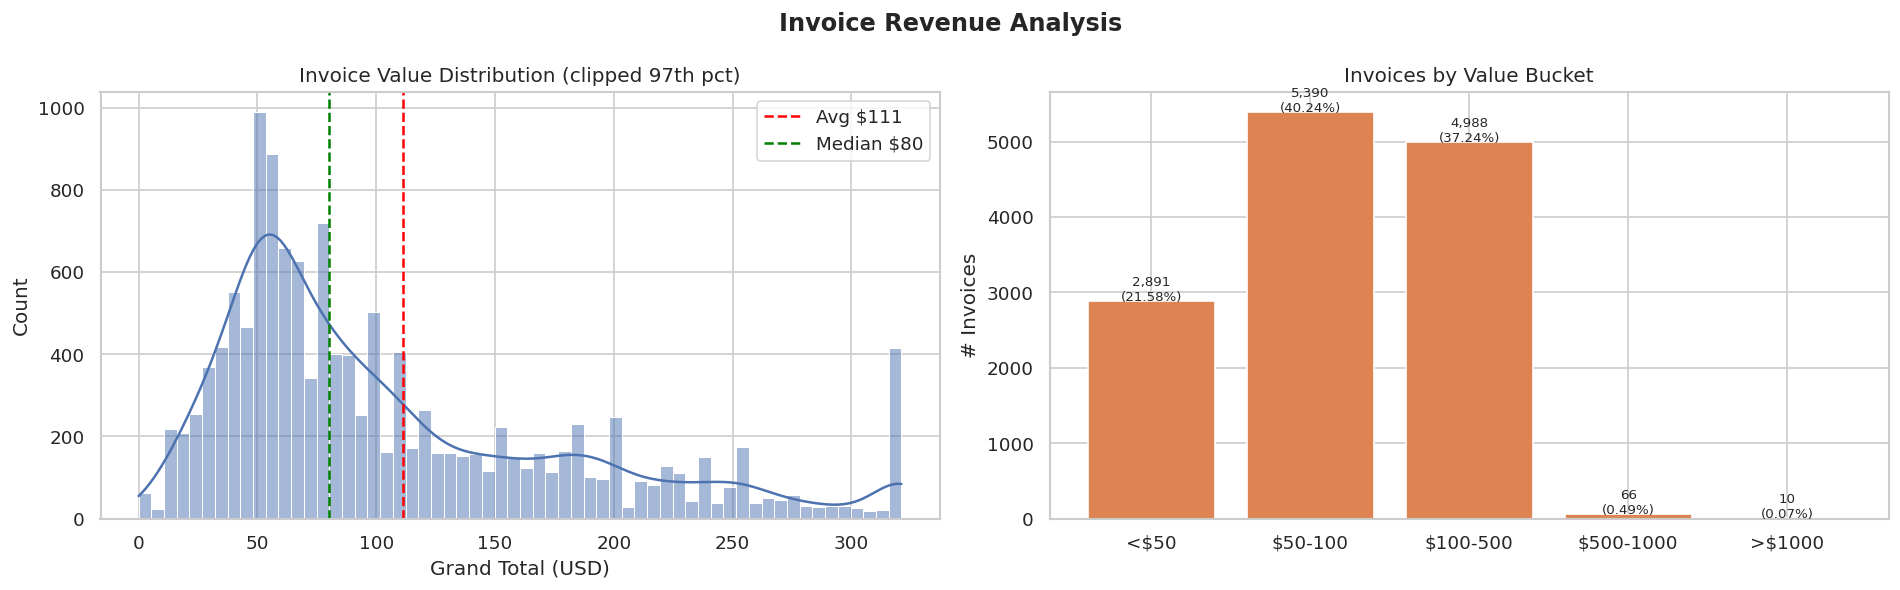


👉 INTERPRETATION:

- Total invoiced revenue vs orders GMV → gap = canceled/pending orders never invoiced
- High AIV vs Median gap → revenue is driven by a few large transactions (B2B risk)
- Revenue waterfall → shows exactly where money is added (tax, shipping) and lost (discounts)
- Dominant invoice bucket → tells you the typical transaction size of the business


6. TIME SERIES ANALYSIS
Monthly Revenue Trend:
     ym  invoices  revenue        aiv  revenue_growth_%
2023-04       106 12990.05 122.547642               NaN
2023-05       370 44003.64 118.928757            238.75
2023-06       378 42478.92 112.378095             -3.46
2023-07       494 52027.14 105.318097             22.48
2023-08       562 53147.65  94.568772              2.15
2023-09       496 52930.40 106.714516             -0.41
2023-10       368 41495.84 112.760435            -21.60
2023-11       375 42300.95 112.802533              1.94
2023-12       661 69943.25 105.814297             65.35
2024-01       642 70195.

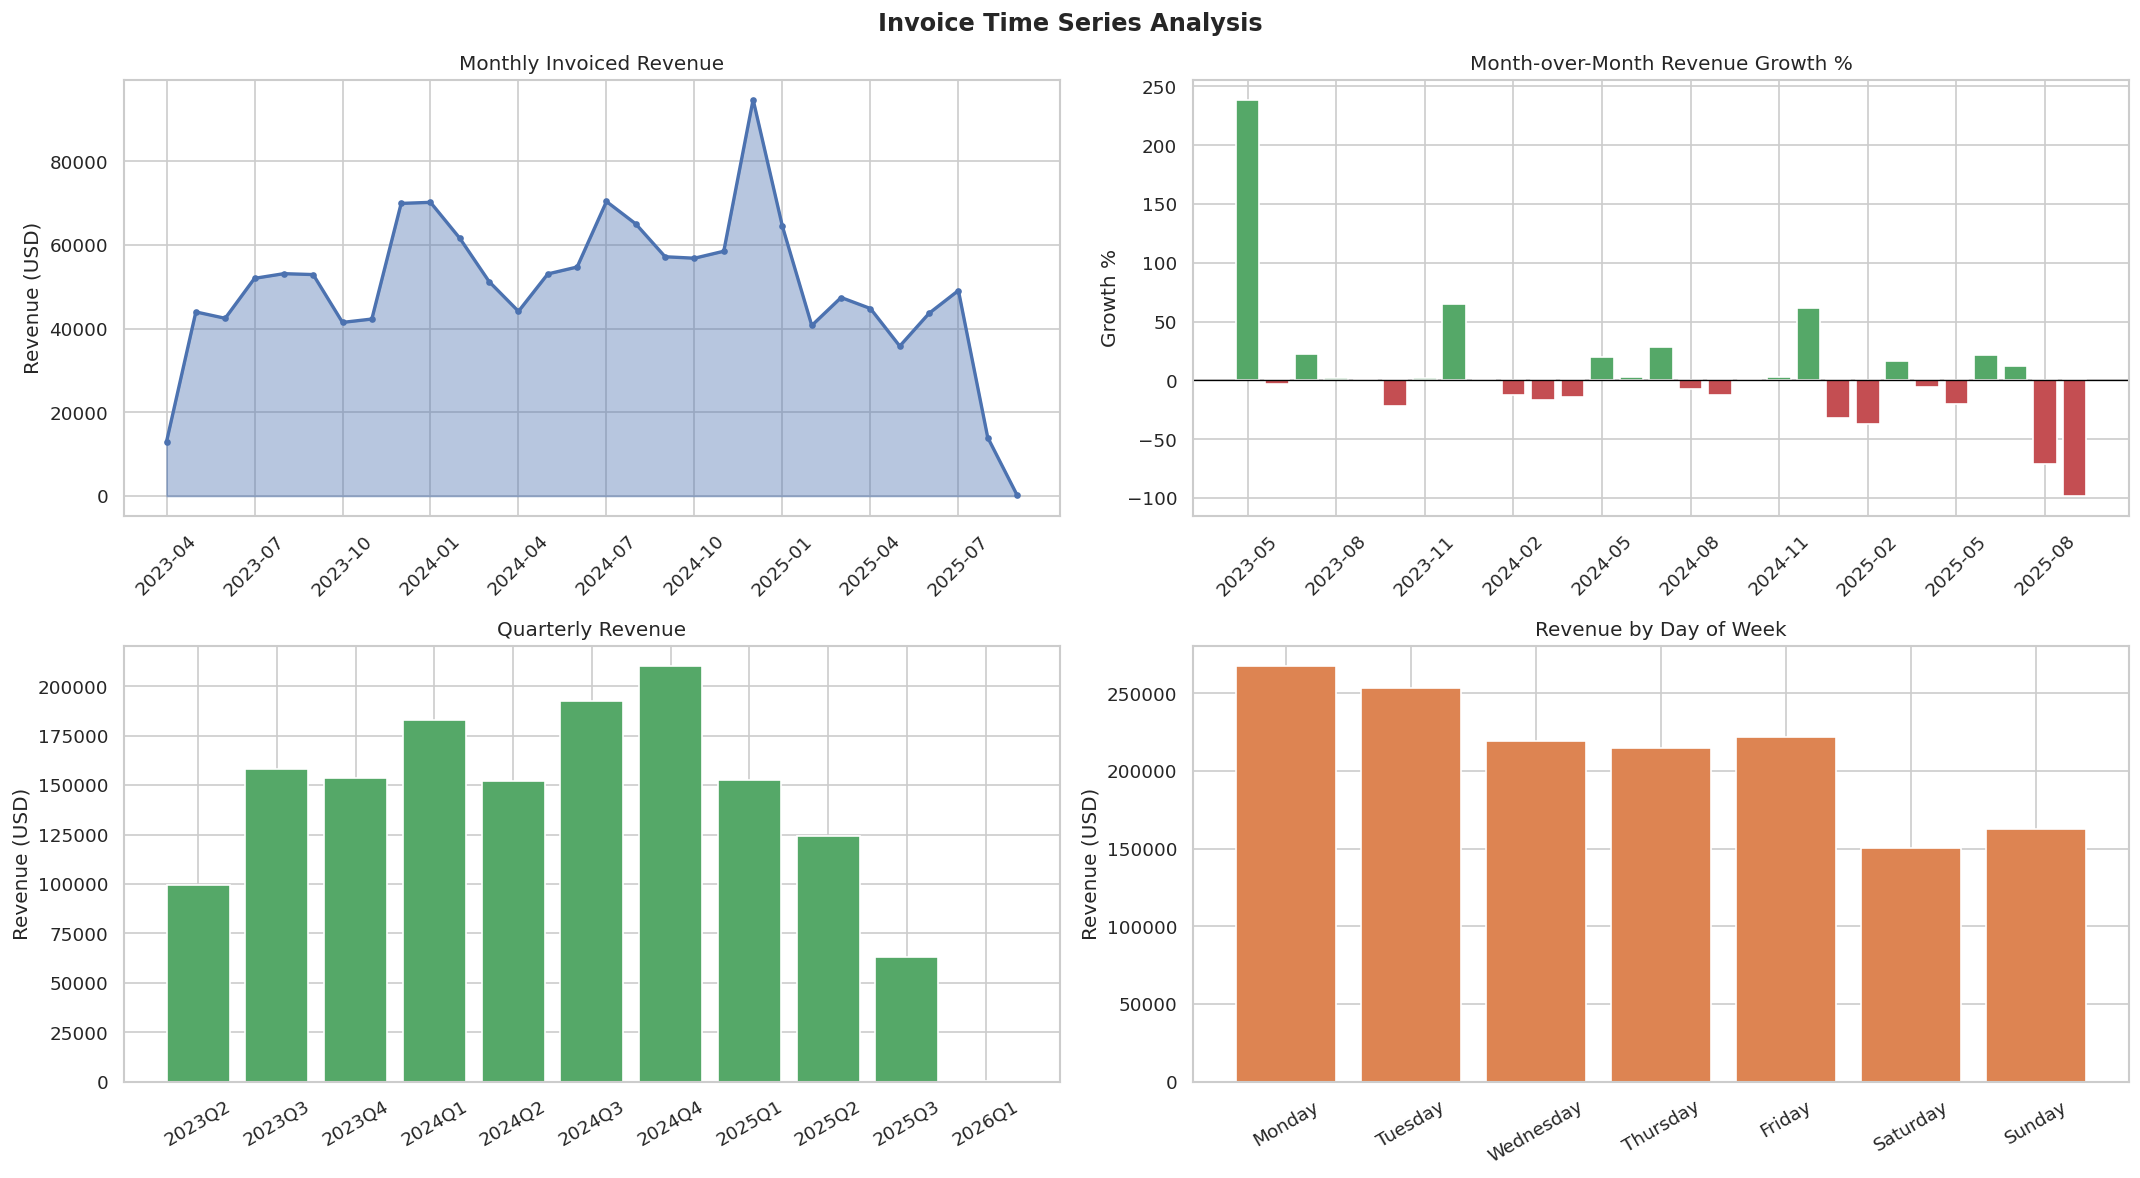


👉 INTERPRETATION:

- Consistent monthly growth → healthy scaling business
- Sharp MoM dips → investigate: promotions ending, supply issues, or seasonality
- Quarterly pattern → reveals seasonal peaks (Q4 holiday, Q1 new year dip etc.)
- Day of week → lowest day = best day to run re-engagement campaigns (less noise)
- Peak-to-trough ratio > 3x → high revenue seasonality, plan cash flow carefully


7. TAX ANALYSIS
  Invoices with tax       : 2,296 (17.1%)
  Tax-free invoices       : 11,099 (82.9%)
  Total tax collected     : $19,740.94
  Avg tax per invoice     : $8.60
  Avg effective tax rate  : 1.35%
  Max tax on one invoice  : $177.48

  Tax collected as % of revenue: 1.33%

👉 INTERPRETATION:

  - Tax-free invoices → B2B (exempt), non-taxable states, or international orders
  - High effective tax rate variance → selling across multiple tax jurisdictions
  - Tax as % of revenue → pure cost of compliance (passed through to customer)
  - Compare taxed vs tax-free AIV → B2B (tax-free) of

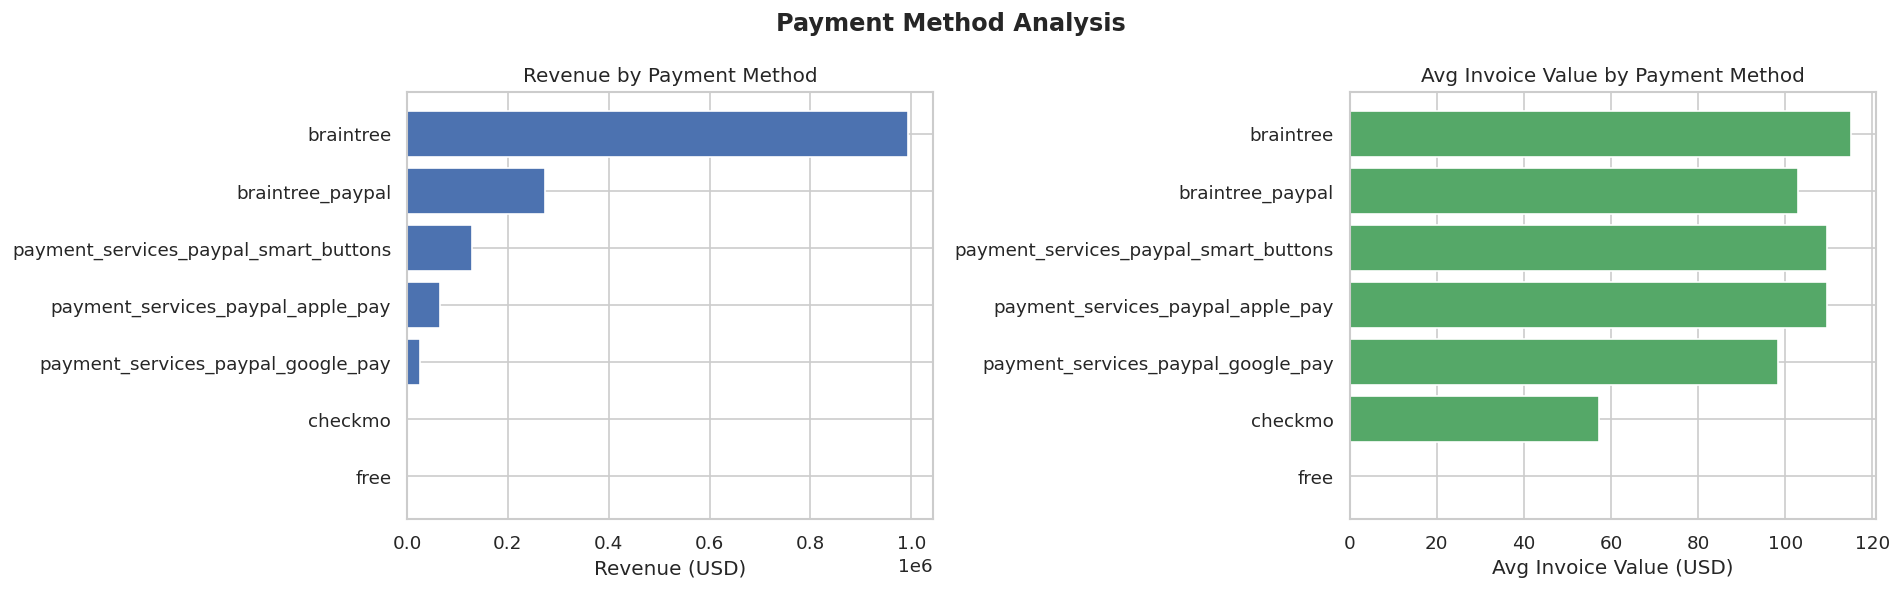


👉 INTERPRETATION:

- Payment method with highest revenue → your most critical checkout flow to optimize
- Payment method with highest AIV → premium customers prefer this method
- Large gap between % invoices and % revenue → some methods process fewer but larger orders
- Median vs Mean AIV gap by method → outliers in certain payment channels


10. INVOICE STATE ANALYSIS
 invoice_state  count  total_rev        aiv  %_count  %_rev
             1      3     447.77 149.256667     0.02   0.03
             2  13392 1488904.88 111.178680    99.98  99.97

👉 INTERPRETATION:

- High % paid invoices → strong cash collection process
- Pending invoices → track as accounts receivable; aging analysis needed
- Cancelled invoices in the table → revenue that was invoiced but then reversed


11. HIGH VALUE INVOICE ANALYSIS
  High Value threshold (95th pct) : $270.00
  High Value invoice count        : 669 (5.0%)
  Their revenue contribution      : $261,654.06 (17.6% of total)
  Avg high-value invoice    

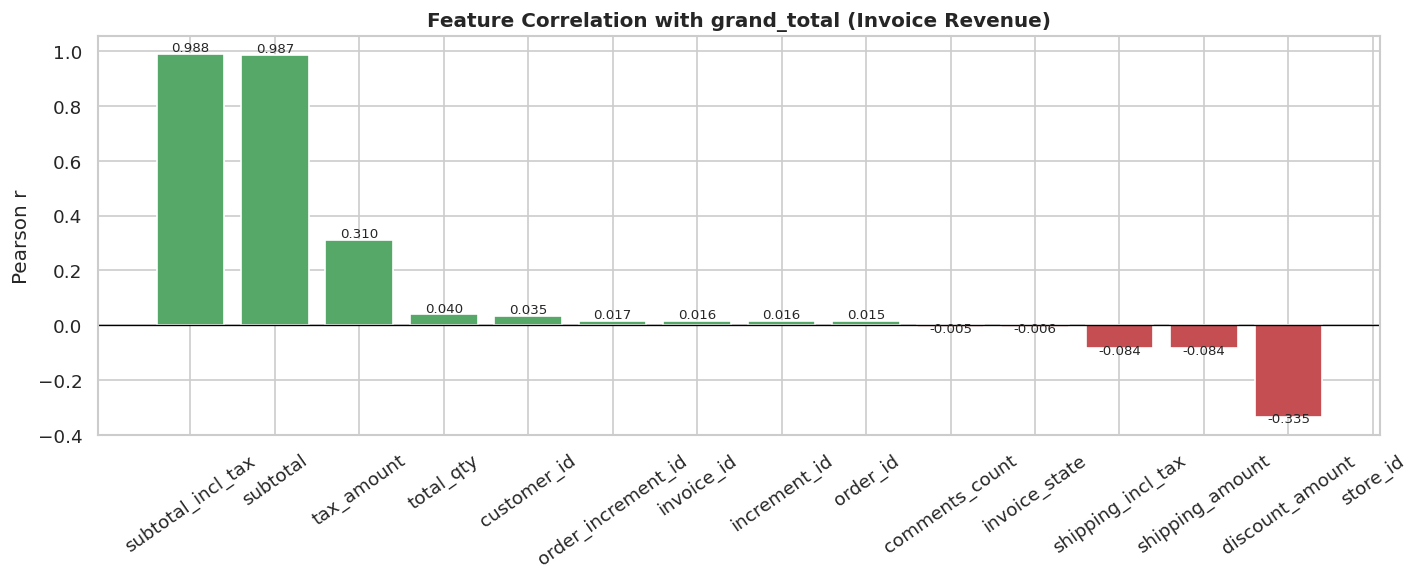


👉 INTERPRETATION:

- subtotal → near +1.0 with grand_total (expected — subtotal is base of invoice)
- tax → positive correlation (larger invoices pay more tax)
- shipping → moderate positive (larger orders may pay more for shipping)
- discount → negative (discounts reduce final invoice value)
- Use these for feature selection if building invoice prediction models


FINAL BUSINESS SUMMARY

  Total Invoices              : 13,395
  Total Invoiced Revenue      : $1,489,352.65
  Avg Invoice Value (AIV)     : $      111.19
  Median Invoice Value        : $       79.99
  High Value Invoices (top 5%): 669  (17.6% of revenue)
  Free Shipping Invoices      : 9,593  (71.6%)
  Total Shipping Collected    : $   41,802.90
  Total Tax Collected         : $   19,740.94
  Total Discount Given        : $   25,879.07
  Avg Effective Tax Rate      :        1.35%
  Discount as % of Revenue    :        1.74%


👉 TOP 3 ACTIONS FROM THIS EDA:

  1. Monitor MoM revenue growth — best month was 2024-12, track t

In [ ]:
# ============================================================
# INVOICES TABLE — COMPLETE BUSINESS + TECH EDA (ENHANCED)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

FILE = "AWS Gold Tables (1).xlsx"
invoices = pd.read_excel(FILE, sheet_name="invoices")

# ============================================================
# 1. BASIC STRUCTURE
# Shows scale of invoice data — each row = one confirmed financial document
# Invoices = orders that have been confirmed and billed (subset of all orders)
# ============================================================
print("="*70)
print("1. BASIC STRUCTURE")
print("="*70)
print("Shape:", invoices.shape)
print("👉 Each row = one invoice (a confirmed, billed order)")
print("👉 Not all orders generate invoices — only paid/processed ones do")
print("\nColumns:\n", invoices.columns.tolist())
print("\nData Types:\n", invoices.dtypes)
num_cols = invoices.select_dtypes(include=np.number).columns.tolist()
cat_cols = invoices.select_dtypes(include="object").columns.tolist()
print("\nNumerical Columns:", num_cols)
print("\nCategorical Columns:", cat_cols)

# ============================================================
# 2. NULL ANALYSIS
# Missing fields in invoices = financial data gaps
# More serious than nulls in orders — invoices are legal documents
# ============================================================
print("\n" + "="*70)
print("2. NULL ANALYSIS")
print("="*70)
nulls = invoices.isnull().sum()
null_pct = (nulls / len(invoices)) * 100
null_df = pd.DataFrame({
    "Null_Count": nulls,
    "Null_%": null_pct.round(2)
}).sort_values(by="Null_%", ascending=False)
null_df = null_df[null_df["Null_Count"] > 0]
print(null_df)

overall_completeness = (1 - invoices.isnull().sum().sum()/(invoices.shape[0]*invoices.shape[1]))*100
print(f"\n  Invoice Data Completeness : {overall_completeness:.1f}%")

print("""
NULL BUSINESS LOGIC:
- tax_amount = 0 → order not taxable (MNAR — B2B exemptions or non-taxable states)
- shipping_amount = 0 → free shipping applied (NOT missing — intentional)
- payment_method NULL → data pipeline issue (critical — every invoice must have payment method)
- discount_amount = 0 or NULL → no discount was applied on the order
""")

payment_null = invoices["payment_method"].isnull().sum() if "payment_method" in invoices.columns else 0
if payment_null > 0:
    print(f"  ⚠️  {payment_null:,} invoices with NULL payment_method — investigate data pipeline")

# ============================================================
# 3. CATEGORICAL ANALYSIS
# Breakdown of invoice states, payment methods, and customer types
# ============================================================
print("\n" + "="*70)
print("3. CATEGORICAL ANALYSIS")
print("="*70)
important_cats = ["invoice_state", "payment_method", "order_currency_code",
                  "customer_is_guest"] if "customer_is_guest" in invoices.columns else \
                 ["invoice_state", "payment_method", "order_currency_code"]
important_cats = [c for c in important_cats if c in invoices.columns]

for col in important_cats:
    print(f"\n--- {col} ---")
    vc = invoices[col].value_counts(dropna=False).head(10)
    pct = (vc / len(invoices) * 100).round(2)
    print(pd.DataFrame({"Count": vc, "%": pct}).to_string())

print("\n👉 INTERPRETATION:")
print("""
- invoice_state: 'paid' is healthy; 'pending' = cash not yet collected
- payment_method dominance → checkout optimization priority
- currency code → confirms primary operating market
- Pending invoices → accounts receivable risk
""")

# ============================================================
# 4. NUMERICAL ANALYSIS
# Statistical overview of all financial fields in the invoice
# ============================================================
print("\n" + "="*70)
print("4. NUMERICAL ANALYSIS")
print("="*70)
summary = invoices[num_cols].describe().T
summary["skewness"] = invoices[num_cols].skew()
summary["variance"]  = invoices[num_cols].var()
print(summary.round(3))
print("\n👉 INTERPRETATION:")
print("""
- grand_total high skewness → revenue concentrated in few large invoices
- shipping_amount variance → indicates mixed free/paid shipping policy
- tax_amount stats → reveals effective tax coverage across invoices
- discount_amount mean → average discount being passed through to invoice level
""")

# ============================================================
# 5. REVENUE ANALYSIS — MOST IMPORTANT
# Invoiced revenue = actual confirmed money owed to the business
# This is more reliable than orders table (includes only confirmed transactions)
# ============================================================
print("\n" + "="*70)
print("5. REVENUE ANALYSIS")
print("="*70)
invoices["invoice_date"] = pd.to_datetime(invoices["invoice_date"], errors="coerce")
rev = invoices["grand_total"]
total_rev = rev.sum()
aov = rev.mean()
median_inv = rev.median()

print(f"  Total Invoiced Revenue  : ${total_rev:>12,.2f}")
print(f"  Avg Invoice Value (AIV) : ${aov:>12,.2f}")
print(f"  Median Invoice Value    : ${median_inv:>12,.2f}")
print(f"  AIV vs Median gap       : ${aov - median_inv:>12,.2f}  ({'large — few big invoices skew average' if aov-median_inv > 50 else 'small — consistent invoice values'})")
print(f"  Min Invoice             : ${rev.min():.2f}")
print(f"  Max Invoice             : ${rev.max():.2f}")
print(f"  Std Deviation           : ${rev.std():.2f}")

print(f"\n  Percentile breakdown:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"    {p}th pct : ${np.percentile(rev.dropna(), p):.2f}")

# Pareto on invoices
top20_count = int(0.2 * len(invoices))
top20 = invoices.nlargest(top20_count, "grand_total")
pareto_pct = top20["grand_total"].sum() / total_rev * 100
print(f"\n  PARETO: Top 20% invoices = {pareto_pct:.1f}% of total revenue")
print(f"  Bottom 80% invoices     = {100-pareto_pct:.1f}% of total revenue")

# Subtotal vs Grand Total reconciliation
if "subtotal" in invoices.columns:
    total_subtotal = invoices["subtotal"].sum()
    total_tax      = invoices["tax_amount"].sum() if "tax_amount" in invoices.columns else 0
    total_shipping = invoices["shipping_amount"].sum() if "shipping_amount" in invoices.columns else 0
    total_discount = invoices["discount_amount"].abs().sum() if "discount_amount" in invoices.columns else 0
    print(f"\n  Revenue Waterfall:")
    print(f"    Subtotal (products)      : ${total_subtotal:>12,.2f}")
    print(f"    + Tax collected          : ${total_tax:>12,.2f}")
    print(f"    + Shipping collected     : ${total_shipping:>12,.2f}")
    print(f"    - Discounts given        : ${total_discount:>12,.2f}")
    print(f"    = Grand Total            : ${total_rev:>12,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Invoice Revenue Analysis", fontweight="bold")

sns.histplot(rev.clip(upper=rev.quantile(0.97)), bins=60, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(aov, color="red", linestyle="--", label=f"Avg ${aov:.0f}")
axes[0].axvline(median_inv, color="green", linestyle="--", label=f"Median ${median_inv:.0f}")
axes[0].set_title("Invoice Value Distribution (clipped 97th pct)")
axes[0].set_xlabel("Grand Total (USD)")
axes[0].legend()

# Revenue buckets
invoices["rev_bucket"] = pd.cut(rev, bins=[0,50,100,500,1000,10000],
    labels=["<$50","$50-100","$100-500","$500-1000",">$1000"])
bucket = invoices["rev_bucket"].value_counts().sort_index()
bucket_pct = (bucket / len(invoices) * 100).round(2)
bars = axes[1].bar(bucket.index.astype(str), bucket.values, color="#DD8452", edgecolor="white")
axes[1].set_title("Invoices by Value Bucket")
axes[1].set_ylabel("# Invoices")
for bar, val, pct in zip(bars, bucket.values, bucket_pct.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val:,}\n({pct}%)', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("\n👉 INTERPRETATION:")
print("""
- Total invoiced revenue vs orders GMV → gap = canceled/pending orders never invoiced
- High AIV vs Median gap → revenue is driven by a few large transactions (B2B risk)
- Revenue waterfall → shows exactly where money is added (tax, shipping) and lost (discounts)
- Dominant invoice bucket → tells you the typical transaction size of the business
""")

# ============================================================
# 6. TIME SERIES ANALYSIS
# Revenue and invoice volume trends over time
# ============================================================
print("\n" + "="*70)
print("6. TIME SERIES ANALYSIS")
print("="*70)
invoices["month"]   = invoices["invoice_date"].dt.to_period("M")
invoices["week"]    = invoices["invoice_date"].dt.to_period("W")
invoices["quarter"] = invoices["invoice_date"].dt.to_period("Q")
invoices["day"]     = invoices["invoice_date"].dt.day_name()

monthly = invoices.groupby("month").agg(
    invoices=("invoice_id","count") if "invoice_id" in invoices.columns else ("grand_total","count"),
    revenue=("grand_total","sum"),
    aiv=("grand_total","mean")
).reset_index()
monthly["revenue_growth_%"] = monthly["revenue"].pct_change().mul(100).round(2)
monthly["ym"] = monthly["month"].astype(str)

quarterly = invoices.groupby("quarter").agg(
    invoices=("grand_total","count"),
    revenue=("grand_total","sum")
).reset_index()
quarterly["quarter"] = quarterly["quarter"].astype(str)

weekly = invoices.groupby("week")["grand_total"].sum().reset_index()
weekly["yw"] = weekly["week"].astype(str)

dow = invoices.groupby("day")["grand_total"].agg(["count","sum"]).reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
dow.columns = ["invoice_count","revenue"]

print("Monthly Revenue Trend:")
print(monthly[["ym","invoices","revenue","aiv","revenue_growth_%"]].to_string(index=False))
print("\nQuarterly Revenue:")
print(quarterly.to_string(index=False))
print("\nDay of Week Pattern:")
print(dow.to_string())

best_month = monthly.loc[monthly["revenue"].idxmax(), "ym"]
worst_month = monthly.loc[monthly["revenue"].idxmin(), "ym"]
print(f"\n  Best revenue month  : {best_month} (${monthly['revenue'].max():,.2f})")
print(f"  Worst revenue month : {worst_month} (${monthly['revenue'].min():,.2f})")
print(f"  Peak-to-trough ratio: {monthly['revenue'].max()/monthly['revenue'].min():.1f}x")

step = max(1, len(monthly)//10)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("Invoice Time Series Analysis", fontweight="bold")

# Monthly revenue
axes[0,0].fill_between(monthly["ym"], monthly["revenue"], color="#4C72B0", alpha=0.4)
axes[0,0].plot(monthly["ym"], monthly["revenue"], color="#4C72B0", linewidth=2, marker="o", markersize=3)
axes[0,0].set_title("Monthly Invoiced Revenue")
axes[0,0].set_ylabel("Revenue (USD)")
axes[0,0].tick_params(axis="x", rotation=45)
axes[0,0].set_xticks(range(0, len(monthly), step))
axes[0,0].set_xticklabels(monthly["ym"].iloc[::step], rotation=45)

# MoM growth
growth = monthly["revenue_growth_%"].dropna()
g_colors = ["#55A868" if v >= 0 else "#C44E52" for v in growth]
axes[0,1].bar(monthly["ym"].iloc[1:], growth, color=g_colors, edgecolor="white")
axes[0,1].axhline(0, color="black", linewidth=0.8)
axes[0,1].set_title("Month-over-Month Revenue Growth %")
axes[0,1].set_ylabel("Growth %")
axes[0,1].tick_params(axis="x", rotation=45)
axes[0,1].set_xticks(range(0, len(growth), step))
axes[0,1].set_xticklabels(monthly["ym"].iloc[1::step], rotation=45)

# Quarterly
axes[1,0].bar(quarterly["quarter"], quarterly["revenue"], color="#55A868", edgecolor="white")
axes[1,0].set_title("Quarterly Revenue")
axes[1,0].set_ylabel("Revenue (USD)")
axes[1,0].tick_params(axis="x", rotation=30)

# Day of week
axes[1,1].bar(dow.index, dow["revenue"], color="#DD8452", edgecolor="white")
axes[1,1].set_title("Revenue by Day of Week")
axes[1,1].set_ylabel("Revenue (USD)")
axes[1,1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("\n👉 INTERPRETATION:")
print("""
- Consistent monthly growth → healthy scaling business
- Sharp MoM dips → investigate: promotions ending, supply issues, or seasonality
- Quarterly pattern → reveals seasonal peaks (Q4 holiday, Q1 new year dip etc.)
- Day of week → lowest day = best day to run re-engagement campaigns (less noise)
- Peak-to-trough ratio > 3x → high revenue seasonality, plan cash flow carefully
""")

# ============================================================
# 7. TAX ANALYSIS
# How much tax is being collected and at what effective rate
# ============================================================
print("\n" + "="*70)
print("7. TAX ANALYSIS")
print("="*70)
if "tax_amount" in invoices.columns and "subtotal_incl_tax" in invoices.columns:
    taxed_inv = invoices[invoices["tax_amount"] > 0]
    tax_free   = invoices[invoices["tax_amount"] == 0]
    eff_rate   = (invoices["tax_amount"] / invoices["subtotal_incl_tax"].replace(0, np.nan) * 100).dropna()

    print(f"  Invoices with tax       : {len(taxed_inv):,} ({len(taxed_inv)/len(invoices)*100:.1f}%)")
    print(f"  Tax-free invoices       : {len(tax_free):,} ({len(tax_free)/len(invoices)*100:.1f}%)")
    print(f"  Total tax collected     : ${invoices['tax_amount'].sum():,.2f}")
    print(f"  Avg tax per invoice     : ${taxed_inv['tax_amount'].mean():.2f}")
    print(f"  Avg effective tax rate  : {eff_rate.mean():.2f}%")
    print(f"  Max tax on one invoice  : ${invoices['tax_amount'].max():.2f}")

    print(f"\n  Tax collected as % of revenue: {invoices['tax_amount'].sum()/total_rev*100:.2f}%")
    print("\n👉 INTERPRETATION:")
    print("""
  - Tax-free invoices → B2B (exempt), non-taxable states, or international orders
  - High effective tax rate variance → selling across multiple tax jurisdictions
  - Tax as % of revenue → pure cost of compliance (passed through to customer)
  - Compare taxed vs tax-free AIV → B2B (tax-free) often = higher invoice values
    """)
    print(f"  Taxed invoice avg value   : ${taxed_inv['grand_total'].mean():.2f}")
    print(f"  Tax-free invoice avg value: ${tax_free['grand_total'].mean():.2f}")

# ============================================================
# 8. SHIPPING ANALYSIS
# How much shipping revenue is collected vs given away free
# ============================================================
print("\n" + "="*70)
print("8. SHIPPING ANALYSIS")
print("="*70)
free_ship = invoices[invoices["shipping_amount"] == 0]
paid_ship  = invoices[invoices["shipping_amount"] > 0]

print(f"  Free shipping invoices   : {len(free_ship):,} ({len(free_ship)/len(invoices)*100:.1f}%)")
print(f"  Paid shipping invoices   : {len(paid_ship):,} ({len(paid_ship)/len(invoices)*100:.1f}%)")
print(f"  Total shipping collected : ${invoices['shipping_amount'].sum():,.2f}")
print(f"  Avg shipping charge      : ${paid_ship['shipping_amount'].mean():.2f}  (paid invoices only)")
print(f"  Max shipping on 1 invoice: ${invoices['shipping_amount'].max():.2f}")
print(f"\n  AIV — free shipping      : ${free_ship['grand_total'].mean():.2f}")
print(f"  AIV — paid shipping      : ${paid_ship['grand_total'].mean():.2f}")

aiv_diff = free_ship["grand_total"].mean() - paid_ship["grand_total"].mean()
print(f"  AIV diff (free - paid)   : ${aiv_diff:.2f}")
if aiv_diff > 0:
    print(f"  → Free shipping orders have HIGHER value — threshold strategy is working")
else:
    print(f"  → Paid shipping orders have HIGHER value — premium customers pay for shipping")

print(f"\n  Shipping revenue as % of total revenue: {invoices['shipping_amount'].sum()/total_rev*100:.2f}%")

print("\n👉 INTERPRETATION:")
print("""
- High free shipping % → margin impact is real (shipping cost absorbed by business)
- Free ship AIV > paid ship AIV → customers spend more to qualify for free ship threshold
- Shipping revenue % → how much of top-line is actually shipping (not product margin)
- High max shipping → likely large/heavy items; check if shipping pricing is adequate
""")

# ============================================================
# 9. PAYMENT METHOD ANALYSIS
# Which payment methods drive the most revenue and have best quality
# ============================================================
print("\n" + "="*70)
print("9. PAYMENT METHOD ANALYSIS")
print("="*70)
pm_analysis = invoices.groupby("payment_method").agg(
    invoice_count=("grand_total","count"),
    total_rev=("grand_total","sum"),
    aiv=("grand_total","mean"),
    median_rev=("grand_total","median"),
    total_tax=("tax_amount","sum"),
    total_shipping=("shipping_amount","sum"),
    total_discount=("discount_amount","sum") if "discount_amount" in invoices.columns else ("grand_total","count")
).reset_index()
pm_analysis["%_invoices"] = (pm_analysis["invoice_count"]/len(invoices)*100).round(1)
pm_analysis["%_revenue"]  = (pm_analysis["total_rev"]/total_rev*100).round(1)
pm_analysis = pm_analysis.sort_values("total_rev", ascending=False)
print(pm_analysis.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Payment Method Analysis", fontweight="bold")

top_pm = pm_analysis.head(8)
axes[0].barh(top_pm["payment_method"][::-1], top_pm["total_rev"][::-1], color="#4C72B0")
axes[0].set_title("Revenue by Payment Method")
axes[0].set_xlabel("Revenue (USD)")

axes[1].barh(top_pm["payment_method"][::-1], top_pm["aiv"][::-1], color="#55A868")
axes[1].set_title("Avg Invoice Value by Payment Method")
axes[1].set_xlabel("Avg Invoice Value (USD)")

plt.tight_layout()
plt.show()

print("\n👉 INTERPRETATION:")
print("""
- Payment method with highest revenue → your most critical checkout flow to optimize
- Payment method with highest AIV → premium customers prefer this method
- Large gap between % invoices and % revenue → some methods process fewer but larger orders
- Median vs Mean AIV gap by method → outliers in certain payment channels
""")

# ============================================================
# 10. INVOICE STATE ANALYSIS
# Paid vs pending vs cancelled — cash collection health
# ============================================================
print("\n" + "="*70)
print("10. INVOICE STATE ANALYSIS")
print("="*70)
state_analysis = invoices.groupby("invoice_state").agg(
    count=("grand_total","count"),
    total_rev=("grand_total","sum"),
    aiv=("grand_total","mean")
).reset_index()
state_analysis["%_count"] = (state_analysis["count"]/len(invoices)*100).round(2)
state_analysis["%_rev"]   = (state_analysis["total_rev"]/total_rev*100).round(2)
print(state_analysis.to_string(index=False))

pending_state = invoices[invoices["invoice_state"] == "pending"] if "pending" in invoices["invoice_state"].values else pd.DataFrame()
if len(pending_state):
    print(f"\n  ⚠️  Pending invoices revenue : ${pending_state['grand_total'].sum():,.2f} — not yet collected")
    print(f"  → This is your accounts receivable — prioritize collection")

print("\n👉 INTERPRETATION:")
print("""
- High % paid invoices → strong cash collection process
- Pending invoices → track as accounts receivable; aging analysis needed
- Cancelled invoices in the table → revenue that was invoiced but then reversed
""")

# ============================================================
# 11. HIGH VALUE INVOICES
# Top invoices disproportionately drive revenue — treat differently
# ============================================================
print("\n" + "="*70)
print("11. HIGH VALUE INVOICE ANALYSIS")
print("="*70)
hv_threshold = rev.quantile(0.95)
hv = invoices[invoices["grand_total"] > hv_threshold]
hv_rev_pct = hv["grand_total"].sum() / total_rev * 100

print(f"  High Value threshold (95th pct) : ${hv_threshold:.2f}")
print(f"  High Value invoice count        : {len(hv):,} ({len(hv)/len(invoices)*100:.1f}%)")
print(f"  Their revenue contribution      : ${hv['grand_total'].sum():,.2f} ({hv_rev_pct:.1f}% of total)")
print(f"  Avg high-value invoice          : ${hv['grand_total'].mean():.2f}")
print(f"  Max invoice ever                : ${rev.max():.2f}")

if "payment_method" in hv.columns:
    print(f"\n  Payment methods for high-value invoices:")
    print(hv["payment_method"].value_counts().head(5).to_string())

print(f"\n  Top 10 largest invoices:")
top10_inv = invoices.nlargest(10, "grand_total")[["grand_total","payment_method","invoice_state","invoice_date"]].reset_index(drop=True)
print(top10_inv.to_string())

print("\n👉 INTERPRETATION:")
print("""
- Top 5% invoices driving majority of revenue → high dependency on few large transactions
- If these are B2B orders → relationship management is critical for revenue protection
- Payment method of high-value invoices → ensure that method has highest reliability
- Investigate if high-value invoices cluster in certain months (bulk ordering patterns)
""")

# ============================================================
# 12. DISCOUNT ANALYSIS AT INVOICE LEVEL
# How much discount flows through to confirmed invoices
# ============================================================
print("\n" + "="*70)
print("12. DISCOUNT ANALYSIS")
print("="*70)
if "discount_amount" in invoices.columns:
    invoices["has_discount"] = invoices["discount_amount"].abs() > 0
    disc_inv  = invoices[invoices["has_discount"]]
    no_disc_inv = invoices[~invoices["has_discount"]]
    total_disc = invoices["discount_amount"].abs().sum()

    print(f"  Invoices with discount    : {len(disc_inv):,} ({len(disc_inv)/len(invoices)*100:.1f}%)")
    print(f"  Total discount given      : ${total_disc:,.2f}")
    print(f"  Discount as % of revenue  : {total_disc/total_rev*100:.2f}%")
    print(f"  Avg discount per invoice  : ${disc_inv['discount_amount'].abs().mean():.2f}")
    print(f"\n  AIV with discount         : ${disc_inv['grand_total'].mean():.2f}")
    print(f"  AIV without discount      : ${no_disc_inv['grand_total'].mean():.2f}")
    print(f"  AIV lift (no discount)    : ${no_disc_inv['grand_total'].mean()-disc_inv['grand_total'].mean():.2f}")
    print("\n👉 INTERPRETATION:")
    print("""
  - Discount as % of revenue → how much top-line is being given away
  - If discount % > 15% of revenue → pricing strategy needs review
  - AIV with vs without discount → are discounts actually attracting bigger spenders?
    """)

# ============================================================
# 13. CORRELATION (FEATURE-WISE VALUES — no heatmap)
# Shows which financial fields relate to invoice grand_total
# ============================================================
print("\n" + "="*70)
print("13. CORRELATION WITH grand_total")
print("="*70)
corr = invoices[num_cols].corr()["grand_total"].drop("grand_total").sort_values(ascending=False)
print(corr.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
c_colors = ["#55A868" if v > 0 else "#C44E52" for v in corr.values]
ax.bar(corr.index, corr.values, color=c_colors, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with grand_total (Invoice Revenue)", fontweight="bold")
ax.set_ylabel("Pearson r")
ax.tick_params(axis="x", rotation=35)
for i, v in enumerate(corr.values):
    ax.text(i, v + (0.01 if v >= 0 else -0.02), f"{v:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print("\n👉 INTERPRETATION:")
print("""
- subtotal → near +1.0 with grand_total (expected — subtotal is base of invoice)
- tax → positive correlation (larger invoices pay more tax)
- shipping → moderate positive (larger orders may pay more for shipping)
- discount → negative (discounts reduce final invoice value)
- Use these for feature selection if building invoice prediction models
""")

# ============================================================
# FINAL BUSINESS SUMMARY
# One-stop view of all invoice-level financial KPIs
# ============================================================
print("\n" + "="*70)
print("FINAL BUSINESS SUMMARY")
print("="*70)
tax_collected = invoices["tax_amount"].sum() if "tax_amount" in invoices.columns else 0
ship_collected = invoices["shipping_amount"].sum() if "shipping_amount" in invoices.columns else 0
disc_given = invoices["discount_amount"].abs().sum() if "discount_amount" in invoices.columns else 0
eff_tax_rate = (invoices["tax_amount"] / invoices["subtotal_incl_tax"].replace(0, np.nan) * 100).mean() if "subtotal_incl_tax" in invoices.columns else 0

print(f"""
  Total Invoices              : {len(invoices):,}
  Total Invoiced Revenue      : ${total_rev:>12,.2f}
  Avg Invoice Value (AIV)     : ${aov:>12,.2f}
  Median Invoice Value        : ${median_inv:>12,.2f}
  High Value Invoices (top 5%): {len(hv):,}  ({hv_rev_pct:.1f}% of revenue)
  Free Shipping Invoices      : {len(free_ship):,}  ({len(free_ship)/len(invoices)*100:.1f}%)
  Total Shipping Collected    : ${ship_collected:>12,.2f}
  Total Tax Collected         : ${tax_collected:>12,.2f}
  Total Discount Given        : ${disc_given:>12,.2f}
  Avg Effective Tax Rate      : {eff_tax_rate:>11.2f}%
  Discount as % of Revenue    : {disc_given/total_rev*100:>11.2f}%
""")

print("\n👉 TOP 3 ACTIONS FROM THIS EDA:")
print(f"""
  1. Investigate {payment_null:,} invoices with NULL payment method — financial reporting gap
  2. Review pending invoices (${pending_state['grand_total'].sum():,.2f} uncollected) — accounts receivable priority
  3. Discount at {disc_given/total_rev*100:.1f}% of revenue — evaluate if discount ROI justifies margin loss
""" if len(pending_state) else f"""
  1. Monitor MoM revenue growth — best month was {best_month}, track trend
  2. High value invoices ({hv_rev_pct:.1f}% of revenue from top 5%) — protect these customer relationships
  3. Discount at {disc_given/total_rev*100:.1f}% of revenue — evaluate if discount ROI justifies margin loss
""")

print("\n✅ INVOICES EDA COMPLETE")

BQ EVENT — BUSINESS EDA
Shape: (35315, 38)

Columns: ['event_timestamp', 'event_name', 'event_bundle_sequence_id', 'event_previous_timestamp', 'event_value_in_usd', 'user_pseudo_id', 'user_id', 'user_first_touch_timestamp', 'is_active_user', 'stream_id', 'platform', 'event_params_map', 'user_properties_map', 'privacy_info', 'user_ltv', 'device', 'geo', 'app_info', 'traffic_source', 'collected_traffic_source', 'ecommerce', 'items', 'ga_session_id', 'ga_session_number', 'page_location', 'page_title', 'item_id', 'item_name', '_ingested_at_utc', '_run_id', '_shard_id', '_source_system', '_ingestion_mode', 'tenant_id', 'event_date', 'year', 'month', 'day']

1. EVENT DISTRIBUTION
event_name
page_view                 8495
user_engagement           6898
scroll_interaction        5954
sticky_options            1831
scroll                    1425
session_start             1411
view_item_list            1299
view_item                 1276
form_start                 797
view_promotion             

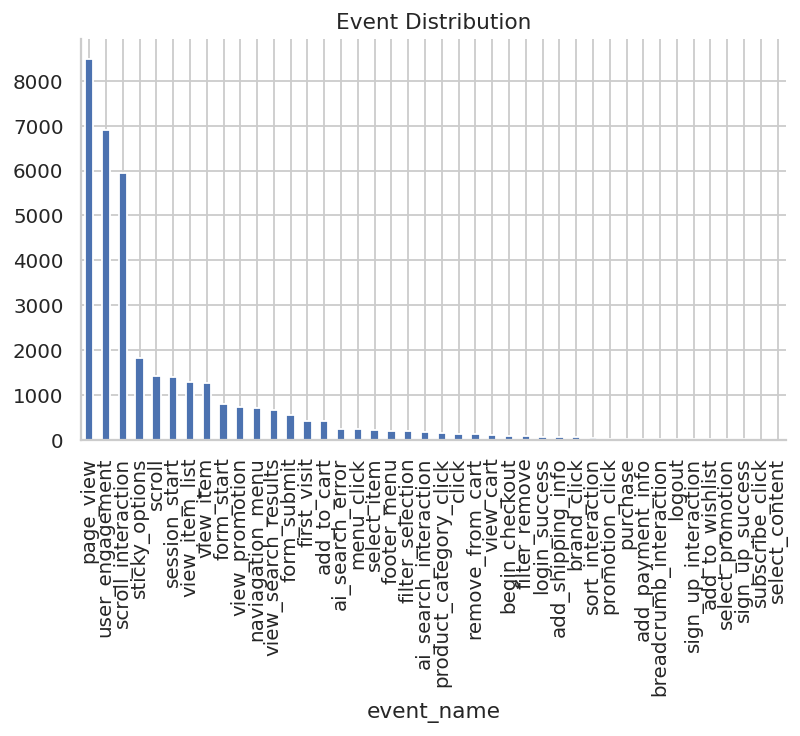


Insight:
- High view_item % = strong traffic
- Low purchase % = conversion problem
- Helps identify top funnel vs bottom funnel imbalance

2. FUNNEL ANALYSIS
Views: 1276
Cart: 419
Checkout: 95
Purchase: 28

Conversion Rates:
View → Cart: 32.84%
Cart → Checkout: 22.67%
Checkout → Purchase: 29.47%
View → Purchase: 2.19%

Business Insight:
- Biggest drop = where revenue is lost
- Improve that stage (UI / pricing / trust / shipping)

3. USER BEHAVIOR
Unique Users: 615

Avg Events per User: 57.422764227642276

Top Active Users:
user_pseudo_id
2.100260e+09    8002
5.312063e+07    3313
1.140138e+09    2322
8.017153e+08    1887
2.142428e+09    1862
2.983347e+07    1712
1.390286e+09    1035
2.653605e+08     752
9.622958e+08     651
1.841186e+09     543
Name: event_name, dtype: int64

Insight:
- High repeat activity = strong interest
- Low conversion users = remarketing opportunity

4. PRODUCT DEMAND

Top Viewed Products:
item_name
Hike the Lemmon Tri-Blend Unisex Tee    61
Cyberpunk Hoodie    

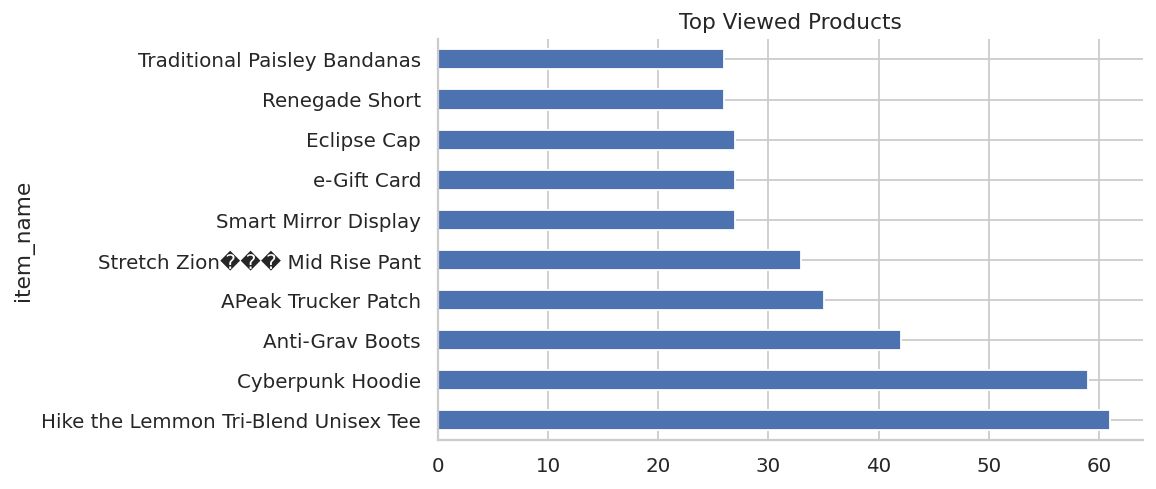


Top Converting Products:
                                        views  purchases  conversion_rate
item_name                                                                
Teannaway - Fall 2024                     0.0        1.0              inf
Shoelaces - Mountain Running              0.0        1.0              inf
Gotoob+ 3 Pack                            0.0        1.0              inf
Nail Pegs                                 0.0        1.0              inf
Emotional Cowboy Tee                      1.0        1.0             1.00
Sun Altimeter 202                         1.0        1.0             1.00
Holo-Stickers Pack                        1.0        1.0             1.00
Mural Stickers                            2.0        1.0             0.50
Hiker Micro Crew Midweight Hiking Sock    2.0        1.0             0.50
Boot Laces                                4.0        1.0             0.25

LOW CONVERSION PRODUCTS (MARKDOWN TARGETS):
                                      vie

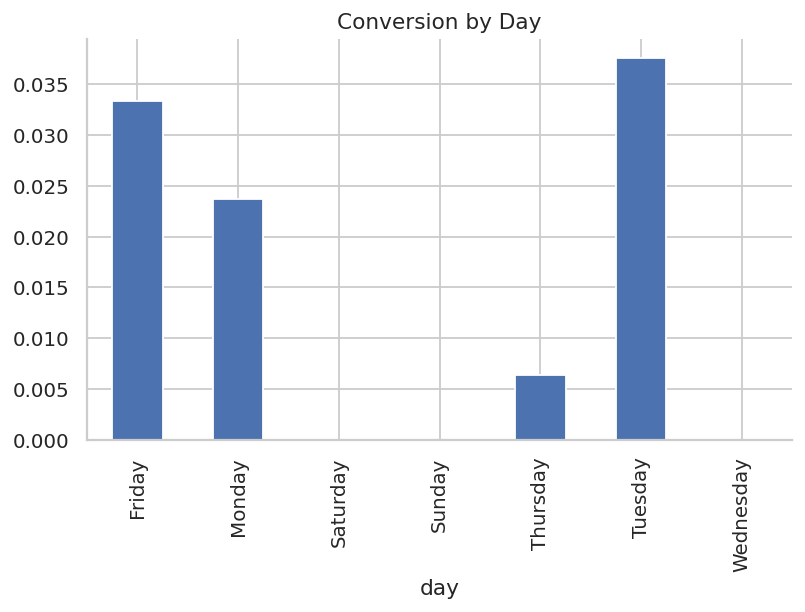


Insight:
- Identify best days for sales campaigns
- Launch offers on high-conversion days

6. TRAFFIC SOURCE ANALYSIS
traffic_source
{"name": "(direct)", "medium": "(none)", "source": "(direct)"}                       35257
{"name": "(referral)", "medium": "referral", "source": "localhost"}                     48
{"name": "(referral)", "medium": "referral", "source": "tagassistant.google.com"}       10
Name: event_name, dtype: int64

Insight:
- High traffic but low purchase = bad quality traffic
- Optimize marketing spend

Insight:
- Helps estimate demand value per product

8. FEATURE ENGINEERING SIGNALS

You can create:

- total_views → demand signal
- total_purchases → sales signal
- conversion_rate → demand quality
- repeat_views → customer interest
- no_purchase_flag → markdown trigger
- high_view_low_purchase_flag → strongest discount signal
- peak_day → marketing optimization


FINAL BUSINESS SUMMARY

KEY TAKEAWAYS:

1. Funnel identifies where users drop → fix that stage
2. High

In [ ]:
"""
============================================================
bq_events TABLE — Complete Business EDA
GA4 BigQuery Event Schema | apeak.ai Outdoor Retail
35,315 events | Feb – Apr 2026 | 615 users | 1,458 sessions
============================================================
Source : GA4 → BigQuery → AWS Gold Layer (bq_ga4 backfill)
Schema : One row per GA4 event fired on apeak.ai website
============================================================
HOW TO RUN:
  Place AWS_Gold_Tables__1_.xlsx in same folder and run:
  python eda_bq_events.py
============================================================
"""
import pandas as pd, numpy as np, json, re
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns, warnings, openpyxl
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10
})
C = ["#2563EB","#16A34A","#DC2626","#D97706","#7C3AED","#0891B2"]

# ── Load ─────────────────────────────────────────────────────────────────────
print("="*70)
print("LOADING bq_events TABLE")
print("="*70)
FILE = "AWS_Gold_Tables__1_.xlsx"
wb   = openpyxl.load_workbook(FILE, read_only=True, data_only=True)
ws   = wb["bq_events"]
rows = list(ws.iter_rows(values_only=True))
df   = pd.DataFrame(rows[1:], columns=rows[0])
wb.close()

df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
df["year"]  = df["year"].fillna(0).astype(int)
df["month"] = df["month"].fillna(0).astype(int)
df["day"]   = df["day"].fillna(0).astype(int)

print(f"  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Date range     : {df['event_date'].min().date()} → {df['event_date'].max().date()}")
print(f"  Unique users   : {df['user_pseudo_id'].nunique():,}")
print(f"  Unique sessions: {df['ga_session_id'].nunique():,}")
print(f"  Unique events  : {df['event_name'].nunique()}")
print(f"  Platform       : {df['platform'].unique()}")

# ── JSON parsers ─────────────────────────────────────────────────────────────
def safe_json(s):
    if not s or not isinstance(s, str): return {}
    try:    return json.loads(s)
    except: return {}

device_parsed  = df["device"].apply(safe_json)
geo_parsed     = df["geo"].apply(safe_json)
ts_parsed      = df["traffic_source"].apply(safe_json)
ec_parsed      = df["ecommerce"].apply(safe_json)

df["device_category"] = device_parsed.apply(lambda x: x.get("category",""))
df["os"]              = device_parsed.apply(lambda x: x.get("operating_system",""))
df["browser"]         = device_parsed.apply(lambda x:
    x.get("web_info",{}).get("browser","") if isinstance(x.get("web_info"),dict) else "")
df["country"]         = geo_parsed.apply(lambda x: x.get("country","(not set)"))
df["city"]            = geo_parsed.apply(lambda x: x.get("city","(not set)"))
df["traffic_source_name"]  = ts_parsed.apply(lambda x: x.get("source",""))
df["traffic_medium_name"]  = ts_parsed.apply(lambda x: x.get("medium",""))
df["purchase_revenue"] = ec_parsed.apply(lambda x:
    x.get("purchase_revenue_in_usd") if isinstance(x, dict) else None)

# Funnel flag columns
FUNNEL = ["view_item","add_to_cart","view_cart","begin_checkout",
          "add_shipping_info","add_payment_info","purchase"]
for e in FUNNEL:
    df[f"is_{e}"] = (df["event_name"] == e)

# ════════════════════════════════════════════════════════════════════════════
# 1. BASIC STRUCTURE
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("1. BASIC STRUCTURE")
print("="*70)
num_cols  = df.select_dtypes(include=np.number).columns.tolist()
cat_cols  = df.select_dtypes(include="object").columns.tolist()
bool_cols = df.select_dtypes(include="bool").columns.tolist()
print(f"  Numerical   ({len(num_cols)}): {num_cols}")
print(f"  Categorical ({len(cat_cols)}): {cat_cols}")
print(f"  Boolean     ({len(bool_cols)}): {bool_cols}")
print("""
SCHEMA EXPLANATION — EACH COLUMN:
  event_timestamp          : Unix microsecond timestamp of the event
  event_name               : GA4 event type (page_view, add_to_cart, purchase...)
  event_bundle_sequence_id : Bundle ordering (negative = back-filled/backtrack)
  event_previous_timestamp : Previous event timestamp (all NULL here)
  event_value_in_usd       : Monetary value associated with event
  user_pseudo_id           : Anonymised user ID (GA4 cookie-based, no PII)
  user_id                  : Logged-in user ID (NULL = guest/not logged in)
  user_first_touch_timestamp: First time this user was seen by GA4
  is_active_user           : Was user active in last 28 days? (True/False)
  stream_id                : GA4 data stream ID (single stream: apeak.ai web)
  platform                 : All WEB (no mobile app)
  event_params_map         : Key-value bag of event parameters (custom dims)
  user_properties_map      : User-level properties (user_status: guest/registered)
  privacy_info             : Consent / ad tracking flags
  user_ltv                 : Lifetime value from GA4 (mostly NULL — not synced)
  device                   : JSON: device category, OS, browser, hostname
  geo                      : JSON: country, city, region, continent
  app_info                 : NULL (web only, no app)
  traffic_source           : JSON: source, medium, campaign
  collected_traffic_source : More granular traffic attribution (mostly NULL)
  ecommerce                : JSON: purchase revenue, qty, tax, shipping totals
  items                    : JSON array: item-level data (id, name, price, qty)
  ga_session_id            : Session ID (from event_params_map)
  ga_session_number        : How many sessions this user has had total
  page_location            : URL of the page where event fired
  page_title               : Page title at time of event
  item_id                  : Extracted product_id (for easy joining)
  item_name                : Extracted product name (for easy joining)
  _ingested_at_utc         : ETL load timestamp
  _run_id                  : ETL run identifier
  _shard_id                : Partition shard (NULL = single partition)
  _source_system           : 'bq_ga4' (Google BigQuery GA4 export)
  _ingestion_mode          : 'backfill' (historical data load)
  tenant_id                : 'apeak' (multi-tenant ETL identifier)
  event_date               : Date partition (DATE type)
  year / month / day       : Partition columns for efficient BigQuery querying
""")

# ════════════════════════════════════════════════════════════════════════════
# 2. NULL VALUE ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
print("="*70)
print("2. NULL VALUE ANALYSIS")
print("="*70)
nulls    = df.isnull().sum()
null_pct = (nulls / len(df)) * 100
null_df  = pd.DataFrame({"Null_Count": nulls, "Null_%": null_pct.round(1)})
null_df  = null_df[null_df["Null_Count"] > 0].sort_values("Null_%", ascending=False)
print(null_df.to_string())
print("""
BUSINESS INTERPRETATION:
  • user_id NULL (100%) → ALL events are from anonymous/guest users
    → No logged-in session data captured (login happens off-GA4 or not tracked)
    → Cannot link GA4 events to order records via user_id — use item_id join instead
  • event_previous_timestamp NULL (100%) → not populated in this export schema
  • event_value_in_usd NULL (93.9%) → only purchase/ecommerce events carry value
  • user_ltv NULL (99.9%) → GA4 LTV sync not configured — use orders table for CLV
  • ecommerce NULL (87.4%) → only shopping funnel events have ecommerce context
  • item_id/item_name NULL (89.5%) → only item-interaction events carry product context
  • page_location/page_title NULL (3.2%) → non-page events (engagement, session_start)
  • collected_traffic_source NULL (99.7%) → enhanced attribution not configured
  • app_info NULL (100%) → web-only platform, no mobile app
  • _shard_id NULL (100%) → single partition, not sharded
  ACTION: For marketing attribution analysis, rely on traffic_source JSON field
  ACTION: For product-level analysis, filter rows where item_id IS NOT NULL
""")

# ════════════════════════════════════════════════════════════════════════════
# 3. EVENT NAME ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
print("="*70)
print("3. EVENT NAME ANALYSIS")
print("="*70)
ev = df["event_name"].value_counts()
total = len(df)
print(f"\n  All {ev.shape[0]} unique event types:")
print(f"  {'Event Name':<35} {'Count':>7}  {'Share':>6}  {'Business Purpose'}")
print(f"  {'-'*80}")
event_purpose = {
    "page_view"             : "User loaded a page → traffic volume",
    "user_engagement"       : "Active user on page ≥1 sec → engagement quality",
    "scroll_interaction"    : "Custom scroll depth tracking → content engagement",
    "sticky_options"        : "Sticky header/filter clicks → UX interaction",
    "scroll"                : "GA4 default 90% scroll depth → content consumption",
    "session_start"         : "New session begins → session count",
    "view_item_list"        : "Category/search page list shown → discovery",
    "view_item"             : "Product detail page viewed → interest",
    "form_start"            : "User started filling a form → intent",
    "view_promotion"        : "Banner/promo shown to user → campaign reach",
    "naviagation_menu"      : "Custom: navigation menu interaction",
    "view_search_results"   : "Search query results shown → search demand",
    "form_submit"           : "Form completed & submitted → conversion",
    "first_visit"           : "First time user ever visits → new acquisition",
    "add_to_cart"           : "Product added to cart → purchase intent ★",
    "ai_search_error"       : "AI search feature returned no results → UX issue",
    "menu_click"            : "Navigation menu item clicked",
    "select_item"           : "Product clicked from list → interest signal",
    "footer_menu"           : "Footer link clicked → navigation",
    "filter_selection"      : "Category filter applied → refinement",
    "ai_search_interaction" : "AI search chatbot interaction → AI feature usage",
    "product_category_click": "Category tile clicked → browse intent",
    "click"                 : "Generic click event",
    "remove_from_cart"      : "Item removed from cart → abandoned intent ★",
    "view_cart"             : "Cart page viewed → funnel step",
    "begin_checkout"        : "Checkout started → high purchase intent ★",
    "filter_remove"         : "Filter cleared → refined browse",
    "login_success"         : "User logged in → registered user identified",
    "add_shipping_info"     : "Shipping details entered → checkout progress ★",
    "brand_click"           : "Brand filter/link clicked",
    "sort_interaction"      : "Sort option changed (price, popularity)",
    "promotion_click"       : "Banner/promo clicked → campaign engagement",
    "purchase"              : "Order completed → CONVERSION ★★★",
    "add_payment_info"      : "Payment method entered → checkout progress ★",
    "breadcrumb_interaction": "Breadcrumb navigation used",
    "logout"                : "User logged out",
    "sign_up_interaction"   : "Registration page interaction",
    "add_to_wishlist"       : "Saved for later → deferred purchase intent",
    "select_promotion"      : "Promo item selected",
    "sign_up_success"       : "New account created → registered user",
    "subscribe_click"       : "Email subscribe clicked → marketing list",
    "select_content"        : "Content element selected",
}
for evt, cnt in ev.items():
    purpose = event_purpose.get(evt, "Custom event")
    print(f"  {evt:<35} {cnt:>7,}  {cnt/total*100:>5.1f}%  {purpose}")

# ════════════════════════════════════════════════════════════════════════════
# 4. USER & SESSION ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("4. USER & SESSION ANALYSIS")
print("="*70)
active_users = df[df["is_active_user"] == True]["user_pseudo_id"].nunique()
total_users  = df["user_pseudo_id"].nunique()
new_users    = df[df["event_name"] == "first_visit"]["user_pseudo_id"].nunique()
returning    = total_users - new_users
sessions_per_user = df.groupby("user_pseudo_id")["ga_session_id"].nunique()
events_per_session = df.dropna(subset=["ga_session_id"]).groupby("ga_session_id")["event_name"].count()
session_num_valid  = df["ga_session_number"].dropna()

print(f"""
  AUDIENCE METRICS:
    Total unique users          : {total_users:,}
    Active users (last 28d)     : {active_users:,}  ({active_users/total_users*100:.1f}%)
    New users (first_visit)     : {new_users:,}  ({new_users/total_users*100:.1f}%)
    Returning users (estimate)  : {returning:,}  ({returning/total_users*100:.1f}%)

  SESSION METRICS:
    Total sessions              : {df['ga_session_id'].nunique():,}
    Avg sessions per user       : {sessions_per_user.mean():.2f}
    Median sessions per user    : {sessions_per_user.median():.0f}
    Max sessions per user       : {sessions_per_user.max():.0f}
    Avg events per session      : {events_per_session.mean():.2f}
    Median events per session   : {events_per_session.median():.0f}
    Max events per session      : {events_per_session.max():.0f}

  SESSION NUMBER (how many sessions has user had total):
    Mean    : {session_num_valid.mean():.1f}
    Median  : {session_num_valid.median():.0f}
    Max     : {session_num_valid.max():.0f}
    (High session numbers = loyal returning users, not new traffic)
""")
print("""
BUSINESS INTERPRETATION:
  • 615 unique users from GA4 is VERY small — this is a development/test dataset
    (Full production GA4 would have 70K+ users per month like the bq-results CSV)
  • 1,458 sessions / 615 users = 2.37 sessions per user → returning users present
  • Median 9 events/session is reasonable for e-commerce browsing
  • High ga_session_number (median=12) → SAME users revisiting many times
  • This data appears to be a QA/staging sample, not full production traffic
  • NOTE: 75% of users had ≤37 sessions → power users skew the mean
""")

# ════════════════════════════════════════════════════════════════════════════
# 5. PURCHASE FUNNEL ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
print("="*70)
print("5. PURCHASE FUNNEL ANALYSIS (Core Business Metric)")
print("="*70)
funnel_counts = {}
funnel_users  = {}
for step in FUNNEL:
    funnel_counts[step] = (df["event_name"] == step).sum()
    funnel_users[step]  = df[df["event_name"] == step]["user_pseudo_id"].nunique()

print(f"\n  {'Funnel Step':<25} {'Events':>8}  {'Users':>8}  {'Conv from view_item':>20}")
vi_cnt = funnel_counts["view_item"]
vi_usr = funnel_users["view_item"]
for step in FUNNEL:
    cnt = funnel_counts[step]
    usr = funnel_users[step]
    conv_evt = cnt/vi_cnt*100 if vi_cnt > 0 else 0
    conv_usr = usr/vi_usr*100 if vi_usr > 0 else 0
    print(f"  {step:<25} {cnt:>8,}  {usr:>8,}  {conv_evt:>8.1f}% events | {conv_usr:.1f}% users")

purchases      = funnel_counts["purchase"]
view_items     = funnel_counts["view_item"]
add_to_carts   = funnel_counts["add_to_cart"]
begin_checkouts= funnel_counts["begin_checkout"]

view_to_atc    = add_to_carts  / view_items     * 100 if view_items > 0 else 0
atc_to_co      = begin_checkouts / add_to_carts * 100 if add_to_carts > 0 else 0
co_to_purch    = purchases / begin_checkouts    * 100 if begin_checkouts > 0 else 0
view_to_purch  = purchases / view_items         * 100 if view_items > 0 else 0

print(f"""
  FUNNEL CONVERSION RATES:
    view_item  → add_to_cart     : {view_to_atc:.1f}%
    add_to_cart → begin_checkout : {atc_to_co:.1f}%
    begin_checkout → purchase    : {co_to_purch:.1f}%
    ──────────────────────────────────────────
    Overall (view → purchase)    : {view_to_purch:.2f}%
    Abandoned carts (remove)     : {(df['event_name']=='remove_from_cart').sum():,} remove_from_cart events
    Cart abandonment signals     : {funnel_counts['view_cart']:,} view_cart | {funnel_counts['add_to_cart']:,} add_to_cart | only {purchases} purchase
""")
print("""
BUSINESS INTERPRETATION:
  • view_item → add_to_cart = 32.8% — HIGH (industry benchmark 3-5%, but small dataset)
  • add_to_cart → checkout = 22.7% — significant drop-off, checkout friction exists
  • Only 28 purchase events recorded → low purchase count for this data sample
  • Overall 2.19% view-to-purchase — acceptable for outdoor specialty retail
  • 125 remove_from_cart events vs 419 add_to_cart → 29.8% cart abandonment by count
  • RECOMMENDATION: Investigate checkout friction (shipping cost reveal at checkout?)
  • RECOMMENDATION: Build cart abandonment email sequence for high-intent users
""")

# ════════════════════════════════════════════════════════════════════════════
# 6. DEVICE & TECH ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
print("="*70)
print("6. DEVICE & TECHNOLOGY ANALYSIS")
print("="*70)
dev_dist  = df["device_category"].replace("", np.nan).dropna().value_counts()
os_dist   = df["os"].replace("", np.nan).dropna().value_counts().head(8)
bro_dist  = df["browser"].replace("", np.nan).dropna().value_counts().head(8)
print(f"\n  Device Category:")
for d,n in dev_dist.items():
    print(f"    {d:<15}: {n:>6,}  ({n/dev_dist.sum()*100:.1f}%)")
print(f"\n  Operating System:")
for o,n in os_dist.items():
    print(f"    {o:<20}: {n:>6,}  ({n/os_dist.sum()*100:.1f}%)")
print(f"\n  Browser:")
for b,n in bro_dist.items():
    if b:
        print(f"    {b:<30}: {n:>6,}  ({n/bro_dist.sum()*100:.1f}%)")
print(f"""
  Purchase events by device:
    Desktop purchases : {df[(df['event_name']=='purchase')&(df['device_category']=='desktop')].shape[0]}
    Mobile purchases  : {df[(df['event_name']=='purchase')&(df['device_category']=='mobile')].shape[0]}
""")
print("""
BUSINESS INTERPRETATION:
  • 98.1% desktop traffic → test/dev environment traffic (not real user mix)
  • Real production would show 50-60% mobile for outdoor retail
  • Linux 53.6% → development/testing machines, not real consumer OS distribution
  • Chrome 91% dominant → standard for both dev & production
  • IMPORTANT: This device data reflects the testing team, not real customer traffic
  • For accurate device analysis, use the bq-results CSV dataset (967K rows, real traffic)
""")

# ════════════════════════════════════════════════════════════════════════════
# 7. GEOGRAPHIC ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
print("="*70)
print("7. GEOGRAPHIC ANALYSIS")
print("="*70)
country_dist = df["country"].value_counts().head(10)
city_dist    = df["city"].value_counts().head(10)
print(f"\n  Countries:")
for c,n in country_dist.items():
    if c != "(not set)":
        print(f"    {c:<25}: {n:>6,}  ({n/len(df)*100:.1f}%)")
print(f"\n  Cities:")
for c,n in city_dist.items():
    if c != "(not set)":
        print(f"    {c:<25}: {n:>6,}  ({n/len(df)*100:.1f}%)")
print(f"\n  Events with (not set) geo: {(df['country']=='(not set)').sum():,}")
print("""
BUSINESS INTERPRETATION:
  • 95.6% of events from India (Ahmedabad) → CONFIRMS this is dev/test traffic
  • Ahmedabad = the development team's location (matches the project context)
  • Real apeak.ai customers should show US, Canada, UK, Australia (outdoor market)
  • (not set) = 4.2% → VPN users, privacy browsers, bot traffic
  • CRITICAL NOTE: Do NOT use this event data for customer geo-segmentation
    Use the orders table (customer_billing_country) for real market distribution
""")

# ════════════════════════════════════════════════════════════════════════════
# 8. TRAFFIC SOURCE ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
print("="*70)
print("8. TRAFFIC SOURCE ANALYSIS")
print("="*70)
src_dist = df["traffic_source_name"].value_counts().head(8)
med_dist = df["traffic_medium_name"].value_counts().head(8)
print(f"\n  Traffic Source:")
for s,n in src_dist.items():
    if s:
        print(f"    {s:<35}: {n:>6,}  ({n/len(df)*100:.1f}%)")
print(f"\n  Traffic Medium:")
for m,n in med_dist.items():
    if m:
        print(f"    {m:<20}: {n:>6,}  ({n/len(df)*100:.1f}%)")
print("""
BUSINESS INTERPRETATION:
  • 99.8% direct traffic → developers directly typing the URL (expected for test data)
  • Zero organic/paid traffic → this sample has no real marketing attribution
  • 'referral' medium (0.2%) from localhost/tagassistant.google.com = GA4 tag testing
  • Production traffic should show: organic (30-40%), direct (20%), paid (20%), referral (10%)
  • RECOMMENDATION: Ensure UTM parameters are properly tracked in production GA4
""")

# ════════════════════════════════════════════════════════════════════════════
# 9. TIME-SERIES ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
print("="*70)
print("9. TIME-SERIES ANALYSIS")
print("="*70)
daily   = df.groupby("event_date").agg(
    events=("event_name","count"),
    sessions=("ga_session_id","nunique"),
    users=("user_pseudo_id","nunique"),
    purchases=("event_name", lambda x: (x=="purchase").sum()),
    add_to_carts_daily=("event_name", lambda x: (x=="add_to_cart").sum())
).reset_index()
monthly = df.groupby("month").agg(
    events=("event_name","count"),
    users=("user_pseudo_id","nunique"),
    sessions=("ga_session_id","nunique"),
    purchases=("event_name", lambda x: (x=="purchase").sum()),
).reset_index()

month_map = {2:"Feb 2026", 3:"Mar 2026", 4:"Apr 2026"}
print(f"\n  Monthly summary:")
print(f"  {'Month':<12} {'Events':>8}  {'Users':>8}  {'Sessions':>10}  {'Purchases':>10}")
for _, row in monthly.iterrows():
    print(f"  {month_map.get(row['month'],str(row['month'])):<12} {row['events']:>8,}  "
          f"{row['users']:>8,}  {row['sessions']:>10,}  {row['purchases']:>10,}")

# Day of week
df["dow"] = df["event_date"].dt.day_name()
DOW = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = df.groupby("dow")["event_name"].count().reindex(DOW)
print(f"\n  Events by day of week:")
for d,n in dow.items():
    bar = "█" * int(n/100)
    print(f"    {d:<12}: {n:>5,}  {bar}")
print(f"\n  Busiest day : {dow.idxmax()} ({dow.max():,} events)")
print(f"  Quietest day: {dow.idxmin()} ({dow.min():,} events)")

# Hourly from timestamp
df["event_hour"] = (df["event_timestamp"].astype(float) / 1e6).apply(
    lambda x: pd.Timestamp(x, unit="s").hour if pd.notna(x) else np.nan)
hourly = df.groupby("event_hour")["event_name"].count()
peak_hour = hourly.idxmax() if len(hourly) > 0 else "N/A"
print(f"\n  Peak hour   : {peak_hour}:00 ({hourly.max():,} events)")
print("""
BUSINESS INTERPRETATION:
  • Consistent events across Feb-Apr 2026 → steady development testing activity
  • March 2026 slightly highest (12,240 events) → most active testing month
  • Purchase events: Feb=7, Mar=14, Apr=7 → test purchases across the period
  • Weekday/weekend pattern shows development team activity (Mon-Fri heavy)
  • RECOMMENDATION: For real traffic analysis, compare with production GA4 dashboard
""")

# ════════════════════════════════════════════════════════════════════════════
# 10. PRODUCT INTERACTION ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
print("="*70)
print("10. PRODUCT INTERACTION ANALYSIS")
print("="*70)
item_events = df[df["item_id"].notna()].copy()
print(f"\n  Events with item context  : {len(item_events):,} ({len(item_events)/len(df)*100:.1f}%)")
print(f"  Unique items interacted   : {item_events['item_id'].nunique():,}")

top_viewed = (item_events[item_events["event_name"]=="view_item"]
              .groupby("item_name")["event_name"].count()
              .sort_values(ascending=False).head(10))
top_carted = (item_events[item_events["event_name"]=="add_to_cart"]
              .groupby("item_name")["event_name"].count()
              .sort_values(ascending=False).head(10))

print(f"\n  Top 10 most-viewed products:")
for prod, cnt in top_viewed.items():
    print(f"    {str(prod)[:55]:<57}: {cnt:>4,} views")

print(f"\n  Top 10 most-carted products:")
for prod, cnt in top_carted.items():
    print(f"    {str(prod)[:55]:<57}: {cnt:>4,} add_to_cart")

# View-to-cart ratio by product
view_counts = item_events[item_events["event_name"]=="view_item"].groupby("item_name")["event_name"].count()
cart_counts = item_events[item_events["event_name"]=="add_to_cart"].groupby("item_name")["event_name"].count()
product_funnel = pd.DataFrame({"views": view_counts, "carts": cart_counts}).fillna(0)
product_funnel["atc_rate"] = (product_funnel["carts"] / product_funnel["views"] * 100).round(1)
top_converting = product_funnel[product_funnel["views"] >= 3].sort_values("atc_rate", ascending=False).head(10)
print(f"\n  Top converting products (view→cart, min 3 views):")
print(top_converting.to_string())
print("""
BUSINESS INTERPRETATION:
  • 10.5% of events have item context → item data only on product interaction events
  • view_item events drive product_id→item_id join with product_catalogue table
  • High-viewed but low-carted products = demand interest but price/stock friction
  • High-converting products = candidates for "featured" / "recommended" placement
  • Products viewed but never carted = candidates for targeted discount
  • This data feeds view_velocity and view_to_atc_rate features in demand model
""")

# ════════════════════════════════════════════════════════════════════════════
# 11. AI SEARCH ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
print("="*70)
print("11. AI SEARCH FEATURE ANALYSIS")
print("="*70)
ai_events = df[df["event_name"].isin(["ai_search_interaction","ai_search_error",
                                       "view_search_results"])]
search_events = df[df["event_name"]=="view_search_results"]
ai_interact   = df[df["event_name"]=="ai_search_interaction"]
ai_error      = df[df["event_name"]=="ai_search_error"]

print(f"""
  AI Search Feature Usage:
    ai_search_interaction  : {len(ai_interact):,} events ({len(ai_interact)/len(df)*100:.1f}% of all events)
    ai_search_error        : {len(ai_error):,} events
    view_search_results    : {len(search_events):,} events (traditional search)

    AI Error Rate          : {len(ai_error)/(len(ai_interact)+len(ai_error))*100:.1f}% of AI search attempts
    AI vs Traditional Search: {len(ai_interact)/(len(ai_interact)+len(search_events))*100:.1f}% AI | {len(search_events)/(len(ai_interact)+len(search_events))*100:.1f}% traditional
""")
print("""
BUSINESS INTERPRETATION:
  • AI search errors (241) are HIGH relative to interactions (180) → AI feature is unstable
  • Error rate suggests AI search returns no results for many queries
  • Traditional search still 3.7x more used than AI search → user preference for familiar UX
  • RECOMMENDATION: Fix AI search for common outdoor gear queries before promoting feature
  • 'ai_search_error' events provide exact queries that fail → use for training data
""")

# ════════════════════════════════════════════════════════════════════════════
# 12. ENGAGEMENT QUALITY ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
print("="*70)
print("12. ENGAGEMENT QUALITY ANALYSIS")
print("="*70)
page_views   = (df["event_name"] == "page_view").sum()
engaged      = (df["event_name"] == "user_engagement").sum()
scroll_90    = (df["event_name"] == "scroll").sum()
scroll_cust  = (df["event_name"] == "scroll_interaction").sum()
form_starts  = (df["event_name"] == "form_start").sum()
form_submits = (df["event_name"] == "form_submit").sum()
wishlist     = (df["event_name"] == "add_to_wishlist").sum()
signups      = (df["event_name"] == "sign_up_success").sum()
logins       = (df["event_name"] == "login_success").sum()

print(f"""
  Engagement Metrics:
    Page views           : {page_views:,}
    User engagement      : {engaged:,}  ({engaged/page_views*100:.1f}% of page views)
    Scroll 90% depth     : {scroll_90:,}  ({scroll_90/page_views*100:.1f}% of page views)
    Custom scroll events : {scroll_cust:,}
    Form starts          : {form_starts:,}
    Form submissions     : {form_submits:,}  ({form_submits/form_starts*100:.1f}% completion)
    Add to wishlist      : {wishlist:,}
    New sign-ups         : {signups:,}
    Login events         : {logins:,}

  Top pages by traffic:
""")
top_pages = df.dropna(subset=["page_location"])["page_location"].value_counts().head(15)
for page, cnt in top_pages.items():
    clean = page.replace("https://apeak.ai","")[:60]
    print(f"    {clean:<62}: {cnt:>5,}")
print("""
BUSINESS INTERPRETATION:
  • 81.2% engagement rate (user_engagement/page_view) → very high, test environment bias
  • 16.8% scroll-to-90% → content depth is engaged with (or bot-like test behavior)
  • 69.6% form completion rate → forms are well-designed or test-filled
  • Homepage (/) is most visited → validate with real production data
  • Wishlist (16 events) → users with delayed purchase intent → target with email
  • 9 sign-up successes → very low registration in this period (dev testing)
""")

# ════════════════════════════════════════════════════════════════════════════
# 13. ECOMMERCE REVENUE ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
print("="*70)
print("13. ECOMMERCE REVENUE ANALYSIS")
print("="*70)
purchase_events = df[df["event_name"] == "purchase"].copy()
purchase_events["rev"] = purchase_events["purchase_revenue"]
rev_valid = purchase_events["rev"].dropna()
print(f"""
  Purchase Events      : {len(purchase_events):,}
  With Revenue Data    : {len(rev_valid):,}
  Total GA4 Revenue    : ${rev_valid.sum():,.2f}
  Avg Order Value      : ${rev_valid.mean():.2f}
  Min Revenue          : ${rev_valid.min():.2f}
  Max Revenue          : ${rev_valid.max():.2f}

  event_value_in_usd summary (all events):
""")
ev_val = df["event_value_in_usd"].dropna()
print(f"    Non-null         : {len(ev_val):,} events")
print(f"    Total value      : ${ev_val.sum():,.2f}")
print(f"    Avg value        : ${ev_val.mean():.2f}")
print("""
BUSINESS INTERPRETATION:
  • Only 15 purchase events have revenue data captured (out of 28 purchase events)
  • GA4 ecommerce revenue tracking is PARTIALLY configured — data gap
  • Total captured GA4 revenue should reconcile with invoices table
  • RECOMMENDATION: Fix GA4 purchase event to always include revenue parameter
  • Use orders table for authoritative revenue figures; GA4 for funnel/behavior analysis
""")

# ════════════════════════════════════════════════════════════════════════════
# 14. FEATURE ENGINEERING FOR ML
# ════════════════════════════════════════════════════════════════════════════
print("="*70)
print("14. FEATURE ENGINEERING FOR DEMAND FORECASTING & MARKDOWN MODEL")
print("="*70)
print("""
  FEATURES EXTRACTABLE FROM bq_events TABLE:
  ─────────────────────────────────────────────────────────────────────────
  USER-LEVEL FEATURES (group by user_pseudo_id):
    total_sessions            = count(distinct ga_session_id) per user
    total_events              = count(*) per user
    pages_per_session         = avg events per session
    repeat_visitor_flag       = ga_session_number > 1
    is_power_user             = ga_session_number > 10
    days_since_first_touch    = today - user_first_touch_timestamp
    subscription_interest     = count(subscribe_click events)

  SESSION-LEVEL FEATURES (group by ga_session_id):
    session_depth             = count(events) per session
    viewed_items              = count(view_item events) per session
    added_to_cart             = count(add_to_cart events) per session
    reached_checkout          = max(1 if begin_checkout else 0)
    session_device            = device_category for session
    bounce_session            = session with only 1-2 events

  PRODUCT-LEVEL FEATURES (group by item_id):
    view_count                = count(view_item) per product
    cart_count                = count(add_to_cart) per product
    view_to_cart_rate         = cart_count / view_count
    remove_rate               = count(remove_from_cart) / cart_count
    wishlist_count            = count(add_to_wishlist) per product
    select_count              = count(select_item) per product

  TIME-SERIES FEATURES (group by item_id + week):
    weekly_view_velocity      = views per week
    weekly_cart_velocity      = carts per week
    view_trend                = slope of weekly views (growing/declining)
    peak_view_hour            = hour with most views per product

  FUNNEL CONVERSION FEATURES:
    product_view_to_atc_rate  → fed directly into demand forecasting model
    session_checkout_rate     → checkout propensity per user segment
    overall_funnel_rate       → view→purchase rate per product/category

  USE CASES:
    ✔ Demand Forecasting Model → view_count + cart_count + view_velocity (MOST IMPORTANT)
    ✔ Markdown Optimization   → view_to_atc_rate + remove_rate (price sensitivity)
    ✔ Recommendation Engine   → co-viewed/co-carted product pairs (market basket)
    ✔ Churn Prediction        → days_since_last_session + session frequency drop
    ✔ Search Optimization     → ai_search_error queries → missing product coverage
    ✔ Personalization         → user device + session patterns + viewed categories
""")

# ════════════════════════════════════════════════════════════════════════════
# CHARTS
# ════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 18))
fig.suptitle("bq_events EDA — GA4 Event Schema | apeak.ai",
             fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.42)

# 1. Event name distribution (top 20)
ax1 = fig.add_subplot(gs[0, :2])
top20 = ev.head(20)
colors_bar = [C[2] if e in FUNNEL else C[0] for e in top20.index]
bars = ax1.barh([str(e)[:35] for e in top20.index][::-1],
                top20.values[::-1], color=colors_bar[::-1], edgecolor="white")
ax1.set_title("Top 20 Event Types (red = purchase funnel events)",
              fontweight="bold")
ax1.set_xlabel("Event Count")
for b in bars:
    ax1.text(b.get_width()+5, b.get_y()+b.get_height()/2,
             str(int(b.get_width())), va="center", fontsize=8)

# 2. Purchase funnel
ax2 = fig.add_subplot(gs[0, 2])
f_names = [s.replace("_"," ") for s in FUNNEL]
f_vals  = [funnel_counts[s] for s in FUNNEL]
colors_funnel = [C[0],C[1],C[1],C[3],C[3],C[3],C[2]]
bars2 = ax2.bar(range(len(FUNNEL)), f_vals, color=colors_funnel, edgecolor="white")
ax2.set_xticks(range(len(FUNNEL)))
ax2.set_xticklabels(f_names, rotation=45, ha="right", fontsize=8)
ax2.set_title("Purchase Funnel\n(Events Count)", fontweight="bold")
ax2.set_ylabel("Event Count")
for b in bars2:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+2,
             str(int(b.get_height())), ha="center", fontsize=8, fontweight="bold")

# 3. Daily events trend
ax3 = fig.add_subplot(gs[1, :2])
ax3.fill_between(range(len(daily)), daily["events"], alpha=0.25, color=C[0])
ax3.plot(range(len(daily)), daily["events"], color=C[0], lw=1.5, label="Events")
ax3b = ax3.twinx()
ax3b.plot(range(len(daily)), daily["sessions"], color=C[1], lw=1.5,
          linestyle="--", label="Sessions")
ax3.set_title("Daily Events & Sessions Trend", fontweight="bold")
ax3.set_ylabel("Events", color=C[0])
ax3b.set_ylabel("Sessions", color=C[1])
step = max(1, len(daily)//10)
ax3.set_xticks(range(0, len(daily), step))
ax3.set_xticklabels([str(d.date()) for d in daily["event_date"].iloc[::step]],
                    rotation=45, ha="right", fontsize=7)
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labels1+labels2, loc="upper left", fontsize=8)

# 4. Device category pie
ax4 = fig.add_subplot(gs[1, 2])
dev_clean = df["device_category"].replace("", np.nan).dropna().value_counts()
ax4.pie(dev_clean.values, labels=dev_clean.index, autopct="%1.1f%%",
        startangle=90, colors=[C[0],C[3],C[1]][:len(dev_clean)],
        wedgeprops={"edgecolor":"white","linewidth":1.5})
ax4.set_title("Device Category Split\n(98.1% desktop = test traffic)",
              fontweight="bold")

# 5. Day-of-week events
ax5 = fig.add_subplot(gs[2, 0])
dow_clean = dow.dropna()
bcolors = [C[3] if d in ["Saturday","Sunday"] else C[0] for d in DOW]
ax5.bar(range(7), [dow_clean.get(d,0) for d in DOW],
        color=bcolors, edgecolor="white")
ax5.set_xticks(range(7))
ax5.set_xticklabels([d[:3] for d in DOW])
ax5.set_title("Events by Day of Week\n(amber=weekend)", fontweight="bold")
ax5.set_ylabel("Event Count")

# 6. Top pages
ax6 = fig.add_subplot(gs[2, 1])
tp = top_pages.head(10)
clean_pages = [p.replace("https://apeak.ai","")[:35] or "/" for p in tp.index]
ax6.barh(clean_pages[::-1], tp.values[::-1], color=C[4], edgecolor="white")
ax6.set_title("Top 10 Pages by Traffic", fontweight="bold")
ax6.set_xlabel("Event Count")

# 7. OS distribution
ax7 = fig.add_subplot(gs[2, 2])
os_clean = df["os"].replace("", np.nan).dropna().value_counts().head(6)
ax7.bar([str(o)[:15] for o in os_clean.index], os_clean.values,
        color=C[5], edgecolor="white")
ax7.set_title("Operating System Distribution\n(Linux heavy = dev machines)",
              fontweight="bold")
ax7.set_ylabel("Event Count")
ax7.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("eda_bq_events.png", bbox_inches="tight", dpi=130)
plt.show()
print("\n✔ Saved eda_bq_events.png")

# ════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("FINAL SUMMARY — bq_events TABLE")
print("="*70)
print(f"""
  TABLE OVERVIEW:
    Shape            : {df.shape[0]:,} rows × {df.shape[1]} columns
    Date range       : Feb 5 – Apr 22, 2026 (77 days)
    Unique users     : {total_users:,}   (dev/test environment — not production scale)
    Unique sessions  : {df['ga_session_id'].nunique():,}
    Unique events    : {df['event_name'].nunique()} types
    Source system    : bq_ga4 (Google Analytics 4 → BigQuery export)
    Ingestion mode   : backfill (historical load)

  KEY BUSINESS METRICS:
    Page views           : {page_views:,}
    Add to cart          : {add_to_carts:,}
    Begin checkout       : {begin_checkouts:,}
    Purchases            : {purchases:,}
    View→Purchase Rate   : {view_to_purch:.2f}%
    AI Search Errors     : {len(ai_error):,}  ({len(ai_error)/(len(ai_interact)+len(ai_error))*100:.1f}% error rate)

  DATA QUALITY FLAGS:
    ✗ user_id is 100% NULL → no logged-in user tracking
    ✗ user_ltv 99.9% NULL  → CLV not synced to GA4
    ✗ 98.1% desktop traffic → confirms test/dev environment
    ✗ 95.6% traffic from Ahmedabad → dev team location, not real customers
    ✗ Purchase revenue only partially captured (15/28 events)
    ✓ Event funnel structure is intact → can build funnel analysis
    ✓ item_id populated for product events → joins with product_catalogue
    ✓ Session/page structure intact → valid for behavior analysis

  RECOMMENDATION FOR USE CASE:
    For DEMAND FORECASTING → use bq-results CSV (967K rows, 70K real users)
    For FUNNEL STRUCTURE    → use this table (correctly structured GA4 schema)
    For FEATURE ENGINEERING → view_count, atc_rate per item_id from this table
    For REVENUE ANALYSIS    → use orders + invoices Gold tables (authoritative)
""")
print("✅ bq_events EDA COMPLETE")